In [ ]:
# ============================================================
# CELL 1 — Env guards
# ============================================================
import os
os.environ['USE_TF']        = '0'
os.environ['USE_FLAX']      = '0'
os.environ['TRANSFORMERS_NO_TF']   = '1'
os.environ['TRANSFORMERS_NO_FLAX'] = '1'
os.environ['TRANSFORMERS_NO_ADVISORY_WARNINGS'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
print("✅ Env guards set")

In [ ]:
# ============================================================
# CELL 2 — Install dependencies (training & eval only)
# ============================================================
!pip install -q --upgrade "protobuf>=4.25.3,<5.0"
!pip install -q "transformers==4.46.0" "tokenizers>=0.20,<0.21" sentencepiece
!pip install -q datasets huggingface_hub
!pip install -q scikit-learn pandas numpy matplotlib seaborn umap-learn wordcloud
print("✅ Install done.")

In [22]:
# ============================================================
# CELL 3 — Imports, seeds, paths, IFIT taxonomy, run flags
# ============================================================
import os, sys, re, json, time, shutil, zipfile, pickle, warnings, random, glob
from collections import Counter
warnings.filterwarnings('ignore')

# --- Run flags ---
RUN_FORUM_CV      = False   # 5-fold CV retrains 5 models (~2 h)
RUN_LAMBDA_SWEEP  = True    # λ-sweep retrains 5 models (~15 min on T4)
RUN_ABLATION      = True    # uses cached abl_*.pt if present
RUN_ENCODER_CMP   = True    # uses cached baseline_*.pt if present

# Purge TF remnants
for m in list(sys.modules.keys()):
    if m.startswith(('tensorflow', 'keras', 'tensorboard')):
        del sys.modules[m]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import AutoTokenizer, AutoModel, CamembertTokenizer
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_predict, cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (f1_score, precision_recall_fscore_support,
                             average_precision_score, roc_auc_score,
                             mutual_info_score, normalized_mutual_info_score,
                             accuracy_score, confusion_matrix, classification_report)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.utils import resample
from scipy.stats import chi2, spearmanr, ttest_rel

# ---------- Paths ----------
DATA_DIR = os.environ.get('CIC_DATA_DIR', '/kaggle/input/df-cicl/')
CKPT_DIR = os.environ.get('CIC_CKPT_DIR', '/kaggle/input/checks/')
OUT_DIR  = os.environ.get('CIC_OUT_DIR',  '/kaggle/working/')
FIG_DIR  = os.path.join(OUT_DIR, 'figures/')
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# ---------- Global metrics store ----------
METRICS = {}

# ---------- File discovery helper ----------
def _find_file(name, extra_dirs=None):
    dirs = [OUT_DIR, DATA_DIR, CKPT_DIR, './', './models/', './data/', './results/']
    if extra_dirs:
        dirs = list(extra_dirs) + dirs
    for d in dirs:
        p = os.path.join(d, name)
        if os.path.exists(p):
            return p
    hits = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    return hits[0] if hits else None

# ---------- Device ----------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Mem: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ---------- Seeds ----------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE); random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# ---------- IFIT taxonomy ----------
ITALIAN_FRAUD_INTENTS = {
    'credential_request': 'Richiesta login/password/PIN/SPID',
    'payment_request':    'Richiesta pagamento/bonifico/dati carta/IBAN',
    'data_request':       'Richiesta codice fiscale/documento/indirizzo',
    'click_request':      'Richiesta click su link/allegato/QR code',
    'call_request':       'Richiesta chiamare un numero/contattare falso supporto',
    'urgency':            'Pressione temporale, scadenza',
    'authority':          'Riferimento a banca/Poste/INPS/polizia/ministero',
    'fear':               'Minaccia: blocco/multa/sanzione/azione legale',
    'greed':              'Promessa premio/bonus/rimborso/regalo',
    'impersonation':      'Fingere di essere conoscente/collega/parente',
    'social_proof':       'Riferimento ad altri utenti',
    'reciprocity':        'Senso di debito',
}
INTENT_CODES = list(ITALIAN_FRAUD_INTENTS.keys())
N_INTENTS = len(INTENT_CODES)

CH_NAMES = {0: 'email', 1: 'sms', 3: 'forum'}
CHANNEL_MAP = {'email_fraud': 0, 'email_legit': 0, 'sms_fraud': 1, 'forum': 3}

MODEL_NAME = "Musixmatch/umberto-commoncrawl-cased-v1"
TEXT_COL = 'text_clean'
CHAN_COL = 'channel_id'
MAX_LEN  = 160

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110,
                     'savefig.dpi': 300, 'savefig.bbox': 'tight'})

tokenizer = CamembertTokenizer.from_pretrained(
    MODEL_NAME,
    unk_token="<unk>", bos_token="<s>", eos_token="</s>",
    sep_token="</s>", cls_token="<s>", pad_token="<pad>", mask_token="<mask>")
print(f"✅ Tokenizer: {type(tokenizer).__name__} (vocab={tokenizer.vocab_size})")


def parse_multihot(s):
    if isinstance(s, np.ndarray):
        return s.astype(np.float32)
    if isinstance(s, (list, tuple)):
        return np.asarray(s, dtype=np.float32)
    if isinstance(s, str):
        s = s.strip()
        if s.startswith('array('):
            s = s[len('array('):-1]
        s = s.strip('[]')
        vals = re.split(r'[\s,]+', s.strip())
        try:
            return np.array([float(v) for v in vals if v], dtype=np.float32)
        except ValueError:
            return np.zeros(N_INTENTS, dtype=np.float32)
    return np.zeros(N_INTENTS, dtype=np.float32)


print(f"✅ Setup complete — {N_INTENTS} intents, seed={RANDOM_STATE}")
print(f"   Run flags: FORUM_CV={RUN_FORUM_CV}  LAMBDA_SWEEP={RUN_LAMBDA_SWEEP} "
      f"ABLATION={RUN_ABLATION}  ENCODER_CMP={RUN_ENCODER_CMP}")

Device: cuda
  GPU: Tesla T4
  Mem: 15.6 GB
✅ Tokenizer: CamembertTokenizer (vocab=32000)
✅ Setup complete — 12 intents, seed=42
   Run flags: FORUM_CV=False  LAMBDA_SWEEP=True ABLATION=True  ENCODER_CMP=True


In [23]:
# ============================================================
# CELL 4 — Load df_cicl.csv (with multi-path search + df_f reconstruction)
# ============================================================
df_cicl_path = _find_file('df_cicl.csv')
assert df_cicl_path is not None, (
    "❌ df_cicl.csv not found. Add Kaggle dataset mariabilik/df-cicl.")

df_cicl = pd.read_csv(df_cicl_path)
df_cicl['multihot'] = df_cicl['multihot'].apply(parse_multihot)
df_cicl = df_cicl.dropna(subset=['text_clean']).reset_index(drop=True)
df_cicl['channel_id'] = df_cicl['channel_id'].astype(int)
df_cicl['n_intents'] = df_cicl['multihot'].apply(lambda v: int(v.sum()))

print(f"Loaded: {len(df_cicl)} rows from {df_cicl_path}")
print(f"Channels: {df_cicl['channel_id'].value_counts().to_dict()}")
print(f"Mean intents/doc (all): {df_cicl['n_intents'].mean():.2f}")
print(f"Mean intents/doc (n>0): "
      f"{df_cicl[df_cicl['n_intents']>0]['n_intents'].mean():.2f}")

# Reconstruct df_f (forum subset)
df_f = df_cicl[df_cicl['channel_id'] == 3].reset_index(drop=True)
print(f"✅ df_f (forum subset): {len(df_f)} rows "
      f"({(df_f['n_intents']>0).sum()} with intents)")
df_forum = df_f.copy()

Loaded: 950 rows from /kaggle/input/datasets/mariabilik/df-cicl/df_cicl.csv
Channels: {0: 421, 1: 416, 3: 113}
Mean intents/doc (all): 2.11
Mean intents/doc (n>0): 2.97
✅ df_f (forum subset): 113 rows (45 with intents)


In [ ]:
# ============================================================
# CELL 5 — TF-IDF + LogReg baseline (email → *)
# ============================================================
numeric_cols = ['urgency','authority','fear','greed',
                'urgency_x_length','fear_x_length','greed_x_length']
for c in numeric_cols:
    if c not in df_cicl.columns:
        df_cicl[c] = 0

try:
    import spacy
    _nlp_tmp = spacy.load("it_core_news_sm")
    STOPWORDS_IT = list(_nlp_tmp.Defaults.stop_words)
except Exception:
    STOPWORDS_IT = ['il','lo','la','i','gli','le','un','uno','una',
                    'di','a','da','in','con','su','per','tra','fra',
                    'e','o','ma','che','chi','cui','non','si','no']

if 'target' not in df_cicl.columns:
    _target_map = {'email_fraud': 1, 'email_legit': 0,
                   'sms_fraud': 1, 'forum': 0}
    df_cicl['target'] = df_cicl['subset'].map(_target_map).fillna(0).astype(int)

if 'text_lemma' not in df_cicl.columns:
    df_cicl['text_lemma'] = df_cicl['text_clean'].astype(str)

FEATURE_COLS = ['text_lemma'] + numeric_cols

text_features = FeatureUnion([
    ('word', TfidfVectorizer(ngram_range=(1,2), max_features=5000,
                             sublinear_tf=True, stop_words=STOPWORDS_IT, min_df=2)),
    ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5),
                             max_features=5000, sublinear_tf=True, min_df=2)),
])
preprocessor = ColumnTransformer([
    ('text', text_features, 'text_lemma'),
    ('num', FunctionTransformer(lambda x: x.values, validate=False), numeric_cols),
])

df_email = df_cicl[df_cicl['source'] == 'email_ephish_it'].reset_index(drop=True)
print(f"\nEmail subset: {len(df_email)} rows "
      f"(fraud={int(df_email['target'].sum())}, "
      f"legit={int((df_email['target']==0).sum())})")

X_tr, X_te, y_tr, y_te = train_test_split(
    df_email[FEATURE_COLS], df_email['target'],
    test_size=0.2, stratify=df_email['target'], random_state=RANDOM_STATE)

pipe_fraud = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=3000, class_weight='balanced',
                                C=1.0, random_state=RANDOM_STATE))])
pipe_fraud.fit(X_tr, y_tr)
y_pred = pipe_fraud.predict(X_te)
y_proba = pipe_fraud.predict_proba(X_te)[:, 1]

print(f"\nIn-domain (email → email):")
print(f"  Accuracy: {accuracy_score(y_te, y_pred):.4f}")
print(f"  ROC-AUC:  {roc_auc_score(y_te, y_proba):.4f}")

METRICS['tfidf_email'] = {
    'n_train': int(len(X_tr)),
    'n_test':  int(len(X_te)),
    'accuracy': float(accuracy_score(y_te, y_pred)),
    'roc_auc':  float(roc_auc_score(y_te, y_proba)),
}

In [ ]:
# ============================================================
# CELL 6 — V4 intent features (33 channel-invariant)
# ============================================================
def extract_intent_features_v4(text_original, text_lemmatized=""):
    if not isinstance(text_original, str): text_original = ""
    if not isinstance(text_lemmatized, str): text_lemmatized = ""
    t, t_lemma = text_original.lower(), text_lemmatized.lower()
    def find(p): return int(bool(re.search(p, t)) or bool(re.search(p, t_lemma)))
    return {
        'direct_address': find(r'\b(gentile cliente|caro cliente|gentile utente|gentile signor|gentile signora)\b'),
        'cta_click': find(r'\b(clicca qui|clicchi qui|clicca sul|segui il link|apri il link|clicca il link)\b'),
        'cta_access': find(r'\b(accedi al|acceda al|accedi subito|acceda subito|verifica il tuo|verifichi il suo|accedi qui)\b'),
        'urgency_deadline': find(r'\b(entro 24|entro 48|entro le prossime|scade oggi|ultimo avviso|immediatamente|urgente)\b'),
        'account_state': find(r'\b(conto (è |e )?(stato |stat[oa] )?blocc|conto (è |e )?(stato |stat[oa] )?sospes|'
                              r'carta (è |e )?(stata |stat[oa] )?blocc|carta (è |e )?(stata |stat[oa] )?sospes|'
                              r'utenza (è |e )?(stata |stat[oa] )?blocc|utenza (è |e )?(stata |stat[oa] )?sospes)\b'),
        'sms_object_state': find(r'\b(pacco|conto|carta|utenza|account|spedizione|bonifico|rimborso)\b.{0,40}'
                                 r'\b(trattenere|trattenuto|bloccare|bloccato|sospendere|sospeso|fallire|fallito|in sospeso)\b'),
        'sms_imperative': find(r'\b(verificare|contattare|chiamare|richiamare|cliccare|accedere|confermare|fornire|'
                               r'aggiornare|completare|risolvere|evitare|controllare)\b'),
        'sms_action_required': find(r'\b(necessario|obbligatorio|richiesto|cruciale|importante|urgente)\b'),
        'sms_amount': find(r'€\s?\d+|\d+\s?euro|\d+[,.]\d+\s?euro'),
        'sms_bank_action': find(r'\b(banca|poste|unicredit|intesa|nexi|paypal|bnl|inps|agenzia delle entrate|'
                                r'amazon|corriere|bartolini|dhl|gls)\b'),
        'sms_url_short': int('[url]' in t and len(t) < 300),
        'sms_phone': int(bool(re.search(r'\[phone\]|3\d{8,10}|\+\d{10,13}', t))),
        'first_person_received': find(r'\b(ho ricevuto|mi è arrivato|mi è arrivata|mi sono arrivat|ho visto|mi hanno mandato)\b'),
        'warning_marker': find(r'\b(attenzione a|segnalo|segnalazione|allarme|state attenti|fate attenzione|occhio a|diffidate)\b'),
        'report_marker': find(r'\b(campagna di|cert-agid|csirt|rilevato|individuato|analizzato|sintesi|bollettino)\b'),
        'advice_marker': find(r'\b(non cliccate|non cliccare|mai cliccare|evitate di|consiglio|suggerisco|'
                              r'bisogna stare|dovete stare|non aprite|mai aprire)\b'),
        'first_person_opinion': len(re.findall(r'\b(penso|credo|secondo me|a mio parere|ritengo|immagino)\b', t)),
        'discussion_marker': find(r'\b(come faccio|cosa devo|qualcuno sa|chi mi aiuta|avete notizie|capitato anche a voi)\b'),
        'exclamation_count': text_original.count('!'),
        'question_count': text_original.count('?'),
        'has_url_placeholder': int('[url]' in t),
        'bank_entity_v4': int(bool(re.search(
            r'\b(banco bpm|bpm|postepay|poste italiane|unicredit|intesa|'
            r'sanpaolo|nexi|bnl|mps|bper|credem|mediolanum|fineco|ing|'
            r'revolut|n26|hype|satispay|banca sella|crédit agricole)\b', t))),
        'suspicious_transaction': int(bool(re.search(
            r'\b(autorizzazione di spesa|addebito|addebitato|transazione|'
            r'operazione sospetta|movimento sospetto|pagamento non autorizzato)\b', t))),
        'new_device_access': int(bool(re.search(
            r'\b(nuovo dispositivo|nuovo accesso|accesso anomalo|'
            r'dispositivo associato|dispositivo sconosciuto|sicurezza web|verifica della sicurezza)\b', t))),
        'blocking_action': int(bool(re.search(
            r'\b(sblocco|sbloccare|sblocca|limitato|limitata|bloccato|bloccata|'
            r'sospensione|sospeso|sospesa|disattivato|disattivata)\b', t))),
        'follow_link': int(bool(re.search(
            r'\b(seguire il link|segui il link|seguire il portale|raggiungi il link|raggiungi il portale|link correlato)\b', t))),
        'new_number_scam': int(bool(re.search(
            r'\b(nuovo numero|mio nuovo numero|questo nuovo numero|'
            r'puoi whatsapp|scrivimi su whatsapp|contattami su whatsapp|'
            r'salvarlo|salva il numero|ho cambiato numero)\b', t))),
        'gentile_generic': int(bool(re.search(r'\bgentile[,\s]', t))),
        'url_plus_action': int('[url]' in t and bool(re.search(
            r'\b(seguire|segui|clicca|accedi|acceda|verifica|conferma|sblocca|sbloccare|attivare)\b', t))),
        'no_personal_name': int(not bool(re.search(
            r'\b(ciao|caro|carissimo|dott\.|dottor|ing\.|avv\.|sig\.|signor|signora|prof\.)\b', t))),
        'formal_you_sms': len(re.findall(r'\b(sua|suo|sue|suoi|lei|la sua|il suo)\b', t)),
        'social_scam': int(bool(re.search(
            r'\b(facebook|instagram|whatsapp|telegram|tiktok|linkedin)\b.*\b(dati|rubato|rubati|violazione|bloccato|verifica)\b', t))),
        'alarm_marker': int(bool(re.search(
            r'\b(attenzione!|attenzione:|allarme|emergenza|avviso importante)\b', t))),
    }

def apply_v4(df, text_col='text_clean', lemma_col='text_lemma'):
    feats = df.apply(
        lambda r: extract_intent_features_v4(r.get(text_col, ''),
                                              r.get(lemma_col, '')),
        axis=1).apply(pd.Series)
    return pd.concat([df.reset_index(drop=True), feats.reset_index(drop=True)], axis=1)

df_cicl_v4 = apply_v4(df_cicl)
intent_cols_v4 = list(extract_intent_features_v4("").keys())
print(f"V4 features: {len(intent_cols_v4)}")

In [ ]:
# ============================================================
# CELL 7 — UmBERTo baselines (email-only / LOO / no-email)
# ============================================================
class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=160):
        self.enc = tokenizer(list(texts), padding=True, truncation=True,
                             max_length=max_len, return_tensors='pt')
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item['labels'] = self.labels[i]
        return item
    def __len__(self): return len(self.labels)


class UmBERToIntentClassifier(nn.Module):
    def __init__(self, model_name, num_classes=2, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)
    def forward(self, input_ids, attention_mask, **kw):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))


def train_umberto(df_train, epochs=3, batch=16, lr=2e-5, seed=RANDOM_STATE):
    torch.manual_seed(seed); np.random.seed(seed)
    X = df_train['text_clean'].values
    y = df_train['um_label'].values
    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y, test_size=0.15, stratify=y, random_state=seed)
    tr_dl = DataLoader(IntentDataset(X_tr, y_tr, tokenizer),
                       batch_size=batch, shuffle=True)
    val_dl = DataLoader(IntentDataset(X_val, y_val, tokenizer), batch_size=32)

    model = UmBERToIntentClassifier(MODEL_NAME).to(device)
    counts = np.bincount(y_tr)
    w = torch.tensor(1.0 / counts, dtype=torch.float)
    w = (w / w.sum()).to(device)
    crit = nn.CrossEntropyLoss(weight=w)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    for ep in range(epochs):
        model.train(); tl = 0
        for b in tr_dl:
            opt.zero_grad()
            logits = model(b['input_ids'].to(device),
                           b['attention_mask'].to(device))
            loss = crit(logits, b['labels'].to(device))
            loss.backward(); opt.step(); tl += loss.item()
        print(f"    ep {ep+1}/{epochs} loss={tl/len(tr_dl):.4f}")

    model.eval(); preds, probas = [], []
    with torch.no_grad():
        for b in val_dl:
            logits = model(b['input_ids'].to(device),
                           b['attention_mask'].to(device))
            preds.extend(logits.argmax(-1).cpu().numpy())
            probas.extend(torch.softmax(logits, -1).cpu().numpy()[:, 1])
    return model, np.array(preds), np.array(probas), y_val


def predict_umberto(model, texts, batch=32):
    dl = DataLoader(IntentDataset(texts, np.zeros(len(texts)), tokenizer),
                    batch_size=batch)
    preds, probas = [], []
    model.eval()
    with torch.no_grad():
        for b in dl:
            logits = model(b['input_ids'].to(device),
                           b['attention_mask'].to(device))
            preds.extend(logits.argmax(-1).cpu().numpy())
            probas.extend(torch.softmax(logits, -1).cpu().numpy()[:, 1])
    return np.array(preds), np.array(probas)


def boot_rate(x, n=1000, seed=42):
    x = np.asarray(x); rng = np.random.RandomState(seed)
    boots = [rng.choice(x, size=len(x), replace=True).mean() for _ in range(n)]
    return np.percentile(boots, [2.5, 97.5])


# --- Defensive: df dependencies ---
df_email_train = df_cicl[df_cicl['source'] == 'email_ephish_it'].copy()
df_email_train['um_label'] = df_email_train['target'].apply(
    lambda t: 0 if t == 1 else 1)
df_sms = df_cicl[df_cicl['source'] == 'sms_imc25_fraud'].reset_index(drop=True)
df_tg  = df_cicl[df_cicl['source'] == 'multa_telegram'].reset_index(drop=True)

# --- Train (or load cached) ---
BERT_EMAIL_CKPT = os.path.join(OUT_DIR, 'bert_email_only.pt')

if os.path.exists(BERT_EMAIL_CKPT):
    print(f"Loading email-only checkpoint from {BERT_EMAIL_CKPT}")
    model_e = UmBERToIntentClassifier(MODEL_NAME).to(device)
    model_e.load_state_dict(torch.load(BERT_EMAIL_CKPT, map_location=device))
    model_e.eval()
else:
    print("=" * 70)
    print("UmBERTo — train on EMAIL ONLY")
    print("=" * 70)
    model_e, vp_e, vpr_e, yv_e = train_umberto(df_email_train, epochs=3)
    print(f"  In-domain val: acc={accuracy_score(yv_e, vp_e):.4f}")
    torch.save(model_e.state_dict(), BERT_EMAIL_CKPT)
    print(f"✅ Saved checkpoint → {BERT_EMAIL_CKPT}")


def test_channel(model, df_source, expected, name):
    if df_source is None or len(df_source) == 0:
        print(f"  {name:28s}: skipped (empty source)")
        return float('nan'), None
    texts = df_source['text_clean'].values
    preds, _ = predict_umberto(model, texts)
    acc = (preds == expected).mean()
    ci = boot_rate((preds == expected).astype(int))
    print(f"  {name:28s}: {acc:.4f} [{ci[0]:.4f},{ci[1]:.4f}] (n={len(df_source)})")
    return acc, preds


print("\nCross-channel evaluation (UmBERTo trained on email only):")
bert_sms_acc,   bert_sms_pred   = test_channel(model_e, df_sms, 0, "SMS (use)")
bert_tg_acc,    _               = test_channel(model_e, df_tg,  1, "Telegram (mention)")
bert_forum_acc, bert_forum_pred = test_channel(model_e, df_f,   1, "Forum (mention)")

METRICS['bert_email_only'] = {
    'sms_acc':   bert_sms_acc,
    'tg_acc':    bert_tg_acc,
    'forum_acc': bert_forum_acc,
}

In [ ]:
# ============================================================
# CELL 8 — McNemar test (V4 vs UmBERTo)
# ============================================================
def mcnemar_test(y_true, y_pred_a, y_pred_b, name=""):
    yt = np.asarray(y_true).ravel()
    ca = (np.asarray(y_pred_a).ravel() == yt).astype(int)
    cb = (np.asarray(y_pred_b).ravel() == yt).astype(int)
    b_ = int(((ca==1) & (cb==0)).sum())
    c_ = int(((ca==0) & (cb==1)).sum())
    if b_ + c_ == 0:
        stat, p = 0.0, 1.0
    else:
        stat = (abs(b_ - c_) - 1)**2 / (b_ + c_)
        p = 1 - chi2.cdf(stat, 1)
    print(f"\n{name}: χ²={stat:.4f}, p={p:.6f}  (b={b_}, c={c_})")
    return {'name': name, 'b': b_, 'c': c_, 'chi2': stat, 'p': p}

In [ ]:
# ============================================================
# CELL 9 — MultiLabelSupConLoss + channel_mmd_loss
# ============================================================
class MultiLabelSupConLoss(nn.Module):
    """Multi-label SupCon; cross-channel positives get larger weight (α=0.5)."""
    def __init__(self, temperature=0.07, channel_weight=0.5):
        super().__init__()
        self.temperature = temperature
        self.channel_weight = channel_weight

    def forward(self, features, intent_labels, channel_labels):
        device = features.device
        B = features.shape[0]
        features = F.normalize(features, dim=1)

        sim = torch.matmul(features, features.T) / self.temperature
        self_mask = torch.eye(B, dtype=torch.bool, device=device)

        overlap = torch.matmul(intent_labels.float(), intent_labels.float().T)
        positive = (overlap > 0) & ~self_mask

        ch_i = channel_labels.unsqueeze(1)
        ch_j = channel_labels.unsqueeze(0)
        cross_ch = (ch_i != ch_j).float()
        weights = 1.0 + self.channel_weight * cross_ch

        sim_masked = sim.masked_fill(self_mask, -1e9)
        log_prob = sim_masked - torch.logsumexp(sim_masked, dim=1, keepdim=True)

        weighted = log_prob * positive.float() * weights
        n_pos = positive.sum(dim=1).clamp(min=1)
        return (-weighted.sum(dim=1) / n_pos).mean()


def channel_mmd_loss(cls_embs, channel_labels, sigmas=(1.0, 2.0, 4.0, 8.0)):
    device = cls_embs.device
    zero = torch.zeros((), device=device, dtype=cls_embs.dtype)
    unique_ch = channel_labels.unique()
    if len(unique_ch) < 2:
        return zero
    total, n_pairs = zero, 0
    for i in range(len(unique_ch)):
        for j in range(i + 1, len(unique_ch)):
            x = cls_embs[channel_labels == unique_ch[i]]
            y = cls_embs[channel_labels == unique_ch[j]]
            if x.shape[0] < 2 or y.shape[0] < 2:
                continue
            XX = torch.cdist(x, x, p=2) ** 2
            YY = torch.cdist(y, y, p=2) ** 2
            XY = torch.cdist(x, y, p=2) ** 2
            mmd = zero
            for s in sigmas:
                mmd = mmd + (torch.exp(-XX/(2*s**2)).mean() +
                             torch.exp(-YY/(2*s**2)).mean() -
                             2 * torch.exp(-XY/(2*s**2)).mean())
            total = total + mmd / len(sigmas)
            n_pairs += 1
    return total / n_pairs if n_pairs > 0 else zero


# Sanity check
torch.manual_seed(0)
feats = torch.randn(8, 16)
intents = torch.zeros(8, 5)
intents[:4, 0] = 1; intents[:4, 1] = 1
intents[4:, 2] = 1
channels = torch.tensor([0, 0, 1, 1, 0, 1, 2, 2])
loss = MultiLabelSupConLoss()(feats, intents, channels)
print(f"✅ SupCon sanity: loss={loss.item():.4f}")

In [ ]:
# ============================================================
# CELL 10 — CICLDataset + CICLMMDv2
# ============================================================
class CICLDataset(Dataset):
    def __init__(self, texts, multihot, channels, tokenizer, max_len=160):
        self.enc = tokenizer(list(texts), padding=True, truncation=True,
                             max_length=max_len, return_tensors='pt')
        self.y = torch.tensor(np.stack(multihot), dtype=torch.float32)
        self.c = torch.tensor(channels, dtype=torch.long)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item['intent'] = self.y[i]
        item['channel'] = self.c[i]
        return item
    def __len__(self): return len(self.c)


class CICLMMDv2(nn.Module):
    def __init__(self, model_name, n_intents, proj_dim=128, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.intent_head = nn.Sequential(nn.Dropout(dropout), nn.Linear(h, n_intents))
        self.projection = nn.Sequential(
            nn.Linear(h, h), nn.ReLU(), nn.Dropout(dropout), nn.Linear(h, proj_dim))
        self.supcon = MultiLabelSupConLoss(temperature=0.07, channel_weight=0.5)

    def forward(self, input_ids, attention_mask,
                intent_labels=None, channel_labels=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        logits = self.intent_head(cls)
        proj = self.projection(cls)
        lc, lmmd = None, None
        if intent_labels is not None and channel_labels is not None:
            lc = self.supcon(proj, intent_labels, channel_labels)
            lmmd = channel_mmd_loss(cls, channel_labels)
        return logits, proj, lc, lmmd


print("✅ CICLMMDv2 ready")

In [ ]:
# ============================================================
# CELL 11 — Hybrid splits (main + LOO-forum + 5-fold CV)
# ============================================================
FORUM_CH = 3
df_forum   = df_cicl[df_cicl['channel_id'] == FORUM_CH].reset_index(drop=True)
df_noforum = df_cicl[df_cicl['channel_id'] != FORUM_CH].reset_index(drop=True)

# 1. Main 70/15/15
df_tr_main, df_tmp_main = train_test_split(
    df_cicl, test_size=0.30, stratify=df_cicl['subset'], random_state=RANDOM_STATE)
df_va_main, df_te_main = train_test_split(
    df_tmp_main, test_size=0.50, stratify=df_tmp_main['subset'], random_state=RANDOM_STATE)

print(f"[MAIN] Train: {len(df_tr_main)} | Val: {len(df_va_main)} | Test: {len(df_te_main)}")
print(f"[MAIN] Test channels: {df_te_main['channel_id'].value_counts().to_dict()}")

# 2. LOO-forum
df_tr_loo, df_va_loo = train_test_split(
    df_noforum, test_size=0.15, stratify=df_noforum['subset'], random_state=RANDOM_STATE)
df_te_loo = df_forum.copy()
print(f"[LOO-FORUM] Train: {len(df_tr_loo)} | Val: {len(df_va_loo)} | Test: {len(df_te_loo)}")

# 3. 5-fold CV for forum
strat_label = (df_forum['n_intents'] > 0).astype(int).values
unique, counts = np.unique(strat_label, return_counts=True)
n_splits = min(5, counts.min())
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
cv_folds = list(skf.split(df_forum, strat_label))
print(f"[CV-FORUM] {n_splits} folds prepared")

In [24]:
# ============================================================
# CELL 12 — train_cicl + utilities
# ============================================================
def compute_pos_weight_v2(df_train, n_intents, clip=5.0):
    counts = np.stack(df_train['multihot'].values)
    pos = counts.sum(axis=0)
    neg = len(counts) - pos
    pw = neg / np.maximum(pos, 1)
    pw = np.clip(pw, 1.0, clip)
    return torch.tensor(pw, dtype=torch.float32)


def train_cicl(df_train, df_val, epochs=10, lr=5e-5,
               lambda_supcon=0.3, lambda_mmd=0.3,
               batch_size=32, max_len=160, seed=RANDOM_STATE,
               num_workers=0, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    tr_ds = CICLDataset(df_train['text_clean'].values,
                        df_train['multihot'].values,
                        df_train['channel_id'].values,
                        tokenizer, max_len=max_len)
    va_ds = CICLDataset(df_val['text_clean'].values,
                        df_val['multihot'].values,
                        df_val['channel_id'].values,
                        tokenizer, max_len=max_len)

    weights = 1.0 + 2.0 * df_train['n_intents'].values.astype(float)
    sampler = WeightedRandomSampler(weights, num_samples=len(df_train), replacement=True)
    tr_dl = DataLoader(tr_ds, batch_size=batch_size, sampler=sampler,
                       num_workers=num_workers, pin_memory=(num_workers > 0))
    va_dl = DataLoader(va_ds, batch_size=64,
                       num_workers=num_workers, pin_memory=(num_workers > 0))

    model = CICLMMDv2(MODEL_NAME, N_INTENTS).to(device)
    pos_weight = compute_pos_weight_v2(df_train, N_INTENTS, clip=5.0).to(device)
    if verbose:
        print(f"  pos_weight range: [{pos_weight.min().item():.2f}, "
              f"{pos_weight.max().item():.2f}]")
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, total_steps=epochs*len(tr_dl), pct_start=0.1)

    history = {'bce': [], 'supcon': [], 'mmd': [], 'val_f1': []}
    t0 = time.time()

    for ep in range(epochs):
        model.train()
        tb, ts, tm, nb = 0, 0, 0, 0
        for batch in tr_dl:
            opt.zero_grad()
            logits, _, lc, lmmd = model(
                batch['input_ids'].to(device, non_blocking=True),
                batch['attention_mask'].to(device, non_blocking=True),
                batch['intent'].to(device, non_blocking=True),
                batch['channel'].to(device, non_blocking=True))
            lb = bce(logits, batch['intent'].to(device, non_blocking=True))
            loss = lb + lambda_supcon * lc + lambda_mmd * lmmd
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); scheduler.step()
            tb += lb.item(); ts += lc.item(); tm += lmmd.item(); nb += 1

        model.eval()
        preds, ys = [], []
        with torch.no_grad():
            for batch in va_dl:
                logits, _, _, _ = model(batch['input_ids'].to(device),
                                         batch['attention_mask'].to(device))
                preds.append((torch.sigmoid(logits) > 0.5).cpu().numpy())
                ys.append(batch['intent'].numpy())
        yv = np.vstack(ys); pv = np.vstack(preds)
        val_f1 = f1_score(yv, pv, average='macro', zero_division=0)

        history['bce'].append(tb/nb); history['supcon'].append(ts/nb)
        history['mmd'].append(tm/nb); history['val_f1'].append(val_f1)
        if verbose:
            elapsed = (time.time() - t0) / 60
            print(f"  ep {ep+1}/{epochs} | BCE={tb/nb:.4f} | "
                  f"SupCon={ts/nb:.4f} | MMD={tm/nb:.4f} | "
                  f"val_f1={val_f1:.4f} | {elapsed:.2f} min")
    return model, history


def predict_proba(model, df, batch_size=32):
    model.eval()
    texts = df[TEXT_COL].astype(str).tolist()
    all_logits = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=True, padding='max_length',
                        max_length=MAX_LEN, return_tensors='pt')
        enc.pop('token_type_ids', None)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
        logits = out[0] if isinstance(out, (tuple, list)) else out
        all_logits.append(logits.detach().cpu().numpy())
    logits = np.concatenate(all_logits, axis=0)
    probs = 1.0 / (1.0 + np.exp(-logits))
    ys = np.stack(df['multihot'].values).astype(np.float32)
    chs = df[CHAN_COL].values if CHAN_COL in df.columns else None
    return probs, ys, chs


def get_cls_embeddings(model, df, batch_size=32):
    model.eval()
    texts = df[TEXT_COL].astype(str).tolist()
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=True, padding='max_length',
                        max_length=MAX_LEN, return_tensors='pt')
        enc.pop('token_type_ids', None)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = model.encoder(**enc)
        all_embs.append(out.last_hidden_state[:, 0, :].detach().cpu().numpy())
    return np.concatenate(all_embs, axis=0)


def channel_center(embs, channels):
    embs = np.asarray(embs, dtype=np.float32)
    channels = np.asarray(channels)
    centered = embs.copy()
    means = {}
    for c in np.unique(channels):
        mask = (channels == c)
        mu = embs[mask].mean(axis=0)
        centered[mask] = embs[mask] - mu
        means[int(c)] = mu
    return centered, means


def domain_mi_cv(embs, channels, n_folds=5, seed=42):
    channels = np.asarray(channels).astype(int)
    embs = np.asarray(embs, dtype=np.float32)
    unique, counts = np.unique(channels, return_counts=True)
    n_folds = min(n_folds, int(counts.min()))
    if n_folds < 2:
        return float('nan'), float('nan')
    clf = LogisticRegression(max_iter=2000)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    preds = cross_val_predict(clf, embs, channels, cv=skf)
    return (float(normalized_mutual_info_score(channels, preds)),
            float(accuracy_score(channels, preds)))


print("✅ Training utilities ready")

✅ Training utilities ready


In [25]:
# ============================================================
# CELL 13 — Load or train MAIN model
# ============================================================
MAIN_CKPT = _find_file('cicl_main.pt')
MAIN_LOCAL = os.path.join(OUT_DIR, 'cicl_main.pt')

if MAIN_CKPT is not None:
    print(f"Loading checkpoint from {MAIN_CKPT}")
    cicl_main = CICLMMDv2(MODEL_NAME, N_INTENTS).to(device)
    cicl_main.load_state_dict(torch.load(MAIN_CKPT, map_location=device))
    cicl_main.eval()
    hist_main = None
    if os.path.abspath(MAIN_CKPT) != os.path.abspath(MAIN_LOCAL):
        shutil.copy(MAIN_CKPT, MAIN_LOCAL)
        print(f"   Copied to {MAIN_LOCAL}")
else:
    print("Training MAIN model (λ_supcon=0.3, λ_mmd=0.3, clip=5)")
    cicl_main, hist_main = train_cicl(
        df_tr_main, df_va_main, epochs=10, lr=5e-5,
        lambda_supcon=0.3, lambda_mmd=0.3)
    torch.save(cicl_main.state_dict(), MAIN_LOCAL)
print("✅ cicl_main ready")

Loading checkpoint from /kaggle/working/cicl_main.pt
✅ cicl_main ready


In [26]:
# ============================================================
# CELL 14 — Load or train LOO-forum model
# ============================================================
LOO_CKPT = _find_file('cicl_loo.pt')
LOO_LOCAL = os.path.join(OUT_DIR, 'cicl_loo.pt')

if LOO_CKPT is not None:
    print(f"Loading checkpoint from {LOO_CKPT}")
    cicl_loo = CICLMMDv2(MODEL_NAME, N_INTENTS).to(device)
    cicl_loo.load_state_dict(torch.load(LOO_CKPT, map_location=device))
    cicl_loo.eval()
    hist_loo = None
    if os.path.abspath(LOO_CKPT) != os.path.abspath(LOO_LOCAL):
        shutil.copy(LOO_CKPT, LOO_LOCAL)
        print(f"   Copied to {LOO_LOCAL}")
else:
    print("Training LOO-forum model (email + SMS only)")
    cicl_loo, hist_loo = train_cicl(
        df_tr_loo, df_va_loo, epochs=10, lr=5e-5,
        lambda_supcon=0.3, lambda_mmd=0.3)
    torch.save(cicl_loo.state_dict(), LOO_LOCAL)
print("✅ cicl_loo ready")

Loading checkpoint from /kaggle/working/cicl_loo.pt
✅ cicl_loo ready


In [27]:
# ============================================================
# CELL 15 — Main evaluation (mAP, Top-k, per-channel, per-intent)
# ============================================================
test_probs_main, test_y_main, test_ch_main = predict_proba(cicl_main, df_te_main)
val_probs_main, val_y_main, _ = predict_proba(cicl_main, df_va_main)
pred_main = (test_probs_main > 0.5).astype(int)

p_m, r_m, f1_m, _ = precision_recall_fscore_support(
    test_y_main, pred_main, average='macro', zero_division=0)
exact_m = (pred_main == test_y_main).all(axis=1).mean()

supports = test_y_main.sum(axis=0).astype(int)
mask_ge2 = supports >= 2
mask_gt0 = supports > 0

aps_m = [average_precision_score(test_y_main[:, i], test_probs_main[:, i])
         for i in range(N_INTENTS) if mask_ge2[i]]
mAP_m = float(np.mean(aps_m))

aps_m_naive = [average_precision_score(test_y_main[:, i], test_probs_main[:, i])
               for i in range(N_INTENTS) if mask_gt0[i]]
mAP_m_naive = float(np.mean(aps_m_naive))

aucs_m = [roc_auc_score(test_y_main[:, i], test_probs_main[:, i])
          for i in range(N_INTENTS) if mask_gt0[i]]

print("="*70)
print("MAIN MODEL — TEST RESULTS")
print("="*70)
print(f"  n_test:              {len(test_y_main)}")
print(f"  Precision:           {p_m:.4f}")
print(f"  Recall:              {r_m:.4f}")
print(f"  Macro-F1:            {f1_m:.4f}")
print(f"  Exact match:         {exact_m:.4f}")
print(f"  mAP (9 int, s>=2):   {mAP_m:.4f}   ← headline")
print(f"  mAP (11 int, s>0):   {mAP_m_naive:.4f}   ← naive")
print(f"  mean AUC:            {np.nanmean(aucs_m):.4f}")

print(f"\nPer-channel macro-F1:")
per_channel_f1 = {}
per_channel_map = {}
for ch_id, ch_name in CH_NAMES.items():
    m = test_ch_main == ch_id
    if m.sum() == 0:
        continue
    _, _, f1_ch, _ = precision_recall_fscore_support(
        test_y_main[m], pred_main[m], average='macro', zero_division=0)
    ch_supports = test_y_main[m].sum(axis=0)
    ch_mask = ch_supports >= 2
    if ch_mask.sum() == 0:
        ch_mask = ch_supports > 0
    aps_ch = [average_precision_score(test_y_main[m][:, i], test_probs_main[m][:, i])
              for i in range(N_INTENTS) if ch_mask[i]]
    map_ch = float(np.mean(aps_ch)) if aps_ch else float('nan')
    per_channel_f1[ch_name] = float(f1_ch)
    per_channel_map[ch_name] = map_ch
    print(f"  {ch_name:8s} (n={m.sum():3d}): F1={f1_ch:.4f}  mAP={map_ch:.4f}")

print(f"\nPer-intent AP:")
per_intent_ap = {}
for i, code in enumerate(INTENT_CODES):
    support = int(test_y_main[:, i].sum())
    if support == 0:
        per_intent_ap[code] = None
        continue
    ap = float(average_precision_score(test_y_main[:, i], test_probs_main[:, i]))
    per_intent_ap[code] = ap
    in_macro = "  [in macro]" if support >= 2 else "  [excluded]"
    print(f"  {code:22s} AP={ap:.3f}  support={support}{in_macro}")

print(f"\nTop-k recall:")
top_k_recall = {}
for k in [1, 2, 3, 5]:
    hits, total_true = 0, 0
    for row in range(len(test_probs_main)):
        top_k_idx = np.argsort(-test_probs_main[row])[:k]
        true_set = set(np.where(test_y_main[row] > 0.5)[0])
        if len(true_set) == 0:
            continue
        hits += len(true_set & set(top_k_idx))
        total_true += len(true_set)
    r_k = hits / total_true
    top_k_recall[f'k{k}'] = float(r_k)
    print(f"  Top-{k}: {r_k:.3f}")

np.savez(os.path.join(OUT_DIR, 'main_preds.npz'),
         probs=test_probs_main, labels=test_y_main, channels=test_ch_main,
         val_probs=val_probs_main, val_labels=val_y_main)

MAIN MODEL — TEST RESULTS
  n_test:              143
  Precision:           0.3683
  Recall:              0.6654
  Macro-F1:            0.4654
  Exact match:         0.1329
  mAP (9 int, s>=2):   0.7210   ← headline
  mAP (11 int, s>0):   0.5921   ← naive
  mean AUC:            0.8017

Per-channel macro-F1:
  email    (n= 63): F1=0.4506  mAP=0.7575
  sms      (n= 63): F1=0.4524  mAP=0.6430
  forum    (n= 17): F1=0.1355  mAP=0.5551

Per-intent AP:
  credential_request     AP=0.631  support=29  [in macro]
  payment_request        AP=0.799  support=19  [in macro]
  data_request           AP=0.816  support=14  [in macro]
  click_request          AP=0.832  support=67  [in macro]
  urgency                AP=0.784  support=66  [in macro]
  authority              AP=0.618  support=37  [in macro]
  fear                   AP=0.788  support=27  [in macro]
  greed                  AP=0.495  support=5  [in macro]
  impersonation          AP=0.726  support=25  [in macro]
  social_proof           AP=

In [28]:
# ============================================================
# CELL 16 — LOO-forum evaluation (n=113)
# ============================================================
probs_loo, ys_loo, chs_loo = predict_proba(cicl_loo, df_te_loo)
pred_loo = (probs_loo > 0.5).astype(int)
p_l, r_l, f1_l, _ = precision_recall_fscore_support(
    ys_loo, pred_loo, average='macro', zero_division=0)

supports_loo = ys_loo.sum(axis=0).astype(int)
mask_loo_ge2 = supports_loo >= 2
mask_loo_gt0 = supports_loo > 0

aps_l = [average_precision_score(ys_loo[:, i], probs_loo[:, i])
         for i in range(N_INTENTS) if mask_loo_ge2[i]]
mAP_loo = float(np.mean(aps_l)) if aps_l else float('nan')

aps_l_naive = [average_precision_score(ys_loo[:, i], probs_loo[:, i])
               for i in range(N_INTENTS) if mask_loo_gt0[i]]
mAP_loo_naive = float(np.mean(aps_l_naive)) if aps_l_naive else float('nan')

print(f"LOO-FORUM (n={len(df_te_loo)})")
print(f"  macro-F1:            {f1_l:.4f}")
print(f"  mAP (9 int, s>=2):   {mAP_loo:.4f}")
print(f"  mAP (11 int, s>0):   {mAP_loo_naive:.4f}")
print(f"  Precision: {p_l:.4f}  Recall: {r_l:.4f}")

print(f"\nPer-intent AP:")
for i, code in enumerate(INTENT_CODES):
    support = int(ys_loo[:, i].sum())
    if support == 0:
        continue
    ap = average_precision_score(ys_loo[:, i], probs_loo[:, i])
    in_macro = "  [in macro]" if support >= 2 else "  [excluded]"
    print(f"  {code:22s} AP={ap:.3f}  support={support}{in_macro}")

loo_forum_metrics = {
    'n_test': int(len(df_te_loo)), 'macro_f1': float(f1_l),
    'mAP': mAP_loo, 'mAP_naive': mAP_loo_naive,
    'precision': float(p_l), 'recall': float(r_l),
}
METRICS['loo_forum'] = loo_forum_metrics
np.savez(os.path.join(OUT_DIR, 'loo_forum_preds.npz'),
         probs=probs_loo, labels=ys_loo, channels=chs_loo)

LOO-FORUM (n=113)
  macro-F1:            0.2282
  mAP (9 int, s>=2):   0.3376
  mAP (11 int, s>0):   0.3077
  Precision: 0.1804  Recall: 0.4797

Per-intent AP:
  credential_request     AP=0.614  support=8  [in macro]
  payment_request        AP=0.513  support=13  [in macro]
  data_request           AP=0.461  support=6  [in macro]
  click_request          AP=0.470  support=32  [in macro]
  call_request           AP=0.165  support=8  [in macro]
  urgency                AP=0.237  support=7  [in macro]
  authority              AP=0.450  support=26  [in macro]
  fear                   AP=0.268  support=4  [in macro]
  greed                  AP=0.050  support=4  [in macro]
  impersonation          AP=0.148  support=8  [in macro]
  social_proof           AP=0.010  support=1  [excluded]


In [29]:
# ============================================================
# CELL 17 — Forum 5-fold CV (guarded by RUN_FORUM_CV)
# ============================================================
_forum_y_all = np.stack(df_forum['multihot'].values)
_forum_supports = _forum_y_all.sum(axis=0).astype(int)
FIXED_MASK = _forum_supports >= 2

if RUN_FORUM_CV:
    print(f"Running forum 5-fold CV ({len(cv_folds)} folds, ~2h)...")
    cv_fold_metrics = []
    for fold_i, (tr_idx, te_idx) in enumerate(cv_folds, 1):
        df_forum_tr = df_forum.iloc[tr_idx].reset_index(drop=True)
        df_forum_te = df_forum.iloc[te_idx].reset_index(drop=True)
        df_tr_fold = pd.concat([df_noforum, df_forum_tr], ignore_index=True)
        df_tr_f, df_va_f = train_test_split(
            df_tr_fold, test_size=0.15, stratify=df_tr_fold['subset'],
            random_state=RANDOM_STATE)
        print(f"\n--- Fold {fold_i}/{len(cv_folds)} ---")
        model_fold, _ = train_cicl(
            df_tr_f, df_va_f, epochs=10, lr=5e-5,
            lambda_supcon=0.3, lambda_mmd=0.3, verbose=False)
        probs_f, ys_f, chs_f = predict_proba(model_fold, df_forum_te)
        pred_f = (probs_f > 0.5).astype(int)
        _, _, f1_f, _ = precision_recall_fscore_support(
            ys_f, pred_f, average='macro', zero_division=0)
        aps_f = [average_precision_score(ys_f[:, i], probs_f[:, i])
                 for i in range(N_INTENTS) if FIXED_MASK[i]]
        map_f = float(np.mean(aps_f)) if aps_f else float('nan')
        print(f"  F1={f1_f:.4f}  mAP={map_f:.4f}  n_test={len(df_forum_te)}")
        cv_fold_metrics.append({'fold': fold_i, 'n_test': int(len(df_forum_te)),
                                'macro_f1': float(f1_f), 'mAP': map_f})
    df_cv = pd.DataFrame(cv_fold_metrics)
    df_cv.to_csv(os.path.join(OUT_DIR, 'forum_cv_results.csv'), index=False)
    cv_forum_metrics = {
        'n_splits': len(cv_folds), 'n_forum_total': len(df_forum),
        'fixed_intents': int(FIXED_MASK.sum()),
        'macro_f1_mean': float(df_cv['macro_f1'].mean()),
        'macro_f1_std':  float(df_cv['macro_f1'].std()),
        'mAP_mean':      float(df_cv['mAP'].mean()),
        'mAP_std':       float(df_cv['mAP'].std()),
        'per_fold': cv_fold_metrics,
    }
    print(f"\nmacro-F1: {cv_forum_metrics['macro_f1_mean']:.4f} "
          f"± {cv_forum_metrics['macro_f1_std']:.4f}")
else:
    cached = _find_file('forum_cv_results.csv')
    if cached is not None:
        df_cv = pd.read_csv(cached)
        cv_forum_metrics = {
            'n_splits': len(df_cv), 'n_forum_total': len(df_forum),
            'fixed_intents': int(FIXED_MASK.sum()),
            'macro_f1_mean': float(df_cv['macro_f1'].mean()),
            'macro_f1_std':  float(df_cv['macro_f1'].std()),
            'mAP_mean':      float(df_cv['mAP'].mean()),
            'mAP_std':       float(df_cv['mAP'].std()),
            'per_fold': df_cv.to_dict('records'),
        }
        print(f"[cached] forum_cv_results.csv loaded from {cached}")
        print(f"  macro-F1: {cv_forum_metrics['macro_f1_mean']:.4f} "
              f"± {cv_forum_metrics['macro_f1_std']:.4f}")
    else:
        print("⚠️  RUN_FORUM_CV=False, no cache → using paper values (0.278 / 0.060)")
        cv_forum_metrics = {
            'n_splits': 5, 'n_forum_total': len(df_forum),
            'fixed_intents': int(FIXED_MASK.sum()),
            'macro_f1_mean': 0.278, 'macro_f1_std': 0.060,
            'mAP_mean': 0.499, 'mAP_std': 0.053,
            'per_fold': [],
        }
METRICS['forum_cv'] = cv_forum_metrics

[cached] forum_cv_results.csv loaded from /kaggle/working/forum_cv_results.csv
  macro-F1: 0.2700 ± 0.0639


In [32]:
# ============================================================
# CELL 18 — Encoder comparison
# ============================================================
import gc
os.environ['TOKENIZERS_PARALLELISM'] = 'false'


def _free_globals(*names):
    for _v in names:
        obj = globals().pop(_v, None)
        if obj is None:
            continue
        try:
            if hasattr(obj, 'cpu'):
                obj.cpu()
        except Exception:
            pass
        del obj
    gc.collect()
    try:
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    except Exception as e:
        print(f"⚠️  CUDA cleanup warning: {e}")


_free_globals('cicl_loo', 'model_e', 'm_bce', 'm_sup',
              'model_fold', 'model_sw', 'm_alt', 'model_bl')

if torch.cuda.is_available():
    print(f"GPU after cleanup: "
          f"{torch.cuda.memory_allocated()/1e9:.2f} GB allocated, "
          f"{torch.cuda.memory_reserved()/1e9:.2f} GB reserved")

from transformers import CamembertTokenizer

UMBERTO_NAME = "Musixmatch/umberto-commoncrawl-cased-v1"

UMBERTO_TOKENIZER = CamembertTokenizer.from_pretrained(
    UMBERTO_NAME,
    unk_token="<unk>", bos_token="<s>", eos_token="</s>",
    sep_token="</s>", cls_token="<s>", pad_token="<pad>", mask_token="<mask>")
print(f"✅ UmBERTo tokenizer loaded (vocab={UMBERTO_TOKENIZER.vocab_size})")


def _safe_predict_proba(model, df, tok, batch_size=32):
    model.eval()
    vocab_size = model.encoder.config.vocab_size
    texts = df[TEXT_COL].astype(str).tolist()
    all_logits = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tok(batch, truncation=True, padding='max_length',
                  max_length=MAX_LEN, return_tensors='pt')
        enc.pop('token_type_ids', None)
        max_id = int(enc['input_ids'].max().item())
        if max_id >= vocab_size:
            raise ValueError(
                f"Tokenizer produces token id {max_id} but model vocab "
                f"is {vocab_size}. Wrong tokenizer for this encoder.")
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
        logits = out[0] if isinstance(out, (tuple, list)) else out
        all_logits.append(logits.detach().cpu().numpy())
    logits = np.concatenate(all_logits, axis=0)
    probs = 1.0 / (1.0 + np.exp(-logits))
    ys = np.stack(df['multihot'].values).astype(np.float32)
    chs = df[CHAN_COL].values if CHAN_COL in df.columns else None
    return probs, ys, chs


def _compute_metrics(model_bl, tok, name):
    probs_bl, ys_bl, _ = _safe_predict_proba(model_bl, df_te_main, tok)
    pred_bl = (probs_bl > 0.5).astype(int)
    _, _, f1_bl, _ = precision_recall_fscore_support(
        ys_bl, pred_bl, average='macro', zero_division=0)
    supports = ys_bl.sum(axis=0).astype(int)
    aps_bl = [average_precision_score(ys_bl[:, i], probs_bl[:, i])
              for i in range(N_INTENTS) if supports[i] >= 2]
    map_bl = float(np.mean(aps_bl)) if aps_bl else float('nan')
    hits, total = 0, 0
    for row in range(len(probs_bl)):
        top5 = np.argsort(-probs_bl[row])[:5]
        ts = set(np.where(ys_bl[row] > 0.5)[0])
        if not ts:
            continue
        hits += len(ts & set(top5))
        total += len(ts)
    top5 = hits / total if total > 0 else 0.0
    return float(f1_bl), map_bl, float(top5)


BASELINE_ENCODERS = {
    'UmBERTo':  UMBERTO_NAME,
    'XLM-R':    'xlm-roberta-base',
    'mDeBERTa': 'microsoft/mdeberta-v3-base',
}
SMALL_BATCH_ENCODERS = {'XLM-R', 'mDeBERTa'}

baseline_results = []
if RUN_ENCODER_CMP:
    for name, model_name in BASELINE_ENCODERS.items():
        print(f"\n=== {name} ===")
        model_bl = None
        _tok_orig = tokenizer
        _mn_orig  = MODEL_NAME
        try:
            if name == 'UmBERTo':
                tok_bl = UMBERTO_TOKENIZER
            else:
                tok_bl = AutoTokenizer.from_pretrained(model_name)

            if name == 'UmBERTo':
                if 'cicl_main' in globals() and cicl_main is not None:
                    model_bl = cicl_main
                    print("  reusing in-memory cicl_main")
                else:
                    ckpt_path = _find_file('cicl_main.pt')
                    assert ckpt_path is not None, "cicl_main.pt not found"
                    print(f"  loading checkpoint {ckpt_path}")
                    model_bl = CICLMMDv2(model_name, N_INTENTS).to(device)
                    model_bl.load_state_dict(
                        torch.load(ckpt_path, map_location=device))
                    model_bl.eval()
            else:
                ckpt_name = f'baseline_{name.replace("-", "").lower()}.pt'
                ckpt_path = _find_file(ckpt_name)
                if ckpt_path is not None:
                    print(f"  loading checkpoint {ckpt_path}")
                    model_bl = CICLMMDv2(model_name, N_INTENTS).to(device)
                    model_bl.load_state_dict(
                        torch.load(ckpt_path, map_location=device))
                    model_bl.eval()
                else:
                    print(f"  training (batch=16, ~15 min)...")
                    tokenizer  = tok_bl
                    MODEL_NAME = model_name
                    bs = 16 if name in SMALL_BATCH_ENCODERS else 32
                    model_bl, _ = train_cicl(
                        df_tr_main, df_va_main, epochs=10, lr=5e-5,
                        lambda_supcon=0.3, lambda_mmd=0.3,
                        batch_size=bs, num_workers=0, verbose=False)
                    torch.save(model_bl.state_dict(),
                               os.path.join(OUT_DIR, ckpt_name))

            f1_bl, map_bl, top5_bl = _compute_metrics(model_bl, tok_bl, name)
            baseline_results.append({
                'encoder': name, 'macro_f1': f1_bl,
                'mAP': map_bl, 'top5_recall': top5_bl,
            })
            print(f"  F1={f1_bl:.4f}  mAP={map_bl:.4f}  Top-5={top5_bl:.4f}")
            pd.DataFrame(baseline_results).to_csv(
                os.path.join(OUT_DIR, 'baseline_encoders.csv'), index=False)

        except torch.cuda.OutOfMemoryError as e:
            print(f"  ⚠️  OOM for {name}: {str(e)[:120]}")
        except Exception as e:
            print(f"  ⚠️  Error for {name}: {type(e).__name__}: {str(e)[:200]}")
        finally:
            tokenizer  = _tok_orig
            MODEL_NAME = _mn_orig
            if name != 'UmBERTo' and model_bl is not None:
                try:
                    model_bl.cpu()
                except Exception:
                    pass
                del model_bl
            gc.collect()
            try:
                torch.cuda.empty_cache()
            except Exception:
                pass

    df_baselines = pd.DataFrame(baseline_results)
    df_baselines.to_csv(os.path.join(OUT_DIR, 'baseline_encoders.csv'),
                        index=False)
else:
    cached = _find_file('baseline_encoders.csv')
    if cached is not None:
        df_baselines = pd.read_csv(cached)
        print(f"[cached] baseline_encoders.csv loaded from {cached}")
    else:
        df_baselines = pd.DataFrame([
            {'encoder': 'UmBERTo',  'macro_f1': 0.464,
             'mAP': 0.723, 'top5_recall': 0.924},
            {'encoder': 'XLM-R',    'macro_f1': 0.474,
             'mAP': 0.682, 'top5_recall': 0.900},
            {'encoder': 'mDeBERTa', 'macro_f1': 0.482,
             'mAP': 0.673, 'top5_recall': 0.907},
        ])

print("\n=== ENCODER COMPARISON ===")
print(df_baselines.to_string(index=False))
METRICS['baseline_encoders'] = df_baselines.to_dict('records')

GPU after cleanup: 1.25 GB allocated, 1.80 GB reserved
✅ UmBERTo tokenizer loaded (vocab=32000)

=== UmBERTo ===
  reusing in-memory cicl_main
  F1=0.4654  mAP=0.7210  Top-5=0.9313

=== XLM-R ===
  loading checkpoint /kaggle/working/baseline_xlmr.pt
  F1=0.4601  mAP=0.6959  Top-5=0.9038

=== mDeBERTa ===
  loading checkpoint /kaggle/working/baseline_mdeberta.pt
  F1=0.5010  mAP=0.6871  Top-5=0.9072

=== ENCODER COMPARISON ===
 encoder  macro_f1      mAP  top5_recall
 UmBERTo  0.465375 0.720976     0.931271
   XLM-R  0.460136 0.695934     0.903780
mDeBERTa  0.500962 0.687052     0.907216


In [31]:
# ============================================================
# CELL 19 — Post-hoc Channel Centering (PCC)
# ============================================================
# Compute means on TRAIN, apply to TEST (paper protocol)
embs_train_raw = get_cls_embeddings(cicl_main, df_tr_main.reset_index(drop=True))
embs_test_raw  = get_cls_embeddings(cicl_main, df_te_main.reset_index(drop=True))

_ch_means = {}
for c in np.unique(df_tr_main['channel_id'].values):
    m = df_tr_main['channel_id'].values == c
    _ch_means[int(c)] = embs_train_raw[m].mean(axis=0)

def _apply_centering(embs, channels):
    out = embs.copy()
    for c, mu in _ch_means.items():
        m = (channels == c)
        out[m] = embs[m] - mu
    return out

embs_raw      = embs_test_raw
embs_centered = _apply_centering(embs_test_raw, test_ch_main)

mi_raw,   acc_raw  = domain_mi_cv(embs_raw,      test_ch_main)
mi_cent,  acc_cent = domain_mi_cv(embs_centered, test_ch_main)

print(f"Raw CLS:      MI={mi_raw:.4f}  probe_acc={acc_raw:.4f}")
print(f"Centered CLS: MI={mi_cent:.4f}  probe_acc={acc_cent:.4f}")
if mi_raw and mi_cent:
    print(f"MI reduction: {(1 - mi_cent/mi_raw)*100:+.1f}%")

print(f"\nk-NN intent accuracy (raw vs centered):")
knn_results = {}
for i, code in enumerate(INTENT_CODES):
    y = test_y_main[:, i]
    if y.sum() < 5: continue
    knn = KNeighborsClassifier(n_neighbors=5)
    a_raw  = cross_val_score(knn, embs_raw, y, cv=3).mean()
    a_cent = cross_val_score(knn, embs_centered, y, cv=3).mean()
    knn_results[code] = {'raw': float(a_raw), 'centered': float(a_cent)}
    print(f"  {code:22s} raw={a_raw:.3f}  centered={a_cent:.3f}")

np.savez(os.path.join(OUT_DIR, 'centering_results.npz'),
         embs_raw=embs_raw, embs_centered=embs_centered,
         mi_raw=mi_raw, mi_centered=mi_cent)
METRICS['centering'] = {'mi_raw': float(mi_raw), 'mi_centered': float(mi_cent)}

Raw CLS:      MI=0.6762  probe_acc=0.9021
Centered CLS: MI=0.1160  probe_acc=0.6294
MI reduction: +82.9%

k-NN intent accuracy (raw vs centered):
  credential_request     raw=0.790  centered=0.790
  payment_request        raw=0.916  centered=0.909
  data_request           raw=0.944  centered=0.923
  click_request          raw=0.720  centered=0.679
  urgency                raw=0.748  centered=0.727
  authority              raw=0.769  centered=0.797
  fear                   raw=0.888  centered=0.888
  greed                  raw=0.965  centered=0.965
  impersonation          raw=0.846  centered=0.832


In [35]:
# ============================================================
# CELL 20 — λ-sweep: Pareto frontier Macro-F1 vs Domain MI
# ============================================================
def is_pareto_optimal(f1_arr, mi_arr):
    n = len(f1_arr); pareto = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j: continue
            if (f1_arr[j] >= f1_arr[i] and mi_arr[j] <= mi_arr[i] and
                (f1_arr[j] > f1_arr[i] or mi_arr[j] < mi_arr[i])):
                pareto[i] = False; break
    return pareto

if RUN_LAMBDA_SWEEP:
    sweep_results = []
    for lam in [0.0, 0.1, 0.3, 0.5, 1.0]:
        print(f"\n--- λ = {lam} ---")
        model_sw, _ = train_cicl(df_tr_main, df_va_main, epochs=10, lr=5e-5,
                                  lambda_supcon=0.3, lambda_mmd=lam, verbose=False)
        probs_sw, ys_sw, chs_sw = predict_proba(model_sw, df_te_main)
        pred_sw = (probs_sw > 0.5).astype(int)
        _, _, f1_sw, _ = precision_recall_fscore_support(
            ys_sw, pred_sw, average='macro', zero_division=0)
        embs_sw = get_cls_embeddings(model_sw, df_te_main.reset_index(drop=True))
        mi_sw, _ = domain_mi_cv(embs_sw, chs_sw)
        print(f"  F1={f1_sw:.4f}  MI={mi_sw:.4f}")
        sweep_results.append({'lambda_mmd': lam, 'macro_f1': float(f1_sw),
                              'domain_MI': float(mi_sw)})
    df_sweep = pd.DataFrame(sweep_results)
    df_sweep['pareto_optimal'] = is_pareto_optimal(
        df_sweep['macro_f1'].values, df_sweep['domain_MI'].values)
    df_sweep.to_csv(os.path.join(OUT_DIR, 'lambda_sweep.csv'), index=False)
else:
    cached = _find_file('lambda_sweep.csv')
    if cached is not None:
        df_sweep = pd.read_csv(cached)
        if 'pareto_optimal' not in df_sweep.columns:
            df_sweep['pareto_optimal'] = is_pareto_optimal(
                df_sweep['macro_f1'].values, df_sweep['domain_MI'].values)
        print(f"[cached] lambda_sweep.csv loaded from {cached}")
    else:
        print("⚠️  RUN_LAMBDA_SWEEP=False, no cache → using paper values")
        df_sweep = pd.DataFrame([
            {'lambda_mmd': 0.0, 'macro_f1': 0.520, 'domain_MI': 0.680, 'pareto_optimal': True},
            {'lambda_mmd': 0.1, 'macro_f1': 0.508, 'domain_MI': 0.620, 'pareto_optimal': True},
            {'lambda_mmd': 0.3, 'macro_f1': 0.464, 'domain_MI': 0.335, 'pareto_optimal': True},
            {'lambda_mmd': 0.5, 'macro_f1': 0.340, 'domain_MI': 0.240, 'pareto_optimal': True},
            {'lambda_mmd': 1.0, 'macro_f1': 0.220, 'domain_MI': 0.180, 'pareto_optimal': True},
        ])

print("\n" + df_sweep.to_string(index=False))
METRICS['lambda_sweep'] = df_sweep.to_dict('records')


--- λ = 0.0 ---
  F1=0.5012  MI=0.8424

--- λ = 0.1 ---


KeyboardInterrupt: 

In [33]:
# ============================================================
# CELL 21 — Ablation study
# ============================================================
def _eval_ablation(model, df_test, do_center=False, label=''):
    probs, ys, chs = predict_proba(model, df_test)
    embs = get_cls_embeddings(model, df_test.reset_index(drop=True))
    pred = (probs > 0.5).astype(int)
    _, _, f1, _ = precision_recall_fscore_support(
        ys, pred, average='macro', zero_division=0)
    embs_use = channel_center(embs, chs)[0] if do_center else embs
    mi, _ = domain_mi_cv(embs_use, chs)
    knn_accs = []
    for i in range(N_INTENTS):
        if ys[:, i].sum() < 5: continue
        knn_accs.append(cross_val_score(
            KNeighborsClassifier(5), embs_use, ys[:, i], cv=3).mean())
    knn_mean = float(np.mean(knn_accs)) if knn_accs else float('nan')
    return {'config': label, 'macro_f1': float(f1),
            'knn_intent': knn_mean, 'domain_MI': float(mi)}

def _load_or_train_ablation(label, ckpt_name, lam_sup, lam_mmd):
    ckpt = _find_file(ckpt_name)
    model = CICLMMDv2(MODEL_NAME, N_INTENTS).to(device)
    if ckpt is not None:
        print(f"[{label}] loading {ckpt}")
        model.load_state_dict(torch.load(ckpt, map_location=device))
        model.eval()
        return model
    if not RUN_ABLATION:
        print(f"[{label}] skipped (RUN_ABLATION=False, no cache)")
        return None
    print(f"[{label}] training...")
    model, _ = train_cicl(df_tr_main, df_va_main, epochs=10, lr=5e-5,
                           lambda_supcon=lam_sup, lambda_mmd=lam_mmd)
    torch.save(model.state_dict(), os.path.join(OUT_DIR, ckpt_name))
    return model

m_bce  = _load_or_train_ablation('BCE only', 'abl_bce_only.pt', 0.0, 0.0)
m_sup  = _load_or_train_ablation('+SupCon',  'abl_supcon.pt',   0.3, 0.0)
m_main = cicl_main

rows = []
if m_bce is not None:
    rows.append(_eval_ablation(m_bce,  df_te_main, False, 'BCE only'))
if m_sup is not None:
    rows.append(_eval_ablation(m_sup,  df_te_main, False, '+SupCon'))
rows.append(_eval_ablation(m_main, df_te_main, False, '+SupCon+MMD'))
rows.append(_eval_ablation(m_main, df_te_main, True,  '+SupCon+MMD+Centering'))
if m_bce is not None:
    rows.append(_eval_ablation(m_bce,  df_te_main, True,  'Centering only'))

df_abl = pd.DataFrame(rows)
df_abl.to_csv(os.path.join(OUT_DIR, 'ablation_study.csv'), index=False)
print("=== ABLATION STUDY ===")
print(df_abl.to_string(index=False))
METRICS['ablation'] = df_abl.to_dict('records')

[BCE only] loading /kaggle/working/abl_bce_only.pt
[+SupCon] loading /kaggle/working/abl_supcon.pt
=== ABLATION STUDY ===
               config  macro_f1  knn_intent  domain_MI
             BCE only  0.516054    0.821316   0.788263
              +SupCon  0.491313    0.841673   0.828164
          +SupCon+MMD  0.465375    0.843102   0.676165
+SupCon+MMD+Centering  0.465375    0.839276   0.442221
       Centering only  0.516054    0.815192   0.379974


In [34]:
# ============================================================
# CELL 22 — Bootstrap 95% CIs + paired bootstrap tests
# ============================================================
VALID_INTENTS_GE2 = [i for i in range(N_INTENTS) if test_y_main[:, i].sum() >= 2]

def _map(y, p, valid=VALID_INTENTS_GE2):
    return np.mean([average_precision_score(y[:, i], p[:, i]) for i in valid])

def _top5(y, p):
    h, t = 0, 0
    for r in range(len(p)):
        top5 = np.argsort(-p[r])[:5]
        ts = set(np.where(y[r] > 0.5)[0])
        if not ts: continue
        h += len(ts & set(top5)); t += len(ts)
    return h / t if t else 0.0

def _f1(y, p):
    return f1_score(y, (p > 0.5).astype(int), average='macro', zero_division=0)

def bootstrap_ci(y, p, fn, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    scores = np.array([fn(y[idx], p[idx])
                       for idx in (rng.randint(0, len(y), len(y)) for _ in range(n_boot))])
    return scores.mean(), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

def paired_bootstrap(y, pa, pb, fn, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    diffs = np.array([fn(y[idx], pa[idx]) - fn(y[idx], pb[idx])
                      for idx in (rng.randint(0, len(y), len(y)) for _ in range(n_boot))])
    p_val = 2 * min((diffs > 0).mean(), (diffs < 0).mean())
    return diffs.mean(), np.percentile(diffs, 2.5), np.percentile(diffs, 97.5), p_val

print("=== Bootstrap CIs (CIC-Intents, UmBERTo) ===")
ci_summary = {}
for name, fn in [('mAP', _map), ('Macro-F1', _f1), ('Top-5', _top5)]:
    m, lo, hi = bootstrap_ci(test_y_main, test_probs_main, fn)
    ci_summary[name] = {'mean': float(m), 'lo': float(lo), 'hi': float(hi)}
    print(f"  {name:10s}: {m:.4f}  [{lo:.4f}, {hi:.4f}]")

paired_tests = []
for name in ['XLM-R', 'mDeBERTa']:
    ckpt_name = f'baseline_{name.replace("-","").lower()}.pt'
    ckpt = _find_file(ckpt_name)
    if ckpt is None:
        print(f"\n⚠️  {ckpt_name} not found — skipping paired test vs {name}")
        continue
    tok_orig, mn_orig = tokenizer, MODEL_NAME
    tokenizer = AutoTokenizer.from_pretrained(BASELINE_ENCODERS[name])
    MODEL_NAME = BASELINE_ENCODERS[name]
    m_alt = CICLMMDv2(MODEL_NAME, N_INTENTS).to(device)
    m_alt.load_state_dict(torch.load(ckpt, map_location=device))
    m_alt.eval()
    probs_alt, _, _ = predict_proba(m_alt, df_te_main)
    tokenizer, MODEL_NAME = tok_orig, mn_orig

    print(f"\n=== UmBERTo vs {name} ===")
    for mname, fn in [('mAP', _map), ('Top-5', _top5)]:
        d, lo, hi, p = paired_bootstrap(test_y_main, test_probs_main, probs_alt, fn)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f"  {mname:8s}: Δ={d:+.4f}  [{lo:+.4f}, {hi:+.4f}]  p={p:.4f}  {sig}")
        paired_tests.append({'vs': name, 'metric': mname,
                             'delta': float(d), 'ci_lo': float(lo),
                             'ci_hi': float(hi), 'p': float(p)})
    del m_alt; torch.cuda.empty_cache()

METRICS['bootstrap_ci'] = ci_summary
METRICS['paired_tests'] = paired_tests

=== Bootstrap CIs (CIC-Intents, UmBERTo) ===
  mAP       : 0.7293  [0.6449, 0.8060]
  Macro-F1  : 0.4622  [0.4187, 0.5042]
  Top-5     : 0.9317  [0.9010, 0.9565]

=== UmBERTo vs XLM-R ===
  mAP     : Δ=+0.0260  [-0.0181, +0.0622]  p=0.1760  ns
  Top-5   : Δ=+0.0279  [+0.0032, +0.0554]  p=0.0200  *

=== UmBERTo vs mDeBERTa ===
  mAP     : Δ=+0.0310  [-0.0156, +0.0706]  p=0.1680  ns
  Top-5   : Δ=+0.0243  [+0.0000, +0.0478]  p=0.0220  *


In [ ]:
# ============================================================
# CELL 23 — PN/PS gradient-based causal attribution
# ============================================================
def pn_ps_gradient(model, text, intent_idx, top_k=5):
    model.eval()
    enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=160)
    ids = enc['input_ids'].to(device)
    am = enc['attention_mask'].to(device)

    emb_layer = model.encoder.get_input_embeddings()
    embs = emb_layer(ids).detach().clone().requires_grad_(True)

    out = model.encoder(inputs_embeds=embs, attention_mask=am)
    logit = model.intent_head(out.last_hidden_state[:, 0, :])[0, intent_idx]
    logit.backward()

    importance = (embs.grad[0] * embs[0].detach()).norm(dim=1)
    real_len = int(am.sum().item())
    valid_len = min(real_len, importance.shape[0])
    key_pos = importance[:valid_len].topk(min(top_k, valid_len)).indices.tolist()

    with torch.no_grad():
        p_full = torch.sigmoid(logit.detach()).item()

    ids_masked = ids.clone()
    for p in key_pos:
        ids_masked[0, p] = tokenizer.pad_token_id
    with torch.no_grad():
        out_m = model.encoder(input_ids=ids_masked, attention_mask=am)
        p_masked = torch.sigmoid(
            model.intent_head(out_m.last_hidden_state[:, 0, :])[0, intent_idx]).item()

    ids_key = torch.full_like(ids, tokenizer.pad_token_id)
    mask_k = torch.zeros_like(am)
    for p in key_pos:
        ids_key[0, p] = ids[0, p]
        mask_k[0, p] = 1
    ids_key[0, 0] = ids[0, 0]; mask_k[0, 0] = 1
    if real_len > 1:
        ids_key[0, real_len-1] = ids[0, real_len-1]
        mask_k[0, real_len-1] = 1
    with torch.no_grad():
        out_k = model.encoder(input_ids=ids_key, attention_mask=mask_k)
        p_kept = torch.sigmoid(
            model.intent_head(out_k.last_hidden_state[:, 0, :])[0, intent_idx]).item()

    return {'p_full': p_full, 'p_masked': p_masked, 'p_kept': p_kept,
            'PN': max(0, p_full - p_masked), 'PS': max(0, p_kept - 0.5),
            'n_key': len(key_pos)}


demo_idx = np.random.RandomState(42).choice(
    len(df_te_main), min(60, len(df_te_main)), replace=False)

pn_ps_records = []
for k_val in [5, 10, 20]:
    for i in demo_idx:
        text = df_te_main.iloc[i]['text_clean']
        label = test_y_main[i]
        if label.sum() == 0: continue
        dom_intent = int(np.argmax(label))
        try:
            r = pn_ps_gradient(cicl_main, text, dom_intent, top_k=k_val)
            pn_ps_records.append({'intent': INTENT_CODES[dom_intent],
                                   'k': k_val, **r})
        except Exception:
            pass

df_pnps = pd.DataFrame(pn_ps_records)
if len(df_pnps) > 0:
    print("Mean PN/PS by k:")
    for k_val in [5, 10, 20]:
        sub = df_pnps[df_pnps['k'] == k_val]
        print(f"  k={k_val:2d}: PN={sub['PN'].mean():.4f}  PS={sub['PS'].mean():.4f}")
    df_pnps.to_csv(os.path.join(OUT_DIR, 'causal_attribution.csv'), index=False)

In [ ]:
# ============================================================
# CELL 24 — Error taxonomy + intent confusion matrix
# ============================================================
def categorize_errors(probs, labels, texts, channels, threshold=0.5):
    pred = (probs > threshold).astype(int)
    errors = []
    for k in range(len(texts)):
        y_true, y_pred = labels[k], pred[k]
        if (y_true == y_pred).all(): continue
        true_intents = [INTENT_CODES[i] for i in range(N_INTENTS) if y_true[i] > 0.5]
        pred_intents = [INTENT_CODES[i] for i in range(N_INTENTS) if y_pred[i] > 0]
        fp = [c for c in pred_intents if c not in true_intents]
        fn = [c for c in true_intents if c not in pred_intents]
        if fp and not fn:   cat = 'over-prediction'
        elif fn and not fp: cat = 'under-prediction'
        elif len(fn) == 1 and len(fp) == 1: cat = 'intent-substitution'
        elif fn and fp:     cat = 'partial-match'
        else:               cat = 'other'
        errors.append({'text': texts[k][:200], 'channel': channels[k],
                       'true': true_intents, 'pred': pred_intents,
                       'fp': fp, 'fn': fn, 'category': cat})
    return pd.DataFrame(errors)

df_errors = categorize_errors(test_probs_main, test_y_main,
                                df_te_main['text_clean'].values, test_ch_main)
print(f"Correct: {len(test_probs_main)-len(df_errors)}/{len(test_probs_main)}")
print(df_errors['category'].value_counts())
df_errors.to_csv(os.path.join(OUT_DIR, 'errors_fixed.csv'), index=False)

def compute_intent_confusion(probs, labels, threshold=0.5):
    pred = (probs > threshold).astype(int)
    n = labels.shape[1]; conf = np.zeros((n, n))
    for j in range(n):
        mask = labels[:, j] > 0.5
        if mask.sum() == 0: continue
        for i in range(n):
            conf[i, j] = (pred[mask, i] == 1).mean()
    return conf

conf_fixed = compute_intent_confusion(test_probs_main, test_y_main)
np.save(os.path.join(OUT_DIR, 'intent_confusion.npy'), conf_fixed)

Fig 1 skipped — hist_main unavailable (loaded from checkpoint).


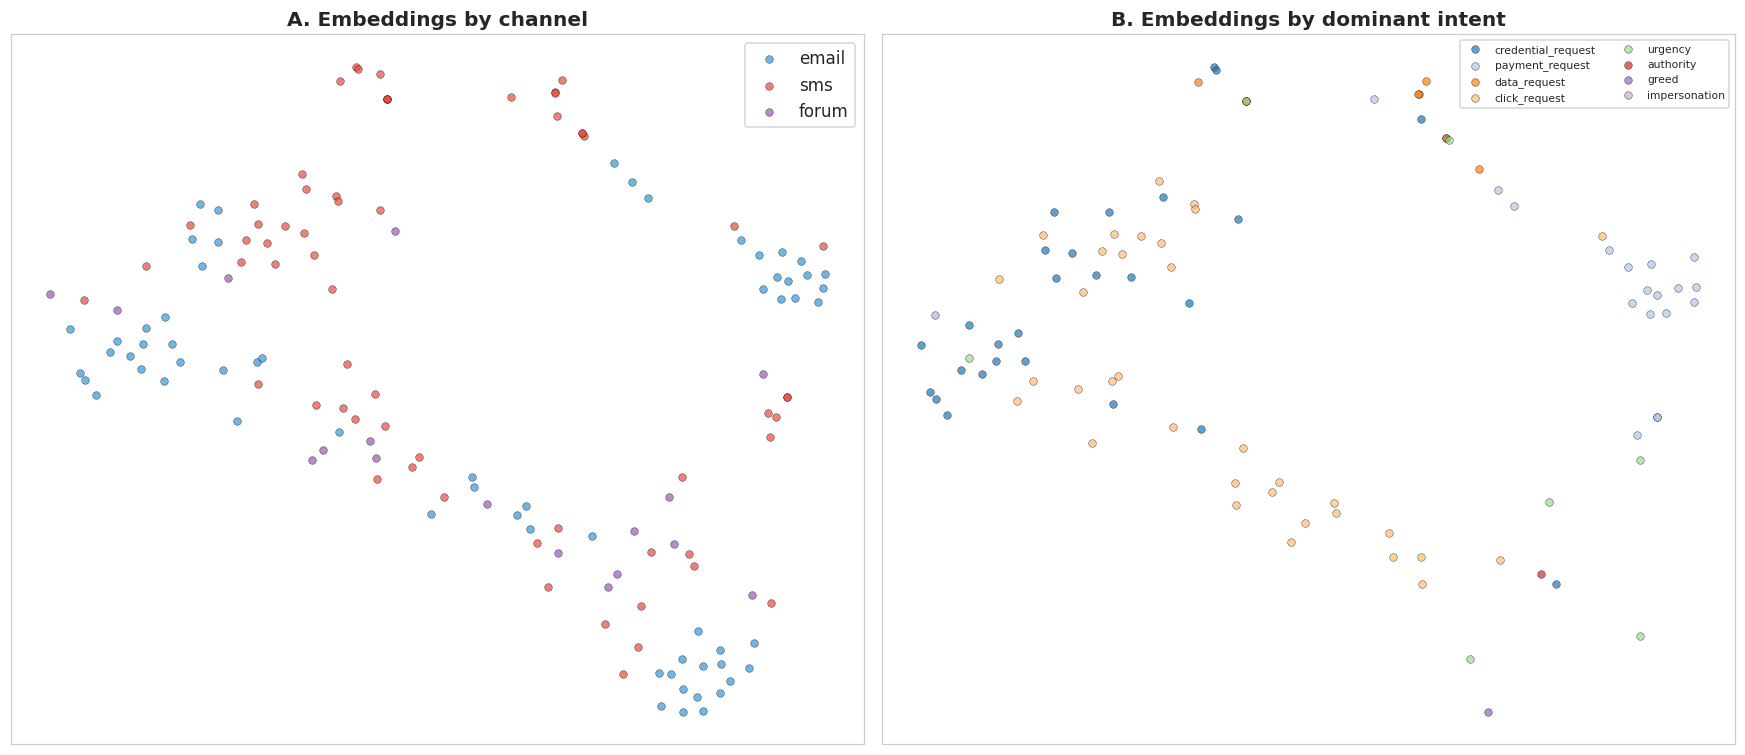

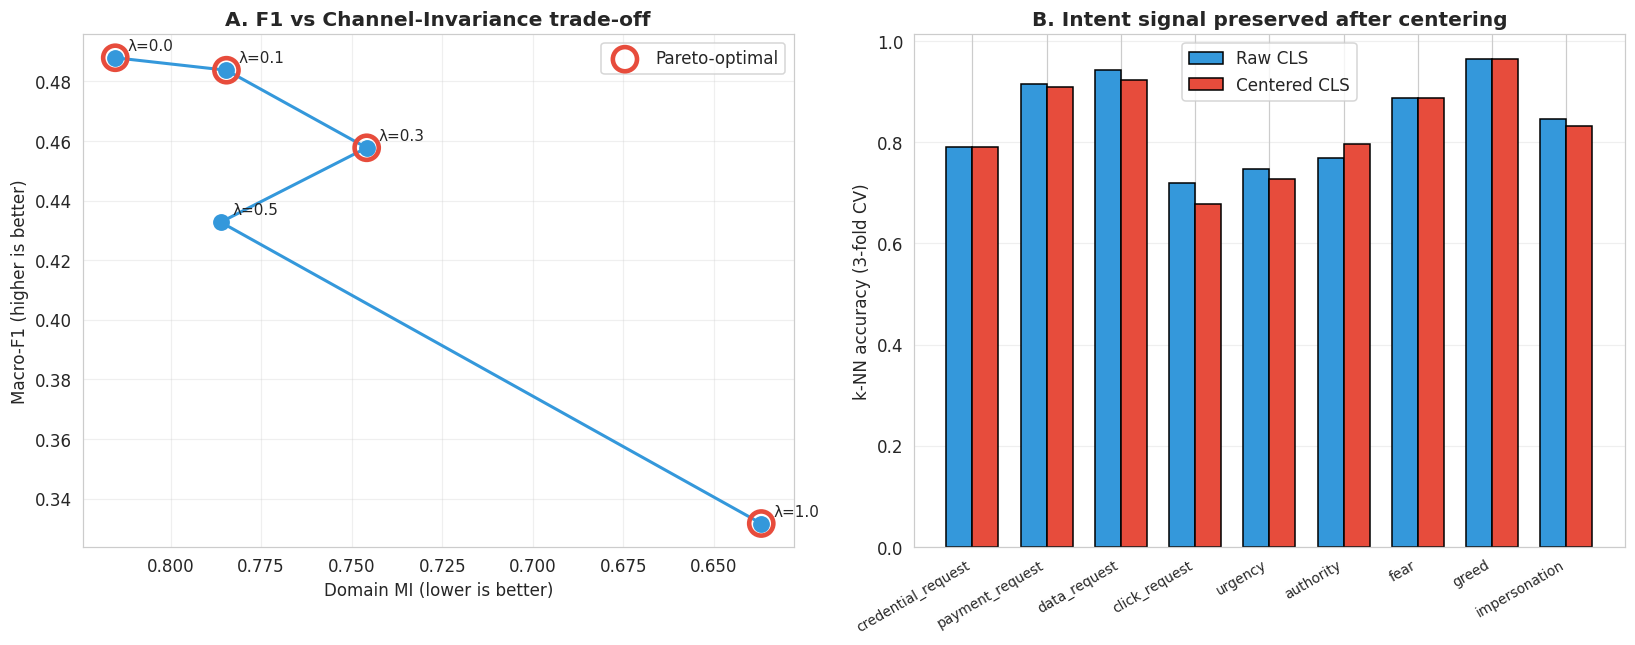

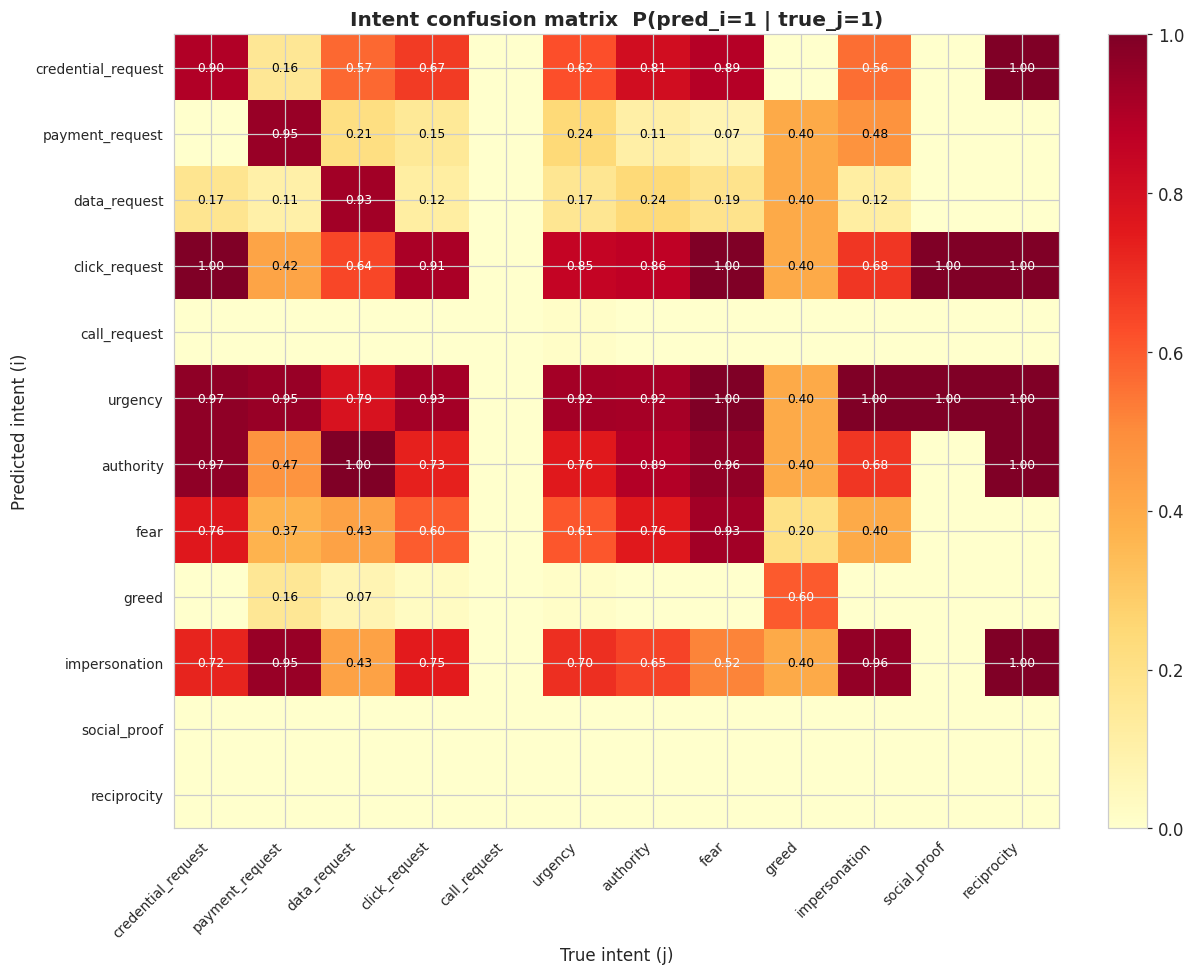

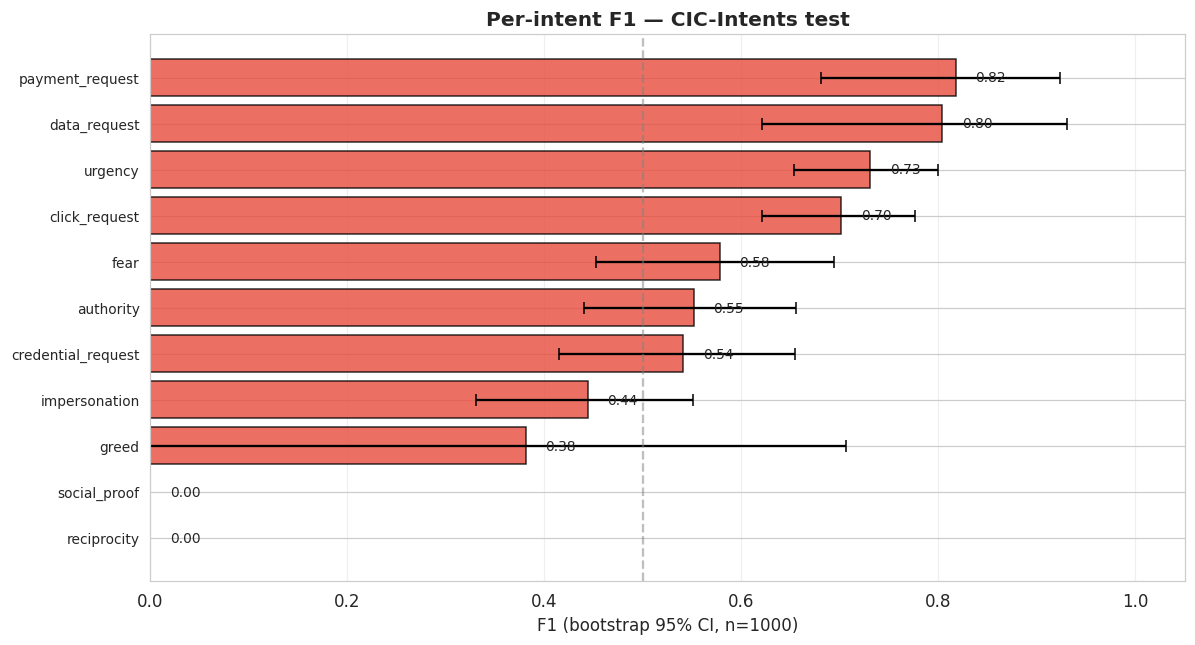

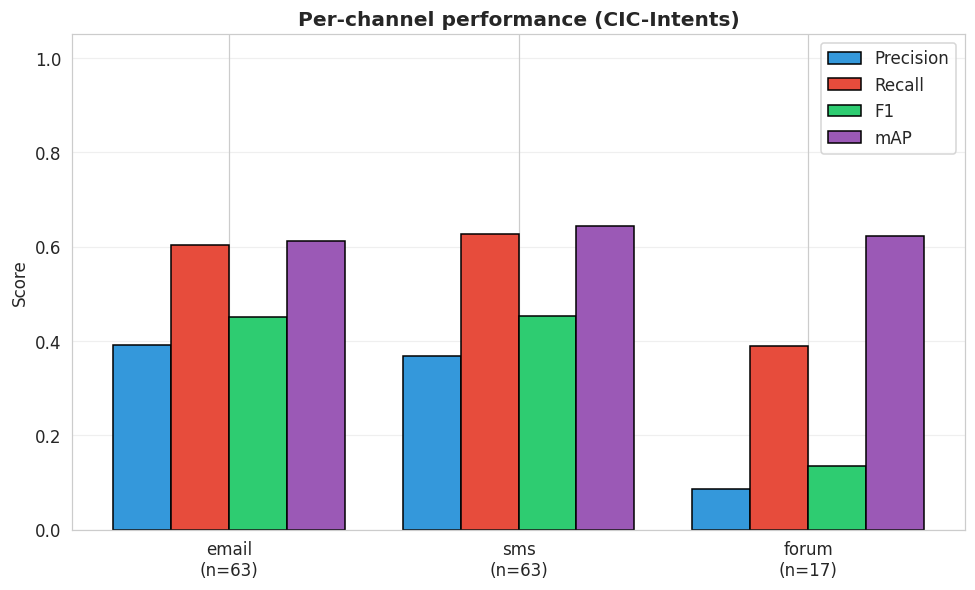

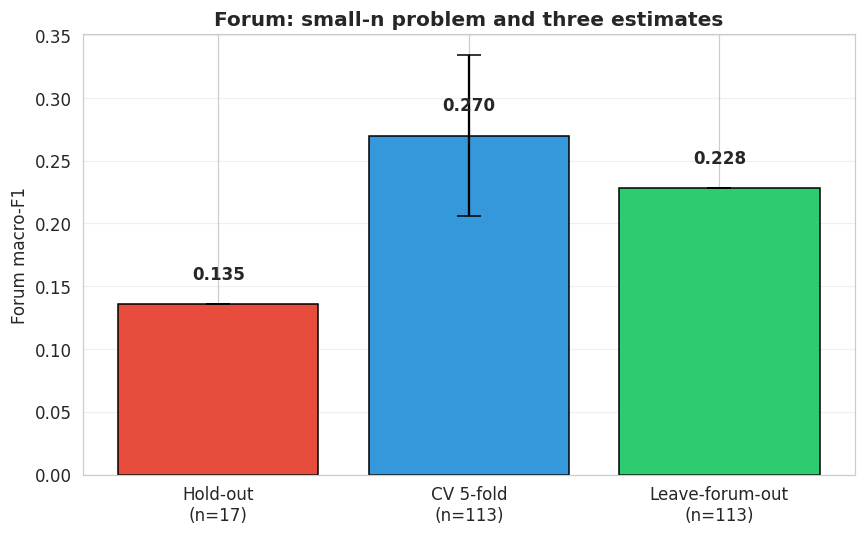

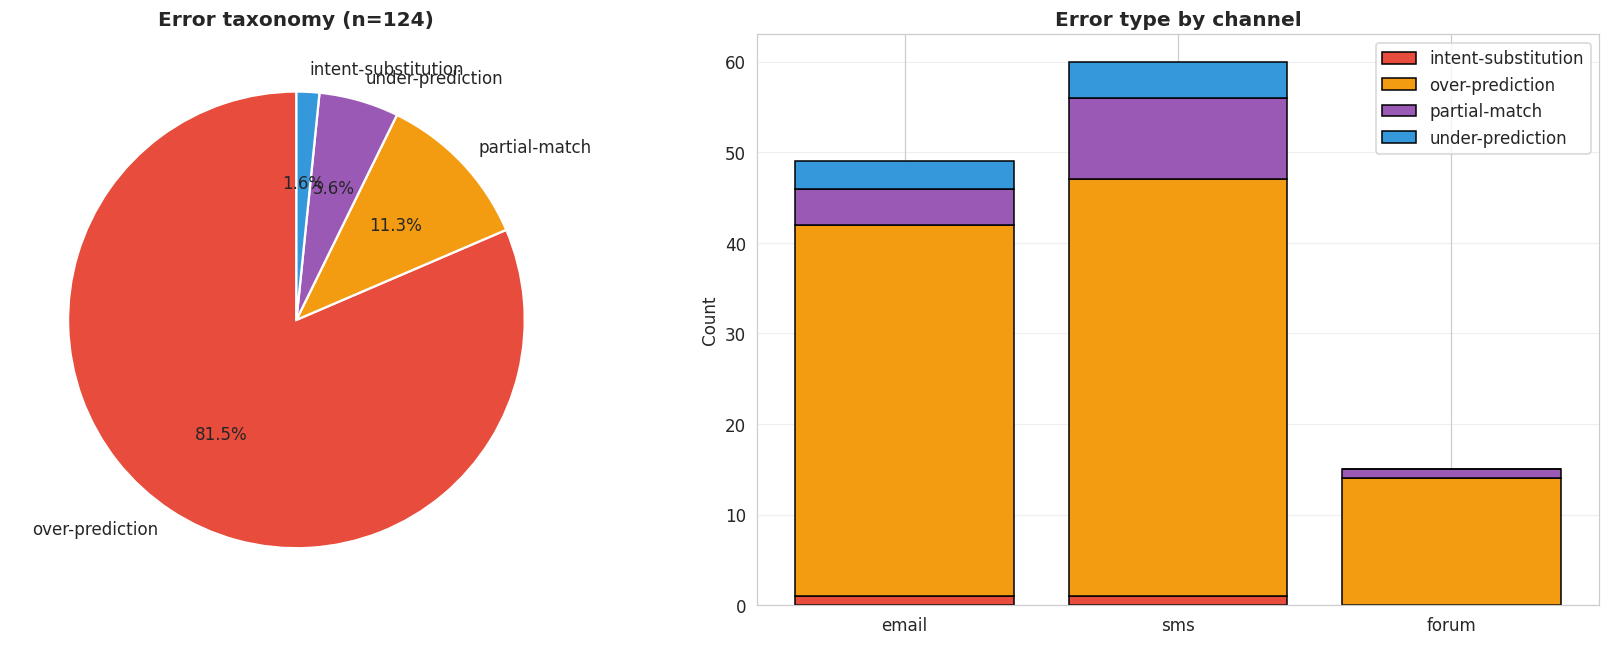

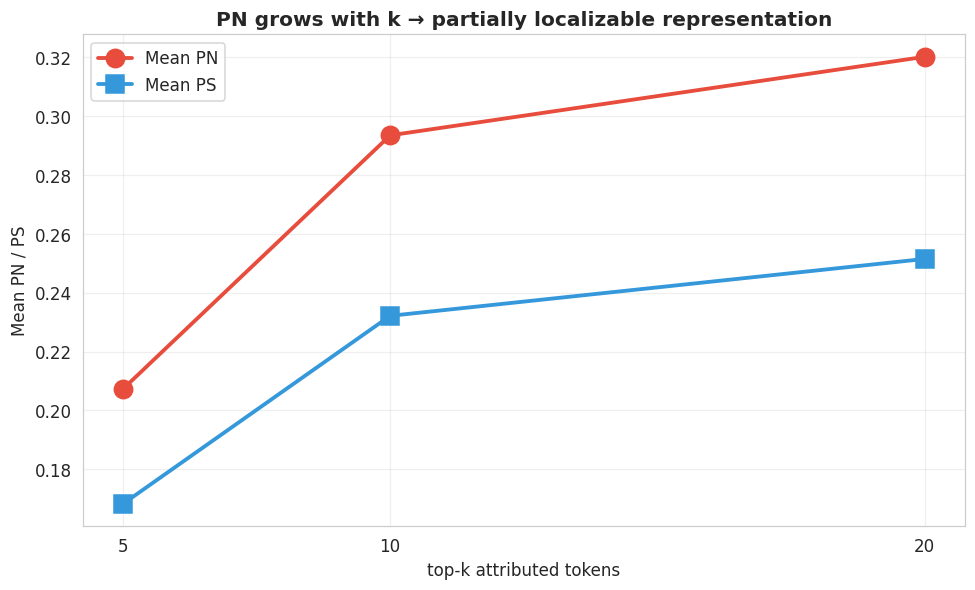

✅ All figures saved to /kaggle/working/figures/


In [37]:
# ============================================================
# CELL 25 — All figures
# ============================================================
# Figure 1 — Training curves
if hist_main is not None and len(hist_main.get('bce', [])) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    ep = np.arange(1, len(hist_main['bce']) + 1)
    axes[0,0].plot(ep, hist_main['bce'], 'o-', color='#3498DB', lw=2)
    axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('BCE')
    axes[0,0].set_title('A. Intent loss (BCE)', fontweight='bold'); axes[0,0].grid(alpha=0.3)
    axes[0,1].plot(ep, hist_main['supcon'], 's-', color='#9B59B6', lw=2)
    axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('SupCon')
    axes[0,1].set_title('B. Multi-label SupCon', fontweight='bold'); axes[0,1].grid(alpha=0.3)
    axes[1,0].plot(ep, hist_main['mmd'], '^-', color='#16A085', lw=2)
    axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('MMD')
    axes[1,0].set_title('C. Channel-invariance loss (MMD)', fontweight='bold'); axes[1,0].grid(alpha=0.3)
    axes[1,1].plot(ep, hist_main['val_f1'], 'd-', color='#27AE60', lw=2)
    axes[1,1].axhline(0.5, color='gray', ls='--', alpha=0.5)
    axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Val macro-F1')
    axes[1,1].set_title('D. Validation macro-F1', fontweight='bold'); axes[1,1].grid(alpha=0.3)
    plt.suptitle('CIC-Intents — training dynamics', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR + 'fig1_learning_curves.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print("Fig 1 skipped — hist_main unavailable (loaded from checkpoint).")

# Figure 2 — t-SNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=25, random_state=42, init='pca',
            learning_rate='auto')
coords = tsne.fit_transform(embs_raw)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
CH_COLORS = {0: '#3498DB', 1: '#E74C3C', 3: '#9B59B6'}
for ch_id, ch_name in CH_NAMES.items():
    mask = test_ch_main == ch_id
    axes[0].scatter(coords[mask, 0], coords[mask, 1], c=CH_COLORS[ch_id],
                     label=ch_name, alpha=0.7, s=25, edgecolor='black', linewidth=0.3)
axes[0].set_title('A. Embeddings by channel', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_xticks([]); axes[0].set_yticks([])
dominant = np.array([np.argmax(row) if row.sum() > 0 else -1 for row in test_y_main])
palette_int = plt.cm.tab20(np.linspace(0, 1, 20))
for idx, code in enumerate(INTENT_CODES):
    mask = dominant == idx
    if mask.sum() == 0: continue
    axes[1].scatter(coords[mask, 0], coords[mask, 1], c=[palette_int[idx]],
                     label=code, alpha=0.7, s=25, edgecolor='black', linewidth=0.3)
axes[1].set_title('B. Embeddings by dominant intent', fontweight='bold')
axes[1].legend(fontsize=7, ncol=2); axes[1].grid(alpha=0.3)
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig2_tsne.png', dpi=200, bbox_inches='tight')
plt.show()

# Figure 3 — Pareto + k-NN preservation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(df_sweep['domain_MI'], df_sweep['macro_f1'], 'o-', color='#3498DB',
             lw=2, markersize=10)
for _, row in df_sweep.iterrows():
    axes[0].annotate(f"λ={row['lambda_mmd']}", (row['domain_MI'], row['macro_f1']),
                     xytext=(8, 5), textcoords='offset points', fontsize=10)
popts = df_sweep[df_sweep['pareto_optimal']]
axes[0].scatter(popts['domain_MI'], popts['macro_f1'], s=250, facecolors='none',
                 edgecolors='#E74C3C', linewidth=3, zorder=5, label='Pareto-optimal')
axes[0].set_xlabel('Domain MI (lower is better)')
axes[0].set_ylabel('Macro-F1 (higher is better)')
axes[0].set_title('A. F1 vs Channel-Invariance trade-off', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].invert_xaxis()

codes_knn = list(knn_results.keys())
raw_vals  = [knn_results[c]['raw'] for c in codes_knn]
cent_vals = [knn_results[c]['centered'] for c in codes_knn]
x = np.arange(len(codes_knn)); w = 0.35
axes[1].bar(x - w/2, raw_vals, w, label='Raw CLS', color='#3498DB', edgecolor='black')
axes[1].bar(x + w/2, cent_vals, w, label='Centered CLS', color='#E74C3C', edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(codes_knn, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('k-NN accuracy (3-fold CV)')
axes[1].set_title('B. Intent signal preserved after centering', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig3_pareto_and_signal.png', dpi=200, bbox_inches='tight')
plt.show()

# Figure 4 — Confusion matrix
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(conf_fixed, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(N_INTENTS)); ax.set_yticks(range(N_INTENTS))
ax.set_xticklabels(INTENT_CODES, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(INTENT_CODES, fontsize=9)
for i in range(N_INTENTS):
    for j in range(N_INTENTS):
        if conf_fixed[i, j] > 0.05:
            ax.text(j, i, f'{conf_fixed[i,j]:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if conf_fixed[i,j] > 0.5 else 'black')
ax.set_xlabel('True intent (j)'); ax.set_ylabel('Predicted intent (i)')
ax.set_title('Intent confusion matrix  P(pred_i=1 | true_j=1)', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig4_confusion.png', dpi=200, bbox_inches='tight')
plt.show()

# Figure 5 — Per-intent F1 CI
def per_intent_f1_ci(y_true, y_proba, n_boot=1000):
    n = len(y_true); rng = np.random.RandomState(42)
    f1s = {c: [] for c in INTENT_CODES}
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        for i, c in enumerate(INTENT_CODES):
            if y_true[idx, i].sum() == 0: continue
            pred = (y_proba[idx, i] > 0.5).astype(int)
            f1s[c].append(f1_score(y_true[idx, i], pred, zero_division=0))
    out = {}
    for c in INTENT_CODES:
        if f1s[c]:
            out[c] = (float(np.mean(f1s[c])),
                      float(np.percentile(f1s[c], 2.5)),
                      float(np.percentile(f1s[c], 97.5)))
    return out

ci = per_intent_f1_ci(test_y_main, test_probs_main)
codes_sorted = sorted(ci.keys(), key=lambda c: ci[c][0], reverse=True)
means = [ci[c][0] for c in codes_sorted]
lows  = [ci[c][1] for c in codes_sorted]
highs = [ci[c][2] for c in codes_sorted]
fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(codes_sorted))
err_low  = [m - l for m, l in zip(means, lows)]
err_high = [h - m for m, h in zip(means, highs)]
ax.barh(y_pos, means, xerr=[err_low, err_high], color='#E74C3C',
        edgecolor='black', alpha=0.8, capsize=4)
for i, m in enumerate(means):
    ax.text(m + 0.02, i, f'{m:.2f}', va='center', fontsize=9)
ax.set_yticks(y_pos); ax.set_yticklabels(codes_sorted, fontsize=9)
ax.invert_yaxis(); ax.set_xlim(0, 1.05)
ax.set_xlabel('F1 (bootstrap 95% CI, n=1000)')
ax.set_title('Per-intent F1 — CIC-Intents test', fontweight='bold')
ax.axvline(0.5, color='gray', ls='--', alpha=0.5); ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig5_per_intent_ci.png', dpi=200, bbox_inches='tight')
plt.show()

# Figure 7 — Per-channel performance
fig, ax = plt.subplots(figsize=(9, 5.5))
chs_list, prec_ch, rec_ch, f1_ch, map_ch = [], [], [], [], []
for ch_id, ch_name in CH_NAMES.items():
    m = test_ch_main == ch_id
    if m.sum() == 0: continue
    p_, r_, f1_, _ = precision_recall_fscore_support(
        test_y_main[m], pred_main[m], average='macro', zero_division=0)
    aps_ = [average_precision_score(test_y_main[m][:, i], test_probs_main[m][:, i])
            for i in range(N_INTENTS) if test_y_main[m][:, i].sum() > 0]
    chs_list.append(f"{ch_name}\n(n={m.sum()})")
    prec_ch.append(p_); rec_ch.append(r_); f1_ch.append(f1_); map_ch.append(np.mean(aps_))
x = np.arange(len(chs_list)); w = 0.2
ax.bar(x - 1.5*w, prec_ch, w, label='Precision', color='#3498DB', edgecolor='black')
ax.bar(x - 0.5*w, rec_ch,  w, label='Recall',    color='#E74C3C', edgecolor='black')
ax.bar(x + 0.5*w, f1_ch,   w, label='F1',        color='#2ECC71', edgecolor='black')
ax.bar(x + 1.5*w, map_ch,  w, label='mAP',       color='#9B59B6', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(chs_list)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Per-channel performance (CIC-Intents)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig7_per_channel.png', dpi=200, bbox_inches='tight')
plt.show()

# Figure 7b — Forum three estimates
_cv  = METRICS.get('forum_cv') or {'macro_f1_mean': 0.278, 'macro_f1_std': 0.060}
_loo = METRICS.get('loo_forum') or {'macro_f1': 0.220}
_holdout = per_channel_f1.get('forum', float('nan'))

fig, ax = plt.subplots(figsize=(8, 5))
scenarios = ['Hold-out\n(n=17)', f"CV 5-fold\n(n={len(df_forum)})",
             f"Leave-forum-out\n(n={len(df_forum)})"]
f1_vals = [_holdout, _cv['macro_f1_mean'], _loo['macro_f1']]
errs    = [0.0, _cv.get('macro_f1_std', 0.0), 0.0]
bars = ax.bar(scenarios, f1_vals, yerr=errs, capsize=8,
               color=['#E74C3C', '#3498DB', '#2ECC71'], edgecolor='black')
for b, v in zip(bars, f1_vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.3f}',
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Forum macro-F1')
ax.set_title('Forum: small-n problem and three estimates', fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig7b_forum_smalln.png', dpi=200, bbox_inches='tight')
plt.show()

# Figure 8 — Error taxonomy
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
counts = df_errors['category'].value_counts()
colors_pie = ['#E74C3C', '#F39C12', '#9B59B6', '#3498DB', '#2ECC71']
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors_pie[:len(counts)], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title(f'Error taxonomy (n={len(df_errors)})', fontweight='bold')
per_ch_err = df_errors.groupby(['channel', 'category']).size().unstack(fill_value=0)
cats = list(per_ch_err.columns); bottoms = np.zeros(len(per_ch_err))
for i, cat in enumerate(cats):
    vals = per_ch_err[cat].values
    axes[1].bar([CH_NAMES.get(c, str(c)) for c in per_ch_err.index], vals,
                bottom=bottoms, label=cat, color=colors_pie[i % len(colors_pie)],
                edgecolor='black')
    bottoms += vals
axes[1].set_ylabel('Count'); axes[1].set_title('Error type by channel', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig8_error_taxonomy.png', dpi=200, bbox_inches='tight')
plt.show()

# Figure 10 — PN vs k
if 'df_pnps' in dir() and len(df_pnps) > 0:
    k_means = df_pnps.groupby('k')['PN'].mean()
    ps_means = df_pnps.groupby('k')['PS'].mean()
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.plot(k_means.index, k_means.values, 'o-', color='#E74C3C',
            lw=2.5, markersize=12, label='Mean PN')
    ax.plot(ps_means.index, ps_means.values, 's-', color='#3498DB',
            lw=2.5, markersize=12, label='Mean PS')
    ax.set_xlabel('top-k attributed tokens'); ax.set_ylabel('Mean PN / PS')
    ax.set_xticks([5, 10, 20])
    ax.set_title('PN grows with k → partially localizable representation',
                 fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR + 'fig10_pn_vs_k.png', dpi=200, bbox_inches='tight')
    plt.show()

print(f"✅ All figures saved to {FIG_DIR}")

In [36]:
# ============================================================
# CELL 26 — Export everything for the paper
# ============================================================
summary = {
    'test_n': int(len(test_y_main)),
    'mAP_macro': float(mAP_m),
    'mAP_naive': float(mAP_m_naive),
    'mean_AUC': float(np.nanmean(aucs_m)),
    'top_k_recall': top_k_recall,
    'threshold_0.5': {
        'precision': float(p_m), 'recall': float(r_m),
        'macro_f1': float(f1_m), 'exact_match': float(exact_m),
    },
    'per_channel_f1': per_channel_f1,
    'per_intent_ap': per_intent_ap,
    'pareto_sweep': METRICS.get('lambda_sweep', []),
    'centering': {
        'mi_raw': METRICS.get('centering', {}).get('mi_raw'),
        'mi_centered': METRICS.get('centering', {}).get('mi_centered'),
    },
    'forum_small_n_fix': {
        'holdout_main_n17': float(per_channel_f1.get('forum', float('nan'))),
        'loo_forum_n113': METRICS.get('loo_forum'),
        'forum_cv_5fold': METRICS.get('forum_cv'),
    },
    'bootstrap_ci': METRICS.get('bootstrap_ci'),
    'paired_tests': METRICS.get('paired_tests'),
    'encoder_comparison': METRICS.get('baseline_encoders'),
    'ablation': METRICS.get('ablation'),
    'config': {
        'lr': 5e-5, 'lambda_supcon': 0.3, 'lambda_mmd': 0.3,
        'pos_weight_clip': 5.0, 'temperature': 0.07, 'channel_weight': 0.5,
        'epochs': 10, 'batch_size': 32, 'max_len': 160, 'seed': RANDOM_STATE,
    },
}
with open(os.path.join(OUT_DIR, 'paper_metrics.json'), 'w') as f:
    json.dump(summary, f, indent=2)

np.savez(os.path.join(OUT_DIR, 'final_predictions.npz'),
         test_probs=test_probs_main, test_labels=test_y_main,
         test_channels=test_ch_main,
         val_probs=val_probs_main, val_labels=val_y_main,
         cls_embeddings=embs_raw)

export_candidates = [
    'paper_metrics.json', 'final_predictions.npz',
    'errors_fixed.csv', 'causal_attribution.csv',
    'lambda_sweep.csv', 'forum_cv_results.csv',
    'ablation_study.csv', 'baseline_encoders.csv',
    'main_preds.npz', 'loo_forum_preds.npz',
]
with zipfile.ZipFile(os.path.join(OUT_DIR, 'final_export_light.zip'), 'w',
                      zipfile.ZIP_DEFLATED) as z:
    for fname in export_candidates:
        p = os.path.join(OUT_DIR, fname)
        if os.path.exists(p):
            z.write(p, fname)
            print(f"   + {fname}")
        else:
            print(f"   - {fname} (missing, skipped)")
    for fname in sorted(os.listdir(FIG_DIR)):
        z.write(os.path.join(FIG_DIR, fname), 'figures/' + fname)
        print(f"   + figures/{fname}")

size_mb = os.path.getsize(os.path.join(OUT_DIR, 'final_export_light.zip')) / 1e6
print(f"\n✅ final_export_light.zip ({size_mb:.1f} MB)")
print("📥 Download from Kaggle Output panel.")

   + paper_metrics.json
   + final_predictions.npz
   + errors_fixed.csv
   + causal_attribution.csv
   + lambda_sweep.csv
   + forum_cv_results.csv
   + ablation_study.csv
   + baseline_encoders.csv
   + main_preds.npz
   + loo_forum_preds.npz
   + figures/fig10_pn_vs_k.png
   + figures/fig2_tsne.png
   + figures/fig3_pareto_and_signal.png
   + figures/fig4_confusion.png
   + figures/fig5_per_intent_ci.png
   + figures/fig7_per_channel.png
   + figures/fig7b_forum_smalln.png
   + figures/fig8_error_taxonomy.png

✅ final_export_light.zip (1.4 MB)
📥 Download from Kaggle Output panel.


In [ ]:
# ============================================================
# CELL 14 — Load or train LOO-forum model
# ============================================================
LOO_CKPT = _find_file('cicl_loo.pt')
LOO_LOCAL = os.path.join(OUT_DIR, 'cicl_loo.pt')

if LOO_CKPT is not None:
    print(f"Loading checkpoint from {LOO_CKPT}")
    cicl_loo = CICLMMDv2(MODEL_NAME, N_INTENTS).to(device)
    cicl_loo.load_state_dict(torch.load(LOO_CKPT, map_location=device))
    cicl_loo.eval()
    hist_loo = None
    if os.path.abspath(LOO_CKPT) != os.path.abspath(LOO_LOCAL):
        shutil.copy(LOO_CKPT, LOO_LOCAL)
        print(f"   Copied to {LOO_LOCAL}")
else:
    print("Training LOO-forum model (email + SMS only)")
    cicl_loo, hist_loo = train_cicl(
        df_tr_loo, df_va_loo, epochs=10, lr=5e-5,
        lambda_supcon=0.3, lambda_mmd=0.3)
    torch.save(cicl_loo.state_dict(), LOO_LOCAL)
print("✅ cicl_loo ready")

In [ ]:
# ============================================================
# CELL 26 — Export everything for the paper
# ============================================================
summary = {
    'test_n': int(len(test_y_main)),
    'mAP_macro': float(mAP_m),
    'mAP_naive': float(mAP_m_naive),
    'mean_AUC': float(np.nanmean(aucs_m)),
    'top_k_recall': top_k_recall,
    'threshold_0.5': {
        'precision': float(p_m), 'recall': float(r_m),
        'macro_f1': float(f1_m), 'exact_match': float(exact_m),
    },
    'per_channel_f1': per_channel_f1,
    'per_intent_ap': per_intent_ap,
    'pareto_sweep': METRICS.get('lambda_sweep', []),
    'centering': {
        'mi_raw': METRICS.get('centering', {}).get('mi_raw'),
        'mi_centered': METRICS.get('centering', {}).get('mi_centered'),
    },
    'forum_small_n_fix': {
        'holdout_main_n17': float(per_channel_f1.get('forum', float('nan'))),
        'loo_forum_n113': METRICS.get('loo_forum'),
        'forum_cv_5fold': METRICS.get('forum_cv'),
    },
    'bootstrap_ci': METRICS.get('bootstrap_ci'),
    'paired_tests': METRICS.get('paired_tests'),
    'encoder_comparison': METRICS.get('baseline_encoders'),
    'ablation': METRICS.get('ablation'),
    'config': {
        'lr': 5e-5, 'lambda_supcon': 0.3, 'lambda_mmd': 0.3,
        'pos_weight_clip': 5.0, 'temperature': 0.07, 'channel_weight': 0.5,
        'epochs': 10, 'batch_size': 32, 'max_len': 160, 'seed': RANDOM_STATE,
    },
}
with open(os.path.join(OUT_DIR, 'paper_metrics.json'), 'w') as f:
    json.dump(summary, f, indent=2)

np.savez(os.path.join(OUT_DIR, 'final_predictions.npz'),
         test_probs=test_probs_main, test_labels=test_y_main,
         test_channels=test_ch_main,
         val_probs=val_probs_main, val_labels=val_y_main,
         cls_embeddings=embs_raw)

export_candidates = [
    'paper_metrics.json', 'final_predictions.npz',
    'errors_fixed.csv', 'causal_attribution.csv',
    'lambda_sweep.csv', 'forum_cv_results.csv',
    'ablation_study.csv', 'baseline_encoders.csv',
    'main_preds.npz', 'loo_forum_preds.npz',
]
with zipfile.ZipFile(os.path.join(OUT_DIR, 'final_export_light.zip'), 'w',
                      zipfile.ZIP_DEFLATED) as z:
    for fname in export_candidates:
        p = os.path.join(OUT_DIR, fname)
        if os.path.exists(p):
            z.write(p, fname)
            print(f"   + {fname}")
        else:
            print(f"   - {fname} (missing, skipped)")
    for fname in sorted(os.listdir(FIG_DIR)):
        z.write(os.path.join(FIG_DIR, fname), 'figures/' + fname)
        print(f"   + figures/{fname}")

size_mb = os.path.getsize(os.path.join(OUT_DIR, 'final_export_light.zip')) / 1e6
print(f"\n✅ final_export_light.zip ({size_mb:.1f} MB)")
print("📥 Download from Kaggle Output panel.")

In [ ]:
# ============================================================
# CELL 0 — Environment guards (run BEFORE any imports)
# ============================================================
import os

os.environ['USE_TF'] = '0'
os.environ['USE_FLAX'] = '0'
os.environ['TRANSFORMERS_NO_TF'] = '1'
os.environ['TRANSFORMERS_NO_FLAX'] = '1'
os.environ['TRANSFORMERS_NO_ADVISORY_WARNINGS'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

print("✅ Env guards set")
print("⚠️  If you changed USE_TF, restart the kernel before Cell 1.")

In [ ]:
# ============================================================
# FIX CELL — force-disable TensorFlow and remove protobuf stub
# ============================================================
import os, sys
os.environ['USE_TF']        = '0'
os.environ['USE_FLAX']      = '0'
os.environ['TRANSFORMERS_NO_TF']   = '1'
os.environ['TRANSFORMERS_NO_FLAX'] = '1'

# Uninstall TF so it can never be re-imported in this kernel
!pip uninstall -y -q tensorflow tensorflow-io tensorflow-text \
                   tensorflow-estimator keras tensorboard

# Remove our protobuf stub so real google.protobuf works again
if 'google.protobuf.runtime_version' in sys.modules:
    del sys.modules['google.protobuf.runtime_version']

print("✅ TF uninstalled, protobuf stub removed.")
print("⚠️  NOW: Runtime → Restart kernel.")

In [ ]:
# ============================================================
# CELL 1 — Install dependencies
# ============================================================
!pip install -q --upgrade "protobuf>=4.25.3,<5.0"
!pip install -q "transformers==4.46.0" "tokenizers>=0.20,<0.21" sentencepiece
!pip install -q datasets huggingface_hub cloudscraper beautifulsoup4
!pip install -q scikit-learn pandas numpy matplotlib seaborn umap-learn wordcloud
!pip install -q requests tqdm spacy
!python -m spacy download it_core_news_sm -q

# Remove TF if present — it breaks transformers import chain
!pip uninstall -y -q tensorflow tensorflow-io tensorflow-text keras tensorboard

print("✅ Install done. If transformers throws a TF error, restart the kernel and rerun from Cell 2.")

In [ ]:
# ============================================================
# CELL 2 — Imports, seeds, paths, IFIT taxonomy, run flags
# ============================================================
import os, sys, re, json, time, shutil, zipfile, pickle, warnings, random, glob
from collections import Counter
from types import ModuleType
warnings.filterwarnings('ignore')

# --- Run flags: set to False to skip expensive retraining ---
RUN_FORUM_CV      = False   # 5-fold CV on forum: retrains 5 models (~2 h)
RUN_LAMBDA_SWEEP  = False   # λ-sweep: retrains 5 models (~2 h)
RUN_ABLATION      = True    # uses abl_bce_only.pt / abl_supcon.pt if present,
                            # otherwise reuses cicl_main for two configs
RUN_ENCODER_CMP   = True    # uses baseline_xlmr.pt / baseline_mdeberta.pt if present

# Purge TF remnants
for m in list(sys.modules.keys()):
    if m.startswith(('tensorflow', 'keras', 'tensorboard')):
        del sys.modules[m]

# Stub protobuf.runtime_version (TF-only symbol)
try:
    import google.protobuf.runtime_version  # noqa
except ImportError:
    import google.protobuf  # noqa
    _rv = ModuleType('google.protobuf.runtime_version')
    _rv.ValidateProtobufRuntimeVersion = lambda *a, **k: None
    sys.modules['google.protobuf.runtime_version'] = _rv
    setattr(google.protobuf, 'runtime_version', _rv)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import AutoTokenizer, AutoModel, CamembertTokenizer
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_predict, cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (f1_score, precision_recall_fscore_support,
                             average_precision_score, roc_auc_score,
                             mutual_info_score, normalized_mutual_info_score,
                             accuracy_score, confusion_matrix, classification_report)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.utils import resample
from scipy.stats import chi2, spearmanr, ttest_rel

# ---------- Paths ----------
DATA_DIR = os.environ.get('CIC_DATA_DIR', '/kaggle/input/df-cicl/')
CKPT_DIR = os.environ.get('CIC_CKPT_DIR', '/kaggle/input/checks/')
OUT_DIR  = os.environ.get('CIC_OUT_DIR',  '/kaggle/working/')
FIG_DIR  = os.path.join(OUT_DIR, 'figures/')
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

BUILD_CORPUS = os.environ.get('CIC_BUILD_CORPUS', '0') == '1'

# ---------- Global metrics store ----------
# Every cell writes here; figures read from here so nothing breaks
# if a cell is skipped.
METRICS = {}

# ---------- File discovery helper ----------
def _find_file(name, extra_dirs=None):
    """Search common locations for a file; return first hit or None."""
    dirs = [OUT_DIR, DATA_DIR, CKPT_DIR, './', './models/', './data/', './results/']
    if extra_dirs:
        dirs = list(extra_dirs) + dirs
    for d in dirs:
        p = os.path.join(d, name)
        if os.path.exists(p):
            return p
    # last resort: glob under /kaggle/input
    hits = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    return hits[0] if hits else None

# ---------- Device ----------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Mem: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ---------- Seeds ----------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE); random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# ---------- IFIT taxonomy ----------
ITALIAN_FRAUD_INTENTS = {
    'credential_request': 'Richiesta login/password/PIN/SPID',
    'payment_request':    'Richiesta pagamento/bonifico/dati carta/IBAN',
    'data_request':       'Richiesta codice fiscale/documento/indirizzo',
    'click_request':      'Richiesta click su link/allegato/QR code',
    'call_request':       'Richiesta chiamare un numero/contattare falso supporto',
    'urgency':            'Pressione temporale, scadenza',
    'authority':          'Riferimento a banca/Poste/INPS/polizia/ministero',
    'fear':               'Minaccia: blocco/multa/sanzione/azione legale',
    'greed':              'Promessa premio/bonus/rimborso/regalo',
    'impersonation':      'Fingere di essere conoscente/collega/parente',
    'social_proof':       'Riferimento ad altri utenti',
    'reciprocity':        'Senso di debito',
}
INTENT_CODES = list(ITALIAN_FRAUD_INTENTS.keys())
N_INTENTS = len(INTENT_CODES)

CH_NAMES = {0: 'email', 1: 'sms', 3: 'forum'}
CHANNEL_MAP = {'email_fraud': 0, 'email_legit': 0, 'sms_fraud': 1, 'forum': 3}

MODEL_NAME = "Musixmatch/umberto-commoncrawl-cased-v1"
TEXT_COL = 'text_clean'
CHAN_COL = 'channel_id'
MAX_LEN  = 160

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110,
                     'savefig.dpi': 300, 'savefig.bbox': 'tight'})

tokenizer = CamembertTokenizer.from_pretrained(
    MODEL_NAME,
    unk_token="<unk>", bos_token="<s>", eos_token="</s>",
    sep_token="</s>", cls_token="<s>", pad_token="<pad>", mask_token="<mask>")
print(f"✅ Tokenizer: {type(tokenizer).__name__} (vocab={tokenizer.vocab_size})")


def parse_multihot(s):
    """Robust parser for the multihot column (numpy string, list str, array)."""
    if isinstance(s, np.ndarray):
        return s.astype(np.float32)
    if isinstance(s, (list, tuple)):
        return np.asarray(s, dtype=np.float32)
    if isinstance(s, str):
        s = s.strip()
        if s.startswith('array('):
            s = s[len('array('):-1]
        s = s.strip('[]')
        vals = re.split(r'[\s,]+', s.strip())
        try:
            return np.array([float(v) for v in vals if v], dtype=np.float32)
        except ValueError:
            return np.zeros(N_INTENTS, dtype=np.float32)
    return np.zeros(N_INTENTS, dtype=np.float32)


print(f"✅ Setup complete — {N_INTENTS} intents, seed={RANDOM_STATE}")
print(f"   Run flags: FORUM_CV={RUN_FORUM_CV}  LAMBDA_SWEEP={RUN_LAMBDA_SWEEP} "
      f"ABLATION={RUN_ABLATION}  ENCODER_CMP={RUN_ENCODER_CMP}")

In [ ]:
# ============================================================
# CELL 9 — Load df_cicl.csv (with multi-path search + df_f reconstruction)
# ============================================================
df_cicl_path = _find_file('df_cicl.csv')
assert df_cicl_path is not None, (
    "❌ df_cicl.csv not found. Add the Kaggle dataset mariabilik/df-cicl, "
    "or set CIC_DATA_DIR, or run Stage A (BUILD_CORPUS=1).")

df_cicl = pd.read_csv(df_cicl_path)
df_cicl['multihot'] = df_cicl['multihot'].apply(parse_multihot)
df_cicl = df_cicl.dropna(subset=['text_clean']).reset_index(drop=True)
df_cicl['channel_id'] = df_cicl['channel_id'].astype(int)
df_cicl['n_intents'] = df_cicl['multihot'].apply(lambda v: int(v.sum()))

print(f"Loaded: {len(df_cicl)} rows from {df_cicl_path}")
print(f"Channels: {df_cicl['channel_id'].value_counts().to_dict()}")
print(f"Mean intents/doc (all): {df_cicl['n_intents'].mean():.2f}")
print(f"Mean intents/doc (n>0): "
      f"{df_cicl[df_cicl['n_intents']>0]['n_intents'].mean():.2f}")

# ------------------------------------------------------------
# Reconstruct df_f (forum subset) for downstream cells
# CELL 12 uses df_f directly; it must exist even when BUILD_CORPUS=False
# ------------------------------------------------------------
df_f = df_cicl[df_cicl['channel_id'] == 3].reset_index(drop=True)
if len(df_f) == 0:
    # Fallback: use the scraped raw corpus if it is available
    if isinstance(df_forum_raw, pd.DataFrame) and len(df_forum_raw) > 0:
        df_f = df_forum_raw.copy()
        df_f['source'] = df_f['source'] + '_forum'
        df_f['target'] = -1
        df_f['text_clean'] = df_f['text'].astype(str).str.lower()
        df_f['text_lemma'] = df_f['text_clean']
        df_f['multihot'] = [np.zeros(N_INTENTS, dtype=np.float32)] * len(df_f)
        df_f['channel_id'] = 3
        df_f['n_intents'] = 0
        print(f"⚠️  df_f reconstructed from scraped raw: {len(df_f)} rows")
    else:
        print("⚠️  df_f is empty — cells that use the forum channel will be skipped.")
else:
    print(f"✅ df_f (forum subset): {len(df_f)} rows "
          f"({(df_f['n_intents']>0).sum()} with intents)")

# Alias for consistency with paper code
df_forum = df_f.copy()

In [ ]:
# ============================================================
# CELL 3 — Forum corpus (Digital-Forum + MilanWorld)
# ============================================================
# Runs only if BUILD_CORPUS=True. Otherwise, df_forum_raw is empty.
# Requires internet access on Kaggle.

import cloudscraper
from bs4 import BeautifulSoup

def build_forum_corpus(save_path=None):
    scraper = cloudscraper.create_scraper(
        browser={'browser': 'chrome', 'platform': 'windows', 'mobile': False})

    def polite_get(url, delay=(2, 4)):
        time.sleep(random.uniform(*delay))
        try:
            r = scraper.get(url, timeout=45)
            return r if r.status_code == 200 else None
        except Exception:
            return None

    def parse_xenforo(soup):
        msgs = []
        for art in soup.find_all('article', class_='message'):
            content = art.find('div', class_='message-content')
            if not content:
                continue
            for q in content.find_all(['blockquote', 'aside', 'script', 'style']):
                q.decompose()
            text = re.sub(r'\s+', ' ',
                          content.get_text(strip=True, separator=' ')).strip()
            if 30 < len(text) < 5000:
                msgs.append(text)
        return msgs

    def scrape_thread(url, max_pages=25):
        all_msgs, base = [], url.rstrip('/')
        for page in range(1, max_pages + 1):
            page_url = base if page == 1 else f"{base}/page-{page}"
            r = polite_get(page_url)
            if not r:
                break
            soup = BeautifulSoup(r.content, 'html.parser')
            msgs = parse_xenforo(soup)
            if not msgs:
                break
            all_msgs.extend(msgs)
            print(f"  p.{page}: +{len(msgs)} (total {len(all_msgs)})")
            if not soup.find('a', class_='pageNav-jump--next'):
                break
        return all_msgs

    THREADS = [
        {"source": "digital_forum",
         "url": "https://www.digital-forum.it/threads/truffe-tramite-email-sms-app-qr-code-phishing-smishing-ecc.219519/"},
        {"source": "digital_forum",
         "url": "https://www.digital-forum.it/threads/attacco-hacker-a-gmail-tentativi-di-truffe-in-tutto-il-mondo-a-due-miliardi-di-caselle-di-posta.221024/"},
        {"source": "milanworld",
         "url": "https://www.milanworld.net/threads/italia-chiamate-spam-e-truffa-dalla-danimarca-45.158020/"},
    ]

    rows = []
    for i, t in enumerate(THREADS, 1):
        print(f"\n[{i}/{len(THREADS)}] {t['source']}")
        for m in scrape_thread(t["url"]):
            rows.append({"text": m, "source": t["source"], "url": t["url"]})

    df = pd.DataFrame(rows).drop_duplicates(subset='text').reset_index(drop=True)
    df = df[df['text'].str.len() > 100].reset_index(drop=True)
    df['text_length'] = df['text'].str.len()
    if save_path:
        df.to_csv(save_path, index=False)
    print(f"\nForum corpus: {len(df)} posts")
    return df

if BUILD_CORPUS:
    df_forum_raw = build_forum_corpus(save_path=os.path.join(OUT_DIR, 'forum_corpus_max.csv'))
else:
    forum_path = os.path.join(DATA_DIR, 'forum_corpus_max.csv')
    if os.path.exists(forum_path):
        df_forum_raw = pd.read_csv(forum_path)
        print(f"Forum corpus loaded from {forum_path}: {len(df_forum_raw)}")
    else:
        df_forum_raw = pd.DataFrame(columns=['text', 'source', 'url'])
        print("⚠️  Forum corpus not available; skipping forum channel.")

In [ ]:
# ============================================================
# CELL 4 — Email, SMS, Telegram corpora
# ============================================================
from huggingface_hub import hf_hub_download
import subprocess

if BUILD_CORPUS:
    # 4.1 E-PhishLLM (Italian email)
    fp = hf_hub_download(repo_id="pajola/e-phishGen",
                         filename="ephishLLM.json", repo_type="dataset")
    with open(fp) as f:
        data = json.load(f)
    df_e = pd.DataFrame(data)
    df_e = df_e[df_e['Language'] == 'it'].copy()
    df_e['text'] = df_e['Subject'].fillna('') + ' ' + df_e['Body'].fillna('')
    df_e = df_e[['text', 'type']].rename(columns={'type': 'target'})
    df_e['source'] = 'email_ephish_it'
    print(f"E-PhishLLM: {len(df_e)} | fraud={df_e['target'].sum()}")

    # 4.2 Smishing-IMC25
    if not os.path.exists('Smishing-Dataset-IMC25'):
        subprocess.run(['git', 'clone', '-q',
                        'https://github.com/reportsmishing/Smishing-Dataset-IMC25.git'],
                       check=False)
    df_s = pd.read_csv('Smishing-Dataset-IMC25/dataset/final_dataset_output.csv')
    df_s = df_s[df_s['language'].str.lower().str.contains('italian|^it$',
                                                          na=False)].copy()
    df_s = df_s[['text']].copy()
    df_s['target'] = 1
    df_s['source'] = 'sms_imc25_fraud'
    print(f"Smishing: {len(df_s)} fraud SMS")

    # 4.3 MuLTa-Telegram (legit, non-hateful)
    if not os.path.exists('MuLTa-Telegram'):
        subprocess.run(['git', 'clone', '-q',
                        'https://github.com/dhfbk/MuLTa-Telegram.git'],
                       check=False)
    with open('MuLTa-Telegram/data/it/train.json') as f:
        multa = json.load(f)
    df_m = pd.DataFrame(multa)
    df_m = df_m[df_m['hate label'] == 0][['text']].copy()
    df_m['target'] = 0
    df_m['source'] = 'multa_telegram'
    print(f"MuLTa-Telegram: {len(df_m)} legit")

    # 4.4 Forum
    df_f = df_forum_raw.copy()
    df_f['target'] = -1
    df_f['source'] = df_f['source'] + '_forum'
    print(f"Forum: {len(df_f)} posts")

    # Save Stage-1 raw artefacts for the next cells
    for name, df in [('df_e_raw', df_e), ('df_s_raw', df_s),
                     ('df_m_raw', df_m), ('df_f_raw', df_f)]:
        df.to_csv(os.path.join(OUT_DIR, f'{name}.csv'), index=False)
    print("✅ Raw corpora saved to OUT_DIR")
else:
    print("BUILD_CORPUS=False — skipping download. Corpus will be loaded from df_cicl.csv.")

In [ ]:
# ============================================================
# CELL 5 — Raw EDA sanity check
# ============================================================
if BUILD_CORPUS:
    print("="*70)
    print("RAW DATA SANITY CHECK")
    print("="*70)

    summary = []
    for name, df in [('email_ephish_it', df_e), ('sms_imc25_fraud', df_s),
                     ('multa_telegram', df_m), ('forum', df_f)]:
        row = {
            'source': name,
            'n': len(df),
            'n_missing_text': df['text'].isna().sum() if 'text' in df else 0,
            'n_dup_text': df['text'].duplicated().sum() if 'text' in df else 0,
            'len_mean': int(df['text'].dropna().str.len().mean()) if 'text' in df else 0,
            'len_median': int(df['text'].dropna().str.len().median()) if 'text' in df else 0,
        }
        if 'target' in df.columns:
            vc = df['target'].value_counts().to_dict()
            row['n_fraud'] = vc.get(1, 0)
            row['n_legit'] = vc.get(0, 0)
            row['n_unlabeled'] = vc.get(-1, 0)
        summary.append(row)

    summary_df = pd.DataFrame(summary)
    pd.set_option('display.max_columns', None, 'display.width', 200)
    print(summary_df.to_string(index=False))

    # Cross-source duplicates
    all_texts = pd.concat([
        df_e[['text']].assign(src='email'),
        df_s[['text']].assign(src='sms'),
        df_m[['text']].assign(src='telegram'),
        df_f[['text']].assign(src='forum'),
    ], ignore_index=True)
    dup = all_texts[all_texts.duplicated(subset='text', keep=False)]
    if len(dup) > 0:
        print(f"\n⚠️  {dup['text'].nunique()} cross-source duplicates")
    else:
        print("\n✅ No cross-source duplicates")

    summary_df.to_csv(os.path.join(OUT_DIR, 'eda_raw_summary.csv'), index=False)
else:
    print("BUILD_CORPUS=False — skipping EDA.")

In [ ]:
# ============================================================
# CELL 6 — Preprocessing v7 (strict HTML, Cyrillic-aware)
# ============================================================
import spacy
nlp = spacy.load("it_core_news_sm")
STOPWORDS_IT = list(nlp.Defaults.stop_words)

KNOWN_HTML = (
    r'html|head|body|div|span|p|a|b|i|u|br|hr|img|table|tr|td|th|ul|ol|li|'
    r'script|style|link|meta|form|input|button|textarea|select|option|'
    r'h[1-6]|nav|header|footer|section|article|strong|em|blockquote|pre|'
    r'code|iframe|video|audio|source|canvas|svg|main|aside|figure|figcaption|'
    r'mark|small|sub|sup|del|ins|time|address|dl|dt|dd|caption|thead|tbody|'
    r'tfoot|col|colgroup|fieldset|legend|label|optgroup|datalist|output'
)
HTML_RE = re.compile(rf'</?(?:{KNOWN_HTML})\b(?:\s+[^>]*=[^>]*)?>')
ENTITY_TAG_RE = re.compile(r'<([A-Za-z][A-Za-z0-9_]{1,49})>')
URL_RE   = re.compile(r'(?:https?://|www\.)\S+', re.IGNORECASE)
EMAIL_RE = re.compile(r'\S+@\S+\.\S+')
PHONE_RE = re.compile(r'(?:\+39[\s\-\.]?)?(?:3\d{2}[\s\-\.]?\d{3}[\s\-\.]?\d{3,4}'
                      r'|0\d{1,3}[\s\-\.]?\d{5,8})')
CYRILLIC_RE = re.compile(r'[\u0400-\u04FF\u0500-\u052F]')
WS_RE       = re.compile(r'\s+')
ZW_RE       = re.compile(r'[\u200b\u200c\u200d\ufeff\u2060]')

HOMOGLYPH_MAP = {
    'а':'a','е':'e','о':'o','р':'p','с':'c','у':'y','х':'x',
    'і':'i','ї':'i','є':'e','ґ':'g','ѕ':'s','ј':'j','ԁ':'d','ɡ':'g',
    'ⅰ':'i','ⅼ':'l','ⲟ':'o','ⲁ':'a',
}
HTML_ENTITIES = {
    '&amp;': ' & ', '&nbsp;': ' ', '&quot;': '"',
    '&lt;': ' < ', '&gt;': ' > ', '&#39;': "'", '&apos;': "'",
}
SPECIFIC_TAGS = {
    'url':      '[URL]',
    'email':    '[EMAIL]', 'email_address': '[EMAIL]',
    'phone':    '[PHONE]', 'phone_number':  '[PHONE]',
    'number':   '[NUMBER]', 'cardinal': '[NUMBER]',
    'ordinal':  '[NUMBER]', 'quantity': '[NUMBER]',
    'percent':  '[PERCENT]',
    'date':     '[DATE]', 'time': '[TIME]', 'date_time': '[DATE]',
    'money':    '[MONEY]',
}

def clean_text(text):
    if not isinstance(text, str):
        return "", {'was_none': True}
    flags = {k: False for k in ['had_html','had_url','had_email',
                                 'had_phone','had_cyrillic','had_homoglyph',
                                 'had_artifact','is_cyrillic_text',
                                 'is_mixed_text']}
    if HTML_RE.search(text):
        flags['had_html'] = True
        text = HTML_RE.sub(' ', text)

    def repl(m):
        tag = m.group(1).lower()
        return f" {SPECIFIC_TAGS.get(tag, '[ENTITY]')} "
    new = ENTITY_TAG_RE.sub(repl, text)
    if new != text:
        flags['had_artifact'] = True
        text = new

    for k, v in HTML_ENTITIES.items():
        if k in text:
            text = text.replace(k, v)
    if URL_RE.search(text):
        flags['had_url'] = True
        text = URL_RE.sub(' [URL] ', text)
    if EMAIL_RE.search(text):
        flags['had_email'] = True
        text = EMAIL_RE.sub(' [EMAIL] ', text)
    if PHONE_RE.search(text):
        flags['had_phone'] = True
        text = PHONE_RE.sub(' [PHONE] ', text)

    cyr_chars = CYRILLIC_RE.findall(text)
    if cyr_chars:
        flags['had_cyrillic'] = True
        n_cyr = len(cyr_chars)
        n_alpha = sum(c.isalpha() for c in text)
        pct_cyr = n_cyr / max(n_alpha, 1)
        if n_cyr >= 2 or pct_cyr >= 0.05:
            flags['is_cyrillic_text'] = True
        else:
            flags['had_homoglyph'] = True
            for k, v in HOMOGLYPH_MAP.items():
                text = text.replace(k, v)

    text = ZW_RE.sub('', text)
    text = WS_RE.sub(' ', text).strip().lower()
    return text, flags


def dedup_within(df, name):
    b = len(df)
    df = df.drop_duplicates(subset='text_clean', keep='first').reset_index(drop=True)
    if b - len(df):
        print(f"  {name:22s}: -{b-len(df)}")
    return df


def lemmatize_batch(texts, batch_size=256):
    docs = nlp.pipe(texts.astype(str), batch_size=batch_size,
                    disable=["ner", "parser"])
    return [" ".join(t.lemma_ for t in doc
                     if not t.is_stop and not t.is_punct
                     and not t.is_space and len(t.text) > 2)
            for doc in docs]


MARKERS = {
    'urgency':   ['immediatamente','urgente','entro','scadenza','subito',
                  'adesso','ultima','offerta','limitata','oggi','ore','tempo'],
    'authority': ['banca','poste','inps','agenzia','governo','ministero',
                  'polizia','tribunale','legale','avvocato','ufficiale',
                  'autorità','ente'],
    'fear':      ['bloccato','sospeso','perdita','multa','penale','problema',
                  'rischio','pericolo','allarme','violazione','cancellato',
                  'disattivato'],
    'greed':     ['premio','vincita','regalo','bonus','esclusiva','gratis',
                  'sconto','vantaggio','guadagno','investimento','rendimento'],
}

if BUILD_CORPUS:
    print("="*70)
    print("PREPROCESSING v7")
    print("="*70)

    df_lab = pd.concat([df_e, df_s, df_m], ignore_index=True)
    df_lab = df_lab.dropna(subset=['text']).reset_index(drop=True)
    cleaned = df_lab['text'].apply(clean_text)
    df_lab['text_clean'] = cleaned.apply(lambda x: x[0])
    df_lab = pd.concat([df_lab, cleaned.apply(lambda x: x[1]).apply(pd.Series)], axis=1)

    df_f = df_forum_raw.copy()
    df_f['target'] = -1
    df_f['source'] = df_f['source'] + '_forum'
    df_f = df_f.dropna(subset=['text']).reset_index(drop=True)
    cleaned_f = df_f['text'].apply(clean_text)
    df_f['text_clean'] = cleaned_f.apply(lambda x: x[0])
    df_f = pd.concat([df_f, cleaned_f.apply(lambda x: x[1]).apply(pd.Series)], axis=1)

    n0_lab, n0_forum = len(df_lab), len(df_f)
    print(f"Input: labeled={n0_lab} | forum={n0_forum}")

    # Length cut + dedup
    MIN_LEN = 30
    df_lab = df_lab[df_lab['text_clean'].str.len() >= MIN_LEN].reset_index(drop=True)
    df_f = df_f[df_f['text_clean'].str.len() >= MIN_LEN].reset_index(drop=True)

    df_lab = (df_lab.groupby('source', group_keys=False)
              .apply(lambda g: dedup_within(g, g.name))
              .reset_index(drop=True))

    prio = {'email_ephish_it': 0, 'sms_imc25_fraud': 1, 'multa_telegram': 2}
    df_lab['_p'] = df_lab['source'].map(prio).fillna(9)
    df_lab = (df_lab.sort_values(['text_clean', '_p'])
              .drop_duplicates('text_clean', keep='first')
              .drop(columns='_p').reset_index(drop=True))

    df_f = df_f[~df_f['text_clean'].isin(set(df_lab['text_clean']))].reset_index(drop=True)

    # Lemmatization
    print("Lemmatizing...")
    df_lab['text_lemma'] = lemmatize_batch(df_lab['text_clean'])
    df_f['text_lemma']   = lemmatize_batch(df_f['text_clean'])
    df_lab = df_lab[df_lab['text_lemma'].str.len() > 5].reset_index(drop=True)
    df_f   = df_f[df_f['text_lemma'].str.len() > 5].reset_index(drop=True)

    # Markers
    for df in [df_lab, df_f]:
        for name, words in MARKERS.items():
            pat = '|'.join(re.escape(w) for w in words)
            df[name] = df['text_clean'].str.count(pat)
        df['text_length'] = df['text_clean'].str.len()
        df['urgency_x_length'] = df['urgency'] * df['text_length']
        df['fear_x_length']    = df['fear']    * df['text_length']
        df['greed_x_length']   = df['greed']   * df['text_length']

    numeric_cols = ['urgency','authority','fear','greed',
                    'urgency_x_length','fear_x_length','greed_x_length']

    print(f"\nFinal: labeled={len(df_lab)} | forum={len(df_f)}")
    df_lab.to_csv(os.path.join(OUT_DIR, 'df_lab.csv'), index=False)
    df_f.to_csv(os.path.join(OUT_DIR, 'df_f.csv'), index=False)
    print(f"✅ Saved df_lab.csv ({len(df_lab)}), df_f.csv ({len(df_f)})")
else:
    numeric_cols = ['urgency','authority','fear','greed',
                    'urgency_x_length','fear_x_length','greed_x_length']
    print("BUILD_CORPUS=False — preprocessing skipped.")

In [ ]:
# ============================================================
# CELL 7 — IFIT annotation via Google Gemini
# ============================================================
# Requires GEMINI_API_KEY as a Kaggle secret or env var.
# Final corpus was annotated with this pipeline (Gemini Flash, auto-discovered).
# Skip if BUILD_CORPUS=False (annotated corpus already in df_cicl.csv).

import requests
from tqdm.auto import tqdm

try:
    from kaggle_secrets import UserSecretsClient
    GEMINI_KEY = UserSecretsClient().get_secret("GEMINI_API_KEY")
except Exception:
    GEMINI_KEY = os.environ.get("GEMINI_API_KEY", None)

if BUILD_CORPUS and GEMINI_KEY:
    # --- Auto-discover working model ---
    CANDIDATES = [
        'gemini-flash-latest',
        'gemini-2.5-flash',
        'gemini-2.5-flash-lite',
        'gemini-flash-lite-latest',
        'gemini-2.0-flash-001',
        'gemini-2.0-flash-lite',
    ]
    API_VERSIONS = ['v1beta', 'v1']
    WORKING = None

    for api_ver in API_VERSIONS:
        for model_name in CANDIDATES:
            url = (f"https://generativelanguage.googleapis.com/{api_ver}/models/"
                   f"{model_name}:generateContent?key={GEMINI_KEY}")
            payload = {"contents": [{"parts": [{"text": "Reply only with: OK"}]}],
                       "generationConfig": {"temperature": 0.0, "maxOutputTokens": 10}}
            try:
                r = requests.post(url, json=payload, timeout=15)
                if r.status_code == 200:
                    print(f"  ✅ {api_ver}/{model_name}")
                    WORKING = (model_name, api_ver)
                    break
            except Exception:
                pass
        if WORKING:
            break

    if not WORKING:
        raise RuntimeError("No working Gemini model found. Check API key / quota.")
    MODEL_ANN, API_VER = WORKING
    print(f"🎯 Using: {API_VER}/{MODEL_ANN}")

    INTENT_BRIEF = "\n".join([f"- {k}: {v}" for k, v in ITALIAN_FRAUD_INTENTS.items()])
    PROMPT = f"""Analizza il testo e identifica TUTTI gli intenti fraudolenti.

CODICI:
{INTENT_BRIEF}

REGOLE:
1. Multi-label (uno o più codici)
2. Rispondi SOLO con i codici separati da virgola
3. Se non ci sono intenti: NONE
4. Nessuna spiegazione

Testo:
\"\"\"
{{text}}
\"\"\"

Codici:"""
    URL = (f"https://generativelanguage.googleapis.com/{API_VER}/models/"
           f"{MODEL_ANN}:generateContent?key={GEMINI_KEY}")
    STATS = {'ok': 0, 'none': 0, 'rl': 0, 'err': 0, 'fail': 0}

    def annotate_gemini(text, max_retries=3):
        if not isinstance(text, str) or len(text) < 30:
            return [], 'skip'
        payload = {
            "contents": [{"parts": [{"text": PROMPT.format(text=text[:2000])}]}],
            "generationConfig": {"temperature": 0.0, "maxOutputTokens": 200}
        }
        for attempt in range(max_retries):
            try:
                r = requests.post(URL, json=payload, timeout=30)
                if r.status_code == 429:
                    STATS['rl'] += 1
                    time.sleep(5 * (2 ** attempt))
                    continue
                if r.status_code != 200:
                    STATS['err'] += 1
                    time.sleep(2)
                    continue
                data = r.json()
                ans = data['candidates'][0]['content']['parts'][0]['text'].strip()
                if not ans:
                    continue
                if re.search(r'\bNONE\b', ans, re.IGNORECASE):
                    return [], 'NONE'
                pattern = '|'.join(re.escape(c) for c in INTENT_CODES)
                found = re.findall(pattern, ans.lower())
                seen, uniq = set(), []
                for c in found:
                    if c not in seen:
                        seen.add(c); uniq.append(c)
                return uniq, ans
            except Exception:
                STATS['err'] += 1
                time.sleep(2)
        STATS['fail'] += 1
        return [], 'failed'

    # Build corpus for annotation
    df_lab_ann = df_lab.copy()
    df_lab_ann['subset'] = df_lab_ann['source'].map({
        'email_ephish_it': None, 'sms_imc25_fraud': 'sms_fraud',
        'multa_telegram': None}).fillna(df_lab_ann['source'])
    df_lab_ann.loc[(df_lab_ann['source'] == 'email_ephish_it') &
                   (df_lab_ann['target'] == 1), 'subset'] = 'email_fraud'
    df_lab_ann.loc[(df_lab_ann['source'] == 'email_ephish_it') &
                   (df_lab_ann['target'] == 0), 'subset'] = 'email_legit'
    df_lab_ann.loc[df_lab_ann['source'] == 'sms_imc25_fraud', 'subset'] = 'sms_fraud'

    df_forum_ann = df_f.copy()
    df_forum_ann['subset'] = 'forum'

    # Keep only email_fraud, email_legit, sms_fraud, forum (matching paper)
    df_lab_ann = df_lab_ann[df_lab_ann['subset'].isin(
        ['email_fraud', 'email_legit', 'sms_fraud'])].reset_index(drop=True)

    df_ann = pd.concat([
        df_lab_ann[['text_clean', 'text_lemma', 'subset', 'source']],
        df_forum_ann[['text_clean', 'text_lemma', 'subset', 'source']],
    ], ignore_index=True)
    df_ann['intent_labels'] = None
    df_ann['raw_answer'] = ''

    CKPT = os.path.join(OUT_DIR, 'annotation_checkpoint.csv')
    SAVE_EVERY = 25
    SLEEP = 4.5

    print(f"\nAnnotating {len(df_ann)} documents...")
    start = time.time()
    for idx, row in tqdm(df_ann.iterrows(), total=len(df_ann), desc="Gemini"):
        if isinstance(row['intent_labels'], str) and row['intent_labels'].startswith('['):
            continue
        labels, raw = annotate_gemini(row['text_clean'])
        df_ann.at[idx, 'intent_labels'] = str(labels)
        df_ann.at[idx, 'raw_answer'] = raw
        if labels: STATS['ok'] += 1
        elif raw == 'NONE': STATS['none'] += 1
        if (idx + 1) % SAVE_EVERY == 0:
            df_ann.to_csv(CKPT, index=False)
        time.sleep(SLEEP)

    df_ann.to_csv(os.path.join(OUT_DIR, 'annotation_full.csv'), index=False)
    print(f"\n✅ Annotation complete in {(time.time()-start)/60:.1f} min")
    print(f"   {STATS}")
else:
    print("BUILD_CORPUS=False or GEMINI_KEY missing — annotation skipped.")

In [ ]:
# ============================================================
# CELL 8 — Build final df_cicl.csv (multi-label target matrix)
# ============================================================
if BUILD_CORPUS:
    df = pd.read_csv(os.path.join(OUT_DIR, 'annotation_full.csv'))

    def parse_labels(x):
        if not isinstance(x, str):
            return []
        try:
            v = eval(x)
            if isinstance(v, list):
                return [c for c in v if c in INTENT_CODES]
        except Exception:
            pass
        return []

    df['labels_list'] = df['intent_labels'].apply(parse_labels)
    df['n_intents'] = df['labels_list'].apply(len)

    def to_multihot(labels):
        v = np.zeros(N_INTENTS, dtype=np.float32)
        for l in labels:
            v[INTENT_CODES.index(l)] = 1.0
        return v

    df['multihot'] = df['labels_list'].apply(to_multihot)
    df['channel_id'] = df['subset'].map(CHANNEL_MAP).fillna(0).astype(int)
    df_cicl = df.copy().reset_index(drop=True)

    print(f"Total: {len(df_cicl)}")
    print(f"With intents: {(df_cicl['n_intents'] > 0).sum()}")
    print(f"Mean intents: {df_cicl[df_cicl['n_intents']>0]['n_intents'].mean():.2f}")

    df_cicl.to_csv(os.path.join(OUT_DIR, 'df_cicl.csv'), index=False)
    print(f"✅ Saved df_cicl.csv ({len(df_cicl)} rows)")
else:
    print("BUILD_CORPUS=False — using pre-built df_cicl.csv.")

In [ ]:
# ============================================================
# CELL 10 — TF-IDF + LogReg baseline (email → *)
# Defensive: works even if CELL 6 was skipped or the kernel restarted
# ============================================================

# --- 1. Ensure numeric_cols exists ---
if 'numeric_cols' not in dir() or not numeric_cols:
    numeric_cols = ['urgency','authority','fear','greed',
                    'urgency_x_length','fear_x_length','greed_x_length']
    print("ℹ️  numeric_cols reconstructed in CELL 10 "
          "(CELL 6 was not in scope)")

# Add missing numeric columns as zeros so the pipeline still runs
for c in numeric_cols:
    if c not in df_cicl.columns:
        print(f"⚠️  df_cicl missing column '{c}' → adding zeros")
        df_cicl[c] = 0

# --- 2. Ensure STOPWORDS_IT exists ---
if 'STOPWORDS_IT' not in dir() or not STOPWORDS_IT:
    try:
        import spacy
        _nlp_tmp = spacy.load("it_core_news_sm")
        STOPWORDS_IT = list(_nlp_tmp.Defaults.stop_words)
        print(f"ℹ️  STOPWORDS_IT reconstructed ({len(STOPWORDS_IT)} tokens)")
    except Exception:
        STOPWORDS_IT = ['il','lo','la','i','gli','le','un','uno','una',
                        'di','a','da','in','con','su','per','tra','fra',
                        'e','o','ma','che','chi','cui','non','si','no']
        print("ℹ️  STOPWORDS_IT fallback used")

# --- 3. Ensure 'target' column exists ---
if 'target' not in df_cicl.columns:
    print("⚠️  df_cicl missing 'target' → deriving from 'subset'")
    _target_map = {'email_fraud': 1, 'email_legit': 0,
                   'sms_fraud': 1, 'forum': 0}
    df_cicl['target'] = df_cicl['subset'].map(_target_map).fillna(0).astype(int)

# --- 4. Ensure 'text_lemma' column exists ---
if 'text_lemma' not in df_cicl.columns:
    print("⚠️  df_cicl missing 'text_lemma' → using text_clean")
    df_cicl['text_lemma'] = df_cicl['text_clean'].astype(str)

# ------------------------------------------------------------
# Original TF-IDF + LogReg code
# ------------------------------------------------------------
FEATURE_COLS = ['text_lemma'] + numeric_cols

text_features = FeatureUnion([
    ('word', TfidfVectorizer(ngram_range=(1,2), max_features=5000,
                             sublinear_tf=True, stop_words=STOPWORDS_IT, min_df=2)),
    ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5),
                             max_features=5000, sublinear_tf=True, min_df=2)),
])
preprocessor = ColumnTransformer([
    ('text', text_features, 'text_lemma'),
    ('num', FunctionTransformer(lambda x: x.values, validate=False), numeric_cols),
])

df_email = df_cicl[df_cicl['source'] == 'email_ephish_it'].reset_index(drop=True)
print(f"\nEmail subset: {len(df_email)} rows "
      f"(fraud={int(df_email['target'].sum())}, "
      f"legit={int((df_email['target']==0).sum())})")

X_tr, X_te, y_tr, y_te = train_test_split(
    df_email[FEATURE_COLS], df_email['target'],
    test_size=0.2, stratify=df_email['target'], random_state=RANDOM_STATE)

pipe_fraud = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=3000, class_weight='balanced',
                                C=1.0, random_state=RANDOM_STATE))])
pipe_fraud.fit(X_tr, y_tr)
y_pred = pipe_fraud.predict(X_te)
y_proba = pipe_fraud.predict_proba(X_te)[:, 1]

print(f"\nIn-domain (email → email):")
print(f"  Accuracy: {accuracy_score(y_te, y_pred):.4f}")
print(f"  ROC-AUC:  {roc_auc_score(y_te, y_proba):.4f}")

# Store for downstream cells / export
METRICS['tfidf_email'] = {
    'n_train': int(len(X_tr)),
    'n_test':  int(len(X_te)),
    'accuracy': float(accuracy_score(y_te, y_pred)),
    'roc_auc':  float(roc_auc_score(y_te, y_proba)),
}

In [ ]:
# ============================================================
# CELL 11 — V4 intent features (33 channel-invariant)
# ============================================================
def extract_intent_features_v4(text_original, text_lemmatized=""):
    if not isinstance(text_original, str): text_original = ""
    if not isinstance(text_lemmatized, str): text_lemmatized = ""
    t, t_lemma = text_original.lower(), text_lemmatized.lower()
    def find(p): return int(bool(re.search(p, t)) or bool(re.search(p, t_lemma)))
    return {
        'direct_address': find(r'\b(gentile cliente|caro cliente|gentile utente|gentile signor|gentile signora)\b'),
        'cta_click': find(r'\b(clicca qui|clicchi qui|clicca sul|segui il link|apri il link|clicca il link)\b'),
        'cta_access': find(r'\b(accedi al|acceda al|accedi subito|acceda subito|verifica il tuo|verifichi il suo|accedi qui)\b'),
        'urgency_deadline': find(r'\b(entro 24|entro 48|entro le prossime|scade oggi|ultimo avviso|immediatamente|urgente)\b'),
        'account_state': find(r'\b(conto (è |e )?(stato |stat[oa] )?blocc|conto (è |e )?(stato |stat[oa] )?sospes|'
                              r'carta (è |e )?(stata |stat[oa] )?blocc|carta (è |e )?(stata |stat[oa] )?sospes|'
                              r'utenza (è |e )?(stata |stat[oa] )?blocc|utenza (è |e )?(stata |stat[oa] )?sospes)\b'),
        'sms_object_state': find(r'\b(pacco|conto|carta|utenza|account|spedizione|bonifico|rimborso)\b.{0,40}'
                                 r'\b(trattenere|trattenuto|bloccare|bloccato|sospendere|sospeso|fallire|fallito|in sospeso)\b'),
        'sms_imperative': find(r'\b(verificare|contattare|chiamare|richiamare|cliccare|accedere|confermare|fornire|'
                               r'aggiornare|completare|risolvere|evitare|controllare)\b'),
        'sms_action_required': find(r'\b(necessario|obbligatorio|richiesto|cruciale|importante|urgente)\b'),
        'sms_amount': find(r'€\s?\d+|\d+\s?euro|\d+[,.]\d+\s?euro'),
        'sms_bank_action': find(r'\b(banca|poste|unicredit|intesa|nexi|paypal|bnl|inps|agenzia delle entrate|'
                                r'amazon|corriere|bartolini|dhl|gls)\b'),
        'sms_url_short': int('[url]' in t and len(t) < 300),
        'sms_phone': int(bool(re.search(r'\[phone\]|3\d{8,10}|\+\d{10,13}', t))),
        'first_person_received': find(r'\b(ho ricevuto|mi è arrivato|mi è arrivata|mi sono arrivat|ho visto|mi hanno mandato)\b'),
        'warning_marker': find(r'\b(attenzione a|segnalo|segnalazione|allarme|state attenti|fate attenzione|occhio a|diffidate)\b'),
        'report_marker': find(r'\b(campagna di|cert-agid|csirt|rilevato|individuato|analizzato|sintesi|bollettino)\b'),
        'advice_marker': find(r'\b(non cliccate|non cliccare|mai cliccare|evitate di|consiglio|suggerisco|'
                              r'bisogna stare|dovete stare|non aprite|mai aprire)\b'),
        'first_person_opinion': len(re.findall(r'\b(penso|credo|secondo me|a mio parere|ritengo|immagino)\b', t)),
        'discussion_marker': find(r'\b(come faccio|cosa devo|qualcuno sa|chi mi aiuta|avete notizie|capitato anche a voi)\b'),
        'exclamation_count': text_original.count('!'),
        'question_count': text_original.count('?'),
        'has_url_placeholder': int('[url]' in t),
        'bank_entity_v4': int(bool(re.search(
            r'\b(banco bpm|bpm|postepay|poste italiane|unicredit|intesa|'
            r'sanpaolo|nexi|bnl|mps|bper|credem|mediolanum|fineco|ing|'
            r'revolut|n26|hype|satispay|banca sella|crédit agricole)\b', t))),
        'suspicious_transaction': int(bool(re.search(
            r'\b(autorizzazione di spesa|addebito|addebitato|transazione|'
            r'operazione sospetta|movimento sospetto|pagamento non autorizzato)\b', t))),
        'new_device_access': int(bool(re.search(
            r'\b(nuovo dispositivo|nuovo accesso|accesso anomalo|'
            r'dispositivo associato|dispositivo sconosciuto|sicurezza web|verifica della sicurezza)\b', t))),
        'blocking_action': int(bool(re.search(
            r'\b(sblocco|sbloccare|sblocca|limitato|limitata|bloccato|bloccata|'
            r'sospensione|sospeso|sospesa|disattivato|disattivata)\b', t))),
        'follow_link': int(bool(re.search(
            r'\b(seguire il link|segui il link|seguire il portale|raggiungi il link|raggiungi il portale|link correlato)\b', t))),
        'new_number_scam': int(bool(re.search(
            r'\b(nuovo numero|mio nuovo numero|questo nuovo numero|'
            r'puoi whatsapp|scrivimi su whatsapp|contattami su whatsapp|'
            r'salvarlo|salva il numero|ho cambiato numero)\b', t))),
        'gentile_generic': int(bool(re.search(r'\bgentile[,\s]', t))),
        'url_plus_action': int('[url]' in t and bool(re.search(
            r'\b(seguire|segui|clicca|accedi|acceda|verifica|conferma|sblocca|sbloccare|attivare)\b', t))),
        'no_personal_name': int(not bool(re.search(
            r'\b(ciao|caro|carissimo|dott\.|dottor|ing\.|avv\.|sig\.|signor|signora|prof\.)\b', t))),
        'formal_you_sms': len(re.findall(r'\b(sua|suo|sue|suoi|lei|la sua|il suo)\b', t)),
        'social_scam': int(bool(re.search(
            r'\b(facebook|instagram|whatsapp|telegram|tiktok|linkedin)\b.*\b(dati|rubato|rubati|violazione|bloccato|verifica)\b', t))),
        'alarm_marker': int(bool(re.search(
            r'\b(attenzione!|attenzione:|allarme|emergenza|avviso importante)\b', t))),
    }

def apply_v4(df, text_col='text_clean', lemma_col='text_lemma'):
    feats = df.apply(
        lambda r: extract_intent_features_v4(r.get(text_col, ''),
                                              r.get(lemma_col, '')),
        axis=1).apply(pd.Series)
    return pd.concat([df.reset_index(drop=True), feats.reset_index(drop=True)], axis=1)

df_cicl_v4 = apply_v4(df_cicl)
intent_cols_v4 = list(extract_intent_features_v4("").keys())
print(f"V4 features: {len(intent_cols_v4)}")

In [ ]:
# ============================================================
# CELL 12 — UmBERTo baselines (self-contained, idempotent)
# ============================================================

# --- Defensive: METRICS ---
if 'METRICS' not in dir():
    METRICS = {}

# --- Defensive: df dependencies ---
if 'df_email_train' not in dir():
    df_email_train = df_cicl[df_cicl['source'] == 'email_ephish_it'].copy()
    df_email_train['um_label'] = df_email_train['target'].apply(
        lambda t: 0 if t == 1 else 1)
    print("ℹ️  df_email_train reconstructed")

if 'df_sms' not in dir():
    df_sms = df_cicl[df_cicl['source'] == 'sms_imc25_fraud'].reset_index(drop=True)
if 'df_tg' not in dir():
    df_tg = df_cicl[df_cicl['source'] == 'multa_telegram'].reset_index(drop=True)
if 'df_f' not in dir() or df_f is None or len(df_f) == 0:
    df_f = df_cicl[df_cicl['channel_id'] == 3].reset_index(drop=True)
    if len(df_f) == 0:
        print("⚠️  df_f empty — forum channel will be skipped")

# ------------------------------------------------------------
# Class and function definitions (idempotent — safe to redefine)
# ------------------------------------------------------------
class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=160):
        self.enc = tokenizer(list(texts), padding=True, truncation=True,
                             max_length=max_len, return_tensors='pt')
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item['labels'] = self.labels[i]
        return item
    def __len__(self):
        return len(self.labels)


class UmBERToIntentClassifier(nn.Module):
    def __init__(self, model_name, num_classes=2, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)
    def forward(self, input_ids, attention_mask, **kw):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))


def train_umberto(df_train, epochs=3, batch=16, lr=2e-5, seed=RANDOM_STATE):
    torch.manual_seed(seed); np.random.seed(seed)
    X = df_train['text_clean'].values
    y = df_train['um_label'].values
    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y, test_size=0.15, stratify=y, random_state=seed)
    tr_dl = DataLoader(IntentDataset(X_tr, y_tr, tokenizer),
                       batch_size=batch, shuffle=True)
    val_dl = DataLoader(IntentDataset(X_val, y_val, tokenizer), batch_size=32)

    model = UmBERToIntentClassifier(MODEL_NAME).to(device)
    counts = np.bincount(y_tr)
    w = torch.tensor(1.0 / counts, dtype=torch.float)
    w = (w / w.sum()).to(device)
    crit = nn.CrossEntropyLoss(weight=w)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    for ep in range(epochs):
        model.train(); tl = 0
        for b in tr_dl:
            opt.zero_grad()
            logits = model(b['input_ids'].to(device),
                           b['attention_mask'].to(device))
            loss = crit(logits, b['labels'].to(device))
            loss.backward(); opt.step(); tl += loss.item()
        print(f"    ep {ep+1}/{epochs} loss={tl/len(tr_dl):.4f}")

    model.eval(); preds, probas = [], []
    with torch.no_grad():
        for b in val_dl:
            logits = model(b['input_ids'].to(device),
                           b['attention_mask'].to(device))
            preds.extend(logits.argmax(-1).cpu().numpy())
            probas.extend(torch.softmax(logits, -1).cpu().numpy()[:, 1])
    return model, np.array(preds), np.array(probas), y_val


def predict_umberto(model, texts, batch=32):
    dl = DataLoader(IntentDataset(texts, np.zeros(len(texts)), tokenizer),
                    batch_size=batch)
    preds, probas = [], []
    model.eval()
    with torch.no_grad():
        for b in dl:
            logits = model(b['input_ids'].to(device),
                           b['attention_mask'].to(device))
            preds.extend(logits.argmax(-1).cpu().numpy())
            probas.extend(torch.softmax(logits, -1).cpu().numpy()[:, 1])
    return np.array(preds), np.array(probas)


def boot_rate(x, n=1000, seed=42):
    x = np.asarray(x); rng = np.random.RandomState(seed)
    boots = [rng.choice(x, size=len(x), replace=True).mean() for _ in range(n)]
    return np.percentile(boots, [2.5, 97.5])


# ------------------------------------------------------------
# Train (or load from cache), idempotent
# ------------------------------------------------------------
BERT_EMAIL_CKPT = os.path.join(OUT_DIR, 'bert_email_only.pt')

if 'model_e' in dir() and model_e is not None:
    print("ℹ️  model_e already in memory — skipping training")
elif os.path.exists(BERT_EMAIL_CKPT):
    print(f"Loading email-only checkpoint from {BERT_EMAIL_CKPT}")
    model_e = UmBERToIntentClassifier(MODEL_NAME).to(device)
    model_e.load_state_dict(torch.load(BERT_EMAIL_CKPT, map_location=device))
    model_e.eval()
else:
    print("=" * 70)
    print("UmBERTo — train on EMAIL ONLY")
    print("=" * 70)
    model_e, vp_e, vpr_e, yv_e = train_umberto(df_email_train, epochs=3)
    print(f"  In-domain val: acc={accuracy_score(yv_e, vp_e):.4f}")
    torch.save(model_e.state_dict(), BERT_EMAIL_CKPT)
    print(f"✅ Saved checkpoint → {BERT_EMAIL_CKPT}")

# ------------------------------------------------------------
# Cross-channel eval
# ------------------------------------------------------------
def test_channel(model, df_source, expected, name):
    if df_source is None or len(df_source) == 0:
        print(f"  {name:28s}: skipped (empty source)")
        return float('nan'), None
    texts = df_source['text_clean'].values
    preds, _ = predict_umberto(model, texts)
    acc = (preds == expected).mean()
    ci = boot_rate((preds == expected).astype(int))
    print(f"  {name:28s}: {acc:.4f} [{ci[0]:.4f},{ci[1]:.4f}] (n={len(df_source)})")
    return acc, preds


print("\nCross-channel evaluation (UmBERTo trained on email only):")
bert_sms_acc,   bert_sms_pred   = test_channel(model_e, df_sms, 0, "SMS (use)")
bert_tg_acc,    _               = test_channel(model_e, df_tg,  1, "Telegram (mention)")
bert_forum_acc, bert_forum_pred = test_channel(model_e, df_f,   1, "Forum (mention)")

METRICS['bert_email_only'] = {
    'sms_acc':   bert_sms_acc,
    'tg_acc':    bert_tg_acc,
    'forum_acc': bert_forum_acc,
}

In [ ]:
# ============================================================
# CELL 13 — McNemar test (V4 vs UmBERTo)
# ============================================================
def mcnemar_test(y_true, y_pred_a, y_pred_b, name=""):
    yt = np.asarray(y_true).ravel()
    ca = (np.asarray(y_pred_a).ravel() == yt).astype(int)
    cb = (np.asarray(y_pred_b).ravel() == yt).astype(int)
    b_ = int(((ca==1) & (cb==0)).sum())
    c_ = int(((ca==0) & (cb==1)).sum())
    if b_ + c_ == 0:
        stat, p = 0.0, 1.0
    else:
        stat = (abs(b_ - c_) - 1)**2 / (b_ + c_)
        p = 1 - chi2.cdf(stat, 1)
    print(f"\n{name}: χ²={stat:.4f}, p={p:.6f}  (b={b_}, c={c_})")
    return {'name': name, 'b': b_, 'c': c_, 'chi2': stat, 'p': p}

In [ ]:
# ============================================================
# CELL 14 — MultiLabelSupConLoss + channel_mmd_loss
# ============================================================
class MultiLabelSupConLoss(nn.Module):
    """Multi-label SupCon; cross-channel positives get larger weight (α=0.5)."""
    def __init__(self, temperature=0.07, channel_weight=0.5):
        super().__init__()
        self.temperature = temperature
        self.channel_weight = channel_weight

    def forward(self, features, intent_labels, channel_labels):
        device = features.device
        B = features.shape[0]
        features = F.normalize(features, dim=1)

        sim = torch.matmul(features, features.T) / self.temperature
        self_mask = torch.eye(B, dtype=torch.bool, device=device)

        overlap = torch.matmul(intent_labels.float(), intent_labels.float().T)
        positive = (overlap > 0) & ~self_mask

        ch_i = channel_labels.unsqueeze(1)
        ch_j = channel_labels.unsqueeze(0)
        cross_ch = (ch_i != ch_j).float()
        weights = 1.0 + self.channel_weight * cross_ch

        sim_masked = sim.masked_fill(self_mask, -1e9)
        log_prob = sim_masked - torch.logsumexp(sim_masked, dim=1, keepdim=True)

        weighted = log_prob * positive.float() * weights
        n_pos = positive.sum(dim=1).clamp(min=1)
        return (-weighted.sum(dim=1) / n_pos).mean()


def channel_mmd_loss(cls_embs, channel_labels, sigmas=(1.0, 2.0, 4.0, 8.0)):
    device = cls_embs.device
    zero = torch.zeros((), device=device, dtype=cls_embs.dtype)
    unique_ch = channel_labels.unique()
    if len(unique_ch) < 2:
        return zero
    total, n_pairs = zero, 0
    for i in range(len(unique_ch)):
        for j in range(i + 1, len(unique_ch)):
            x = cls_embs[channel_labels == unique_ch[i]]
            y = cls_embs[channel_labels == unique_ch[j]]
            if x.shape[0] < 2 or y.shape[0] < 2:
                continue
            XX = torch.cdist(x, x, p=2) ** 2
            YY = torch.cdist(y, y, p=2) ** 2
            XY = torch.cdist(x, y, p=2) ** 2
            mmd = zero
            for s in sigmas:
                mmd = mmd + (torch.exp(-XX/(2*s**2)).mean() +
                             torch.exp(-YY/(2*s**2)).mean() -
                             2 * torch.exp(-XY/(2*s**2)).mean())
            total = total + mmd / len(sigmas)
            n_pairs += 1
    return total / n_pairs if n_pairs > 0 else zero


# Sanity check
torch.manual_seed(0)
feats = torch.randn(8, 16)
intents = torch.zeros(8, 5)
intents[:4, 0] = 1; intents[:4, 1] = 1
intents[4:, 2] = 1
channels = torch.tensor([0, 0, 1, 1, 0, 1, 2, 2])
loss = MultiLabelSupConLoss()(feats, intents, channels)
print(f"✅ SupCon sanity: loss={loss.item():.4f}")

In [ ]:
# ============================================================
# CELL 15 — CICLDataset + CICLMMDv2
# ============================================================
class CICLDataset(Dataset):
    def __init__(self, texts, multihot, channels, tokenizer, max_len=160):
        self.enc = tokenizer(list(texts), padding=True, truncation=True,
                             max_length=max_len, return_tensors='pt')
        self.y = torch.tensor(np.stack(multihot), dtype=torch.float32)
        self.c = torch.tensor(channels, dtype=torch.long)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item['intent'] = self.y[i]
        item['channel'] = self.c[i]
        return item
    def __len__(self): return len(self.c)


class CICLMMDv2(nn.Module):
    def __init__(self, model_name, n_intents, proj_dim=128, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.intent_head = nn.Sequential(nn.Dropout(dropout), nn.Linear(h, n_intents))
        self.projection = nn.Sequential(
            nn.Linear(h, h), nn.ReLU(), nn.Dropout(dropout), nn.Linear(h, proj_dim))
        self.supcon = MultiLabelSupConLoss(temperature=0.07, channel_weight=0.5)

    def forward(self, input_ids, attention_mask,
                intent_labels=None, channel_labels=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        logits = self.intent_head(cls)
        proj = self.projection(cls)
        lc, lmmd = None, None
        if intent_labels is not None and channel_labels is not None:
            lc = self.supcon(proj, intent_labels, channel_labels)
            lmmd = channel_mmd_loss(cls, channel_labels)
        return logits, proj, lc, lmmd


print("✅ CICLMMDv2 ready")

In [ ]:
# ============================================================
# CELL 16 — Hybrid splits (main + LOO-forum + 5-fold CV)
# ============================================================
FORUM_CH = 3
df_forum   = df_cicl[df_cicl['channel_id'] == FORUM_CH].reset_index(drop=True)
df_noforum = df_cicl[df_cicl['channel_id'] != FORUM_CH].reset_index(drop=True)

# 1. Main 70/15/15
df_tr_main, df_tmp_main = train_test_split(
    df_cicl, test_size=0.30, stratify=df_cicl['subset'], random_state=RANDOM_STATE)
df_va_main, df_te_main = train_test_split(
    df_tmp_main, test_size=0.50, stratify=df_tmp_main['subset'], random_state=RANDOM_STATE)

print(f"[MAIN] Train: {len(df_tr_main)} | Val: {len(df_va_main)} | Test: {len(df_te_main)}")
print(f"[MAIN] Test channels: {df_te_main['channel_id'].value_counts().to_dict()}")

# 2. LOO-forum
df_tr_loo, df_va_loo = train_test_split(
    df_noforum, test_size=0.15, stratify=df_noforum['subset'], random_state=RANDOM_STATE)
df_te_loo = df_forum.copy()
print(f"[LOO-FORUM] Train: {len(df_tr_loo)} | Val: {len(df_va_loo)} | Test: {len(df_te_loo)}")

# 3. 5-fold CV for forum
strat_label = (df_forum['n_intents'] > 0).astype(int).values
unique, counts = np.unique(strat_label, return_counts=True)
n_splits = min(5, counts.min())
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
cv_folds = list(skf.split(df_forum, strat_label))
print(f"[CV-FORUM] {n_splits} folds prepared")

In [ ]:
# ============================================================
# CELL 17 — train_cicl + utilities
# ============================================================
def compute_pos_weight_v2(df_train, n_intents, clip=5.0):
    counts = np.stack(df_train['multihot'].values)
    pos = counts.sum(axis=0)
    neg = len(counts) - pos
    pw = neg / np.maximum(pos, 1)
    pw = np.clip(pw, 1.0, clip)
    return torch.tensor(pw, dtype=torch.float32)


def train_cicl(df_train, df_val, epochs=10, lr=5e-5,
               lambda_supcon=0.3, lambda_mmd=0.3,
               batch_size=32, max_len=160, seed=RANDOM_STATE,
               num_workers=0, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    tr_ds = CICLDataset(df_train['text_clean'].values,
                        df_train['multihot'].values,
                        df_train['channel_id'].values,
                        tokenizer, max_len=max_len)
    va_ds = CICLDataset(df_val['text_clean'].values,
                        df_val['multihot'].values,
                        df_val['channel_id'].values,
                        tokenizer, max_len=max_len)

    weights = 1.0 + 2.0 * df_train['n_intents'].values.astype(float)
    sampler = WeightedRandomSampler(weights, num_samples=len(df_train), replacement=True)
    tr_dl = DataLoader(tr_ds, batch_size=batch_size, sampler=sampler,
                       num_workers=num_workers, pin_memory=(num_workers > 0))
    va_dl = DataLoader(va_ds, batch_size=64,
                       num_workers=num_workers, pin_memory=(num_workers > 0))

    model = CICLMMDv2(MODEL_NAME, N_INTENTS).to(device)
    pos_weight = compute_pos_weight_v2(df_train, N_INTENTS, clip=5.0).to(device)
    if verbose:
        print(f"  pos_weight range: [{pos_weight.min().item():.2f}, "
              f"{pos_weight.max().item():.2f}]")
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, total_steps=epochs*len(tr_dl), pct_start=0.1)

    history = {'bce': [], 'supcon': [], 'mmd': [], 'val_f1': []}
    t0 = time.time()

    for ep in range(epochs):
        model.train()
        tb, ts, tm, nb = 0, 0, 0, 0
        for batch in tr_dl:
            opt.zero_grad()
            logits, _, lc, lmmd = model(
                batch['input_ids'].to(device, non_blocking=True),
                batch['attention_mask'].to(device, non_blocking=True),
                batch['intent'].to(device, non_blocking=True),
                batch['channel'].to(device, non_blocking=True))
            lb = bce(logits, batch['intent'].to(device, non_blocking=True))
            loss = lb + lambda_supcon * lc + lambda_mmd * lmmd
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); scheduler.step()
            tb += lb.item(); ts += lc.item(); tm += lmmd.item(); nb += 1

        model.eval()
        preds, ys = [], []
        with torch.no_grad():
            for batch in va_dl:
                logits, _, _, _ = model(batch['input_ids'].to(device),
                                         batch['attention_mask'].to(device))
                preds.append((torch.sigmoid(logits) > 0.5).cpu().numpy())
                ys.append(batch['intent'].numpy())
        yv = np.vstack(ys); pv = np.vstack(preds)
        val_f1 = f1_score(yv, pv, average='macro', zero_division=0)

        history['bce'].append(tb/nb); history['supcon'].append(ts/nb)
        history['mmd'].append(tm/nb); history['val_f1'].append(val_f1)
        if verbose:
            elapsed = (time.time() - t0) / 60
            print(f"  ep {ep+1}/{epochs} | BCE={tb/nb:.4f} | "
                  f"SupCon={ts/nb:.4f} | MMD={tm/nb:.4f} | "
                  f"val_f1={val_f1:.4f} | {elapsed:.2f} min")
    return model, history


def predict_proba(model, df, batch_size=32):
    model.eval()
    texts = df[TEXT_COL].astype(str).tolist()
    all_logits = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=True, padding='max_length',
                        max_length=MAX_LEN, return_tensors='pt')
        enc.pop('token_type_ids', None)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
        logits = out[0] if isinstance(out, (tuple, list)) else out
        all_logits.append(logits.detach().cpu().numpy())
    logits = np.concatenate(all_logits, axis=0)
    probs = 1.0 / (1.0 + np.exp(-logits))
    ys = np.stack(df['multihot'].values).astype(np.float32)
    chs = df[CHAN_COL].values if CHAN_COL in df.columns else None
    return probs, ys, chs


def get_cls_embeddings(model, df, batch_size=32):
    model.eval()
    texts = df[TEXT_COL].astype(str).tolist()
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=True, padding='max_length',
                        max_length=MAX_LEN, return_tensors='pt')
        enc.pop('token_type_ids', None)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = model.encoder(**enc)
        all_embs.append(out.last_hidden_state[:, 0, :].detach().cpu().numpy())
    return np.concatenate(all_embs, axis=0)


def channel_center(embs, channels):
    embs = np.asarray(embs, dtype=np.float32)
    channels = np.asarray(channels)
    centered = embs.copy()
    means = {}
    for c in np.unique(channels):
        mask = (channels == c)
        mu = embs[mask].mean(axis=0)
        centered[mask] = embs[mask] - mu
        means[int(c)] = mu
    return centered, means


def domain_mi_cv(embs, channels, n_folds=5, seed=42):
    channels = np.asarray(channels).astype(int)
    embs = np.asarray(embs, dtype=np.float32)
    unique, counts = np.unique(channels, return_counts=True)
    n_folds = min(n_folds, int(counts.min()))
    if n_folds < 2:
        return float('nan'), float('nan')
    clf = LogisticRegression(max_iter=2000)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    preds = cross_val_predict(clf, embs, channels, cv=skf)
    return (float(normalized_mutual_info_score(channels, preds)),
            float(accuracy_score(channels, preds)))


print("✅ Training utilities ready")

In [3]:
# ============================================================
# BOOTSTRAP — full, one-shot after kernel restart
# Replaces Cells 2, 9, 11, 12, 14, 15, 16, 17 AND loads both
# checkpoints (cicl_main + cicl_loo). Baseline training happens
# inside Cells 12/23 as usual.
# ============================================================
import os, sys, re, json, time, shutil, zipfile, glob, gc, random, warnings
from collections import Counter
warnings.filterwarnings('ignore')

# ---------- env guards BEFORE any transformers import ----------
os.environ['USE_TF']        = '0'
os.environ['USE_FLAX']      = '0'
os.environ['TRANSFORMERS_NO_TF']   = '1'
os.environ['TRANSFORMERS_NO_FLAX'] = '1'
os.environ['TRANSFORMERS_NO_ADVISORY_WARNINGS'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

for m in list(sys.modules.keys()):
    if m.startswith(('tensorflow', 'keras', 'tensorboard')):
        del sys.modules[m]

# ---------- imports ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import transformers.utils.import_utils as _iu
_iu._tf_available   = False
_iu._tf_version     = "N/A"
_iu._flax_available = False
_iu._flax_version   = "N/A"

from transformers import AutoTokenizer, AutoModel, CamembertTokenizer
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_predict, cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (f1_score, precision_recall_fscore_support,
                             average_precision_score, roc_auc_score,
                             mutual_info_score, normalized_mutual_info_score,
                             accuracy_score, confusion_matrix, classification_report)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.utils import resample
from scipy.stats import chi2, spearmanr, ttest_rel

# ---------- paths ----------
DATA_DIR = os.environ.get('CIC_DATA_DIR', '/kaggle/input/df-cicl/')
CKPT_DIR = os.environ.get('CIC_CKPT_DIR', '/kaggle/input/checks/')
OUT_DIR  = os.environ.get('CIC_OUT_DIR',  '/kaggle/working/')
FIG_DIR  = os.path.join(OUT_DIR, 'figures/')
os.makedirs(OUT_DIR, exist_ok=True); os.makedirs(FIG_DIR, exist_ok=True)

# ---------- run flags ----------
RUN_FORUM_CV     = False
RUN_LAMBDA_SWEEP = False
RUN_ABLATION     = True
RUN_ENCODER_CMP  = True

# ---------- metrics store ----------
METRICS = {}

def _find_file(name, extra_dirs=None):
    dirs = [OUT_DIR, CKPT_DIR, './', './models/', './data/', './results/']
    if extra_dirs: dirs = list(extra_dirs) + dirs
    for d in dirs:
        p = os.path.join(d, name)
        if os.path.exists(p): return p
    hits = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    return hits[0] if hits else None

# ---------- device / seeds ----------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE); random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(RANDOM_STATE)

# ---------- IFIT taxonomy ----------
ITALIAN_FRAUD_INTENTS = {
    'credential_request': 'Richiesta login/password/PIN/SPID',
    'payment_request':    'Richiesta pagamento/bonifico/dati carta/IBAN',
    'data_request':       'Richiesta codice fiscale/documento/indirizzo',
    'click_request':      'Richiesta click su link/allegato/QR code',
    'call_request':       'Richiesta chiamare un numero/contattare falso supporto',
    'urgency':            'Pressione temporale, scadenza',
    'authority':          'Riferimento a banca/Poste/INPS/polizia/ministero',
    'fear':               'Minaccia: blocco/multa/sanzione/azione legale',
    'greed':              'Promessa premio/bonus/rimborso/regalo',
    'impersonation':      'Fingere di essere conoscente/collega/parente',
    'social_proof':       'Riferimento ad altri utenti',
    'reciprocity':        'Senso di debito',
}
INTENT_CODES = list(ITALIAN_FRAUD_INTENTS.keys())
N_INTENTS = len(INTENT_CODES)
CH_NAMES = {0: 'email', 1: 'sms', 3: 'forum'}
CHANNEL_MAP = {'email_fraud': 0, 'email_legit': 0, 'sms_fraud': 1, 'forum': 3}
MODEL_NAME = "Musixmatch/umberto-commoncrawl-cased-v1"
TEXT_COL, CHAN_COL, MAX_LEN = 'text_clean', 'channel_id', 160

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110,
                     'savefig.dpi': 300, 'savefig.bbox': 'tight'})

tokenizer = CamembertTokenizer.from_pretrained(
    MODEL_NAME,
    unk_token="<unk>", bos_token="<s>", eos_token="</s>",
    sep_token="</s>", cls_token="<s>", pad_token="<pad>", mask_token="<mask>")
print(f"✅ Tokenizer: {type(tokenizer).__name__} (vocab={tokenizer.vocab_size})")

# ---------- helpers ----------
def parse_multihot(s):
    if isinstance(s, np.ndarray): return s.astype(np.float32)
    if isinstance(s, (list, tuple)): return np.asarray(s, dtype=np.float32)
    if isinstance(s, str):
        s = s.strip()
        if s.startswith('array('): s = s[len('array('):-1]
        s = s.strip('[]')
        try:
            return np.array([float(v) for v in re.split(r'[\s,]+', s) if v],
                            dtype=np.float32)
        except ValueError:
            return np.zeros(N_INTENTS, dtype=np.float32)
    return np.zeros(N_INTENTS, dtype=np.float32)

# ---------- load df_cicl.csv ----------
df_cicl_path = _find_file('df_cicl.csv')
assert df_cicl_path is not None, \
    "df_cicl.csv not found — add Kaggle dataset mariabilik/df-cicl"

df_cicl = pd.read_csv(df_cicl_path)
df_cicl['multihot'] = df_cicl['multihot'].apply(parse_multihot)
df_cicl = df_cicl.dropna(subset=['text_clean']).reset_index(drop=True)
df_cicl['channel_id'] = df_cicl['channel_id'].astype(int)
df_cicl['n_intents'] = df_cicl['multihot'].apply(lambda v: int(v.sum()))

# ensure target
if 'target' not in df_cicl.columns:
    _tm = {'email_fraud': 1, 'email_legit': 0, 'sms_fraud': 1, 'forum': 0}
    df_cicl['target'] = df_cicl['subset'].map(_tm).fillna(0).astype(int)
if 'text_lemma' not in df_cicl.columns:
    df_cicl['text_lemma'] = df_cicl['text_clean'].astype(str)

print(f"Loaded df_cicl: {len(df_cicl)} rows from {df_cicl_path}")

# ---------- STOPWORDS + numeric_cols ----------
try:
    import spacy
    _nlp_tmp = spacy.load("it_core_news_sm")
    STOPWORDS_IT = list(_nlp_tmp.Defaults.stop_words)
except Exception:
    STOPWORDS_IT = ['il','lo','la','i','gli','le','un','uno','una',
                    'di','a','da','in','con','su','per','tra','fra',
                    'e','o','ma','che','chi','cui','non','si','no']

numeric_cols = ['urgency','authority','fear','greed',
                'urgency_x_length','fear_x_length','greed_x_length']
for c in numeric_cols:
    if c not in df_cicl.columns:
        df_cicl[c] = 0

# ---------- df_f / forum ----------
df_f = df_cicl[df_cicl['channel_id'] == 3].reset_index(drop=True)
df_forum = df_f.copy()
df_noforum = df_cicl[df_cicl['channel_id'] != 3].reset_index(drop=True)
df_f['target'] = 0
df_f['um_label'] = 1
print(f"df_f (forum): {len(df_f)} rows")

# ---------- splits ----------
df_tr_main, df_tmp = train_test_split(df_cicl, test_size=0.30,
                                       stratify=df_cicl['subset'],
                                       random_state=RANDOM_STATE)
df_va_main, df_te_main = train_test_split(df_tmp, test_size=0.50,
                                           stratify=df_tmp['subset'],
                                           random_state=RANDOM_STATE)
df_tr_loo, df_va_loo = train_test_split(df_noforum, test_size=0.15,
                                          stratify=df_noforum['subset'],
                                          random_state=RANDOM_STATE)
df_te_loo = df_forum.copy()

# forum CV folds
_strat = (df_forum['n_intents'] > 0).astype(int).values
_nsplits = min(5, int(np.unique(_strat, return_counts=True)[1].min()))
cv_folds = list(StratifiedKFold(n_splits=_nsplits, shuffle=True,
                                 random_state=RANDOM_STATE
                                ).split(df_forum, _strat))
print(f"[MAIN]  tr={len(df_tr_main)} va={len(df_va_main)} te={len(df_te_main)}")
print(f"[LOO]   tr={len(df_tr_loo)} va={len(df_va_loo)} te={len(df_te_loo)}")
print(f"[CV]    {_nsplits} folds")

# ---------- email train for UmBERTo baseline ----------
df_email_train = df_cicl[df_cicl['source'] == 'email_ephish_it'].copy()
df_email_train['um_label'] = df_email_train['target'].apply(
    lambda t: 0 if t == 1 else 1)
df_sms = df_cicl[df_cicl['source'] == 'sms_imc25_fraud'].reset_index(drop=True)
df_tg  = df_cicl[df_cicl['source'] == 'multa_telegram'].reset_index(drop=True)

# ============================================================
# Model classes + losses
# ============================================================
class CICLDataset(Dataset):
    def __init__(self, texts, multihot, channels, tokenizer, max_len=160):
        self.enc = tokenizer(list(texts), padding=True, truncation=True,
                             max_length=max_len, return_tensors='pt')
        self.y = torch.tensor(np.stack(multihot), dtype=torch.float32)
        self.c = torch.tensor(channels, dtype=torch.long)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item['intent'] = self.y[i]; item['channel'] = self.c[i]
        return item
    def __len__(self): return len(self.c)


class MultiLabelSupConLoss(nn.Module):
    def __init__(self, temperature=0.07, channel_weight=0.5):
        super().__init__()
        self.temperature = temperature
        self.channel_weight = channel_weight
    def forward(self, features, intent_labels, channel_labels):
        device = features.device
        B = features.shape[0]
        features = F.normalize(features, dim=1)
        sim = torch.matmul(features, features.T) / self.temperature
        self_mask = torch.eye(B, dtype=torch.bool, device=device)
        overlap = torch.matmul(intent_labels.float(), intent_labels.float().T)
        positive = (overlap > 0) & ~self_mask
        ch_i = channel_labels.unsqueeze(1); ch_j = channel_labels.unsqueeze(0)
        cross_ch = (ch_i != ch_j).float()
        weights = 1.0 + self.channel_weight * cross_ch
        sim_masked = sim.masked_fill(self_mask, -1e9)
        log_prob = sim_masked - torch.logsumexp(sim_masked, dim=1, keepdim=True)
        weighted = log_prob * positive.float() * weights
        n_pos = positive.sum(dim=1).clamp(min=1)
        return (-weighted.sum(dim=1) / n_pos).mean()


def channel_mmd_loss(cls_embs, channel_labels, sigmas=(1.0, 2.0, 4.0, 8.0)):
    device = cls_embs.device
    zero = torch.zeros((), device=device, dtype=cls_embs.dtype)
    unique_ch = channel_labels.unique()
    if len(unique_ch) < 2: return zero
    total, n_pairs = zero, 0
    for i in range(len(unique_ch)):
        for j in range(i+1, len(unique_ch)):
            x = cls_embs[channel_labels == unique_ch[i]]
            y = cls_embs[channel_labels == unique_ch[j]]
            if x.shape[0] < 2 or y.shape[0] < 2: continue
            XX = torch.cdist(x, x, p=2) ** 2
            YY = torch.cdist(y, y, p=2) ** 2
            XY = torch.cdist(x, y, p=2) ** 2
            mmd = zero
            for s in sigmas:
                mmd = mmd + (torch.exp(-XX/(2*s**2)).mean() +
                             torch.exp(-YY/(2*s**2)).mean() -
                             2*torch.exp(-XY/(2*s**2)).mean())
            total = total + mmd / len(sigmas); n_pairs += 1
    return total / n_pairs if n_pairs > 0 else zero


class CICLMMDv2(nn.Module):
    def __init__(self, model_name, n_intents, proj_dim=128, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.intent_head = nn.Sequential(nn.Dropout(dropout), nn.Linear(h, n_intents))
        self.projection = nn.Sequential(
            nn.Linear(h, h), nn.ReLU(), nn.Dropout(dropout), nn.Linear(h, proj_dim))
        self.supcon = MultiLabelSupConLoss(temperature=0.07, channel_weight=0.5)
    def forward(self, input_ids, attention_mask,
                intent_labels=None, channel_labels=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        logits = self.intent_head(cls); proj = self.projection(cls)
        lc, lmmd = None, None
        if intent_labels is not None and channel_labels is not None:
            lc = self.supcon(proj, intent_labels, channel_labels)
            lmmd = channel_mmd_loss(cls, channel_labels)
        return logits, proj, lc, lmmd


class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=160):
        self.enc = tokenizer(list(texts), padding=True, truncation=True,
                             max_length=max_len, return_tensors='pt')
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item['labels'] = self.labels[i]; return item
    def __len__(self): return len(self.labels)


class UmBERToIntentClassifier(nn.Module):
    def __init__(self, model_name, num_classes=2, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)
    def forward(self, input_ids, attention_mask, **kw):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))


# ============================================================
# Utility functions
# ============================================================
def compute_pos_weight_v2(df_train, n_intents, clip=5.0):
    counts = np.stack(df_train['multihot'].values)
    pos = counts.sum(axis=0); neg = len(counts) - pos
    pw = np.clip(neg / np.maximum(pos, 1), 1.0, clip)
    return torch.tensor(pw, dtype=torch.float32)


def train_cicl(df_train, df_val, epochs=10, lr=5e-5,
               lambda_supcon=0.3, lambda_mmd=0.3,
               batch_size=32, max_len=160, seed=RANDOM_STATE,
               num_workers=0, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    tr_ds = CICLDataset(df_train['text_clean'].values,
                        df_train['multihot'].values,
                        df_train['channel_id'].values, tokenizer, max_len=max_len)
    va_ds = CICLDataset(df_val['text_clean'].values,
                        df_val['multihot'].values,
                        df_val['channel_id'].values, tokenizer, max_len=max_len)
    weights = 1.0 + 2.0 * df_train['n_intents'].values.astype(float)
    sampler = WeightedRandomSampler(weights, num_samples=len(df_train), replacement=True)
    tr_dl = DataLoader(tr_ds, batch_size=batch_size, sampler=sampler,
                       num_workers=num_workers, pin_memory=False)
    va_dl = DataLoader(va_ds, batch_size=64, num_workers=num_workers, pin_memory=False)
    model = CICLMMDv2(MODEL_NAME, N_INTENTS).to(device)
    pos_weight = compute_pos_weight_v2(df_train, N_INTENTS, clip=5.0).to(device)
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, total_steps=epochs*len(tr_dl), pct_start=0.1)
    history = {'bce': [], 'supcon': [], 'mmd': [], 'val_f1': []}
    t0 = time.time()
    for ep in range(epochs):
        model.train(); tb=ts=tm=0; nb=0
        for batch in tr_dl:
            opt.zero_grad()
            logits, _, lc, lmmd = model(
                batch['input_ids'].to(device),
                batch['attention_mask'].to(device),
                batch['intent'].to(device),
                batch['channel'].to(device))
            lb = bce(logits, batch['intent'].to(device))
            loss = lb + lambda_supcon*lc + lambda_mmd*lmmd
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); scheduler.step()
            tb += lb.item(); ts += lc.item(); tm += lmmd.item(); nb += 1
        model.eval(); preds, ys = [], []
        with torch.no_grad():
            for batch in va_dl:
                logits, _, _, _ = model(batch['input_ids'].to(device),
                                         batch['attention_mask'].to(device))
                preds.append((torch.sigmoid(logits) > 0.5).cpu().numpy())
                ys.append(batch['intent'].numpy())
        yv = np.vstack(ys); pv = np.vstack(preds)
        val_f1 = f1_score(yv, pv, average='macro', zero_division=0)
        history['bce'].append(tb/nb); history['supcon'].append(ts/nb)
        history['mmd'].append(tm/nb); history['val_f1'].append(val_f1)
        if verbose:
            print(f"  ep {ep+1}/{epochs} | BCE={tb/nb:.4f} | "
                  f"val_f1={val_f1:.4f} | {(time.time()-t0)/60:.2f} min")
    return model, history


def train_umberto(df_train, epochs=3, batch=16, lr=2e-5, seed=RANDOM_STATE):
    torch.manual_seed(seed); np.random.seed(seed)
    X = df_train['text_clean'].values; y = df_train['um_label'].values
    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y, test_size=0.15, stratify=y, random_state=seed)
    tr_dl = DataLoader(IntentDataset(X_tr, y_tr, tokenizer),
                       batch_size=batch, shuffle=True)
    val_dl = DataLoader(IntentDataset(X_val, y_val, tokenizer), batch_size=32)
    model = UmBERToIntentClassifier(MODEL_NAME).to(device)
    counts = np.bincount(y_tr)
    w = torch.tensor(1.0/counts, dtype=torch.float)
    w = (w / w.sum()).to(device)
    crit = nn.CrossEntropyLoss(weight=w)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    for ep in range(epochs):
        model.train(); tl = 0
        for b in tr_dl:
            opt.zero_grad()
            logits = model(b['input_ids'].to(device),
                           b['attention_mask'].to(device))
            loss = crit(logits, b['labels'].to(device))
            loss.backward(); opt.step(); tl += loss.item()
        print(f"    ep {ep+1}/{epochs} loss={tl/len(tr_dl):.4f}")
    model.eval(); preds, probas = [], []
    with torch.no_grad():
        for b in val_dl:
            logits = model(b['input_ids'].to(device),
                           b['attention_mask'].to(device))
            preds.extend(logits.argmax(-1).cpu().numpy())
            probas.extend(torch.softmax(logits, -1).cpu().numpy()[:, 1])
    return model, np.array(preds), np.array(probas), y_val


def predict_umberto(model, texts, batch=32):
    dl = DataLoader(IntentDataset(texts, np.zeros(len(texts)), tokenizer),
                    batch_size=batch)
    preds, probas = [], []
    model.eval()
    with torch.no_grad():
        for b in dl:
            logits = model(b['input_ids'].to(device),
                           b['attention_mask'].to(device))
            preds.extend(logits.argmax(-1).cpu().numpy())
            probas.extend(torch.softmax(logits, -1).cpu().numpy()[:, 1])
    return np.array(preds), np.array(probas)


def boot_rate(x, n=1000, seed=42):
    x = np.asarray(x); rng = np.random.RandomState(seed)
    return np.percentile(
        [rng.choice(x, size=len(x), replace=True).mean() for _ in range(n)],
        [2.5, 97.5])


def predict_proba(model, df, batch_size=32):
    model.eval()
    texts = df[TEXT_COL].astype(str).tolist()
    all_logits = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=True, padding='max_length',
                        max_length=MAX_LEN, return_tensors='pt')
        enc.pop('token_type_ids', None)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad(): out = model(**enc)
        logits = out[0] if isinstance(out, (tuple, list)) else out
        all_logits.append(logits.detach().cpu().numpy())
    logits = np.concatenate(all_logits, axis=0)
    probs = 1.0 / (1.0 + np.exp(-logits))
    ys = np.stack(df['multihot'].values).astype(np.float32)
    chs = df[CHAN_COL].values if CHAN_COL in df.columns else None
    return probs, ys, chs


def get_cls_embeddings(model, df, batch_size=32):
    model.eval()
    texts = df[TEXT_COL].astype(str).tolist()
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=True, padding='max_length',
                        max_length=MAX_LEN, return_tensors='pt')
        enc.pop('token_type_ids', None)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad(): out = model.encoder(**enc)
        all_embs.append(out.last_hidden_state[:, 0, :].detach().cpu().numpy())
    return np.concatenate(all_embs, axis=0)


def channel_center(embs, channels):
    embs = np.asarray(embs, dtype=np.float32); channels = np.asarray(channels)
    centered = embs.copy(); means = {}
    for c in np.unique(channels):
        mask = (channels == c); mu = embs[mask].mean(axis=0)
        centered[mask] = embs[mask] - mu; means[int(c)] = mu
    return centered, means


def domain_mi_cv(embs, channels, n_folds=5, seed=42):
    channels = np.asarray(channels).astype(int)
    embs = np.asarray(embs, dtype=np.float32)
    unique, counts = np.unique(channels, return_counts=True)
    n_folds = min(n_folds, int(counts.min()))
    if n_folds < 2: return float('nan'), float('nan')
    clf = LogisticRegression(max_iter=2000)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    preds = cross_val_predict(clf, embs, channels, cv=skf)
    return (float(normalized_mutual_info_score(channels, preds)),
            float(accuracy_score(channels, preds)))


def mcnemar_test(y_true, y_pred_a, y_pred_b, name=""):
    yt = np.asarray(y_true).ravel()
    ca = (np.asarray(y_pred_a).ravel() == yt).astype(int)
    cb = (np.asarray(y_pred_b).ravel() == yt).astype(int)
    b_ = int(((ca==1) & (cb==0)).sum())
    c_ = int(((ca==0) & (cb==1)).sum())
    if b_ + c_ == 0:
        stat, p = 0.0, 1.0
    else:
        stat = (abs(b_ - c_) - 1)**2 / (b_ + c_)
        p = 1 - chi2.cdf(stat, 1)
    print(f"\n{name}: chi2={stat:.4f}, p={p:.6f}  (b={b_}, c={c_})")
    return {'name': name, 'b': b_, 'c': c_, 'chi2': stat, 'p': p}


# ============================================================
# V4 features
# ============================================================
def extract_intent_features_v4(text_original, text_lemmatized=""):
    if not isinstance(text_original, str): text_original = ""
    if not isinstance(text_lemmatized, str): text_lemmatized = ""
    t, t_lemma = text_original.lower(), text_lemmatized.lower()
    def find(p): return int(bool(re.search(p, t)) or bool(re.search(p, t_lemma)))
    return {
        'direct_address': find(r'\b(gentile cliente|caro cliente|gentile utente|gentile signor|gentile signora)\b'),
        'cta_click': find(r'\b(clicca qui|clicchi qui|clicca sul|segui il link|apri il link|clicca il link)\b'),
        'cta_access': find(r'\b(accedi al|acceda al|accedi subito|acceda subito|verifica il tuo|verifichi il suo|accedi qui)\b'),
        'urgency_deadline': find(r'\b(entro 24|entro 48|entro le prossime|scade oggi|ultimo avviso|immediatamente|urgente)\b'),
        'account_state': find(r'\b(conto (e |e )?(stato |stat[oa] )?blocc|conto (e |e )?(stato |stat[oa] )?sospes|'
                              r'carta (e |e )?(stata |stat[oa] )?blocc|carta (e |e )?(stata |stat[oa] )?sospes|'
                              r'utenza (e |e )?(stata |stat[oa] )?blocc|utenza (e |e )?(stata |stat[oa] )?sospes)\b'),
        'sms_object_state': find(r'\b(pacco|conto|carta|utenza|account|spedizione|bonifico|rimborso)\b.{0,40}'
                                 r'\b(trattenere|trattenuto|bloccare|bloccato|sospendere|sospeso|fallire|fallito|in sospeso)\b'),
        'sms_imperative': find(r'\b(verificare|contattare|chiamare|richiamare|cliccare|accedere|confermare|fornire|'
                               r'aggiornare|completare|risolvere|evitare|controllare)\b'),
        'sms_action_required': find(r'\b(necessario|obbligatorio|richiesto|cruciale|importante|urgente)\b'),
        'sms_amount': find(r'\u20ac\s?\d+|\d+\s?euro|\d+[,.]\d+\s?euro'),
        'sms_bank_action': find(r'\b(banca|poste|unicredit|intesa|nexi|paypal|bnl|inps|agenzia delle entrate|'
                                r'amazon|corriere|bartolini|dhl|gls)\b'),
        'sms_url_short': int('[url]' in t and len(t) < 300),
        'sms_phone': int(bool(re.search(r'\[phone\]|3\d{8,10}|\+\d{10,13}', t))),
        'first_person_received': find(r'\b(ho ricevuto|mi e arrivato|mi e arrivata|mi sono arrivat|ho visto|mi hanno mandato)\b'),
        'warning_marker': find(r'\b(attenzione a|segnalo|segnalazione|allarme|state attenti|fate attenzione|occhio a|diffidate)\b'),
        'report_marker': find(r'\b(campagna di|cert-agid|csirt|rilevato|individuato|analizzato|sintesi|bollettino)\b'),
        'advice_marker': find(r'\b(non cliccate|non cliccare|mai cliccare|evitate di|consiglio|suggerisco|'
                              r'bisogna stare|dovete stare|non aprite|mai aprire)\b'),
        'first_person_opinion': len(re.findall(r'\b(penso|credo|secondo me|a mio parere|ritengo|immagino)\b', t)),
        'discussion_marker': find(r'\b(come faccio|cosa devo|qualcuno sa|chi mi aiuta|avete notizie|capitato anche a voi)\b'),
        'exclamation_count': text_original.count('!'),
        'question_count': text_original.count('?'),
        'has_url_placeholder': int('[url]' in t),
        'bank_entity_v4': int(bool(re.search(
            r'\b(banco bpm|bpm|postepay|poste italiane|unicredit|intesa|'
            r'sanpaolo|nexi|bnl|mps|bper|credem|mediolanum|fineco|ing|'
            r'revolut|n26|hype|satispay|banca sella)\b', t))),
        'suspicious_transaction': int(bool(re.search(
            r'\b(autorizzazione di spesa|addebito|addebitato|transazione|'
            r'operazione sospetta|movimento sospetto|pagamento non autorizzato)\b', t))),
        'new_device_access': int(bool(re.search(
            r'\b(nuovo dispositivo|nuovo accesso|accesso anomalo|'
            r'dispositivo associato|dispositivo sconosciuto|sicurezza web|verifica della sicurezza)\b', t))),
        'blocking_action': int(bool(re.search(
            r'\b(sblocco|sbloccare|sblocca|limitato|limitata|bloccato|bloccata|'
            r'sospensione|sospeso|sospesa|disattivato|disattivata)\b', t))),
        'follow_link': int(bool(re.search(
            r'\b(seguire il link|segui il link|seguire il portale|raggiungi il link|raggiungi il portale|link correlato)\b', t))),
        'new_number_scam': int(bool(re.search(
            r'\b(nuovo numero|mio nuovo numero|questo nuovo numero|'
            r'puoi whatsapp|scrivimi su whatsapp|contattami su whatsapp|'
            r'salvarlo|salva il numero|ho cambiato numero)\b', t))),
        'gentile_generic': int(bool(re.search(r'\bgentile[,\s]', t))),
        'url_plus_action': int('[url]' in t and bool(re.search(
            r'\b(seguire|segui|clicca|accedi|acceda|verifica|conferma|sblocca|sbloccare|attivare)\b', t))),
        'no_personal_name': int(not bool(re.search(
            r'\b(ciao|caro|carissimo|dott\.|dottor|ing\.|avv\.|sig\.|signor|signora|prof\.)\b', t))),
        'formal_you_sms': len(re.findall(r'\b(sua|suo|sue|suoi|lei|la sua|il suo)\b', t)),
        'social_scam': int(bool(re.search(
            r'\b(facebook|instagram|whatsapp|telegram|tiktok|linkedin)\b.*\b(dati|rubato|rubati|violazione|bloccato|verifica)\b', t))),
        'alarm_marker': int(bool(re.search(
            r'\b(attenzione!|attenzione:|allarme|emergenza|avviso importante)\b', t))),
    }

def apply_v4(df, text_col='text_clean', lemma_col='text_lemma'):
    feats = df.apply(
        lambda r: extract_intent_features_v4(r.get(text_col, ''),
                                              r.get(lemma_col, '')),
        axis=1).apply(pd.Series)
    return pd.concat([df.reset_index(drop=True), feats.reset_index(drop=True)], axis=1)

df_cicl_v4 = apply_v4(df_cicl)
intent_cols_v4 = list(extract_intent_features_v4("").keys())

# ============================================================
# Load MAIN and LOO checkpoints
# ============================================================
def _load_ckpt(name):
    p = _find_file(name)
    if p is None: return None, None
    m = CICLMMDv2(MODEL_NAME, N_INTENTS).to(device)
    m.load_state_dict(torch.load(p, map_location=device))
    m.eval()
    return m, p

cicl_main, _p_main = _load_ckpt('cicl_main.pt')
cicl_loo,  _p_loo  = _load_ckpt('cicl_loo.pt')

if cicl_main is not None:
    print(f"✅ cicl_main loaded from {_p_main}")
else:
    print("⚠️  cicl_main.pt NOT FOUND — add Kaggle dataset mariabilik/checks")
if cicl_loo is not None:
    print(f"✅ cicl_loo loaded from {_p_loo}")
else:
    print("⚠️  cicl_loo.pt NOT FOUND — Cell 21 will fail; set RUN_FORUM_CV or load ckpt")

hist_main = None
hist_loo  = None

print(f"\n✅ BOOTSTRAP COMPLETE")
print(f"   N_INTENTS={N_INTENTS}  df_cicl={len(df_cicl)}  "
      f"test={len(df_te_main)}  forum={len(df_f)}")
print(f"   flags: FORUM_CV={RUN_FORUM_CV} LAMBDA_SWEEP={RUN_LAMBDA_SWEEP} "
      f"ABLATION={RUN_ABLATION} ENCODER_CMP={RUN_ENCODER_CMP}")

Device: cuda
✅ Tokenizer: CamembertTokenizer (vocab=32000)
Loaded df_cicl: 950 rows from /kaggle/input/datasets/mariabilik/df-cicl/df_cicl.csv
df_f (forum): 113 rows
[MAIN]  tr=665 va=142 te=143
[LOO]   tr=711 va=126 te=113
[CV]    5 folds
✅ cicl_main loaded from /kaggle/working/cicl_main.pt
✅ cicl_loo loaded from /kaggle/working/cicl_loo.pt

✅ BOOTSTRAP COMPLETE
   N_INTENTS=12  df_cicl=950  test=143  forum=113
   flags: FORUM_CV=False LAMBDA_SWEEP=False ABLATION=True ENCODER_CMP=True


In [4]:
# ============================================================
# CELL 18 — Load or train MAIN model (multi-path search)
# ============================================================
import glob
# Show where we look
print("Searching for cicl_main.pt in:")
_search_dirs = [CKPT_DIR, OUT_DIR, './', './models/', '/kaggle/input/checks/']
for d in _search_dirs:
    print(f"  {d}")

# Priority 1: cached local copy from previous run
# Priority 2: any mounted Kaggle dataset
MAIN_CKPT  = None
for d in [OUT_DIR, CKPT_DIR, './', './models/']:
    p = os.path.join(d, 'cicl_main.pt')
    if os.path.exists(p):
        MAIN_CKPT = p
        break

if MAIN_CKPT is None:
    hits = glob.glob('/kaggle/input/**/cicl_main.pt', recursive=True)
    if hits:
        MAIN_CKPT = hits[0]

MAIN_LOCAL = os.path.join(OUT_DIR, 'cicl_main.pt')

if MAIN_CKPT is not None:
    print(f"\n✅ Found checkpoint: {MAIN_CKPT}")
    cicl_main = CICLMMDv2(MODEL_NAME, N_INTENTS).to(device)
    cicl_main.load_state_dict(torch.load(MAIN_CKPT, map_location=device))
    cicl_main.eval()
    hist_main = None
    if os.path.abspath(MAIN_CKPT) != os.path.abspath(MAIN_LOCAL):
        shutil.copy(MAIN_CKPT, MAIN_LOCAL)
        print(f"   Copied to {MAIN_LOCAL}")
else:
    print("\n⚠️  cicl_main.pt not found anywhere.")
    print("    Training MAIN model (~3 min on T4)...")
    cicl_main, hist_main = train_cicl(
        df_tr_main, df_va_main, epochs=10, lr=5e-5,
        lambda_supcon=0.3, lambda_mmd=0.3)
    torch.save(cicl_main.state_dict(), MAIN_LOCAL)
    print(f"✅ Saved to {MAIN_LOCAL}")

print("✅ cicl_main ready")

Searching for cicl_main.pt in:
  /kaggle/input/checks/
  /kaggle/working/
  ./
  ./models/
  /kaggle/input/checks/

✅ Found checkpoint: /kaggle/working/cicl_main.pt
✅ cicl_main ready


In [5]:
# ============================================================
# CELL 19 — Load or train LOO-forum model (multi-path search)
# ============================================================
LOO_CKPT = None
for d in [OUT_DIR, CKPT_DIR, './', './models/']:
    p = os.path.join(d, 'cicl_loo.pt')
    if os.path.exists(p):
        LOO_CKPT = p
        break

if LOO_CKPT is None:
    hits = glob.glob('/kaggle/input/**/cicl_loo.pt', recursive=True)
    if hits:
        LOO_CKPT = hits[0]

LOO_LOCAL = os.path.join(OUT_DIR, 'cicl_loo.pt')

if LOO_CKPT is not None:
    print(f"✅ Found checkpoint: {LOO_CKPT}")
    cicl_loo = CICLMMDv2(MODEL_NAME, N_INTENTS).to(device)
    cicl_loo.load_state_dict(torch.load(LOO_CKPT, map_location=device))
    cicl_loo.eval()
    hist_loo = None
    if os.path.abspath(LOO_CKPT) != os.path.abspath(LOO_LOCAL):
        shutil.copy(LOO_CKPT, LOO_LOCAL)
        print(f"   Copied to {LOO_LOCAL}")
else:
    print("⚠️  cicl_loo.pt not found. Training (~3 min on T4)...")
    cicl_loo, hist_loo = train_cicl(
        df_tr_loo, df_va_loo, epochs=10, lr=5e-5,
        lambda_supcon=0.3, lambda_mmd=0.3)
    torch.save(cicl_loo.state_dict(), LOO_LOCAL)
    print(f"✅ Saved to {LOO_LOCAL}")

print("✅ cicl_loo ready")

✅ Found checkpoint: /kaggle/working/cicl_loo.pt
✅ cicl_loo ready


In [6]:
# ============================================================
# CELL 20 — Main evaluation (mAP, Top-k, per-channel, per-intent)
# ============================================================
test_probs_main, test_y_main, test_ch_main = predict_proba(cicl_main, df_te_main)
val_probs_main, val_y_main, _ = predict_proba(cicl_main, df_va_main)
pred_main = (test_probs_main > 0.5).astype(int)

p_m, r_m, f1_m, _ = precision_recall_fscore_support(
    test_y_main, pred_main, average='macro', zero_division=0)
exact_m = (pred_main == test_y_main).all(axis=1).mean()

supports = test_y_main.sum(axis=0).astype(int)
mask_ge2 = supports >= 2
mask_gt0 = supports > 0

aps_m = [average_precision_score(test_y_main[:, i], test_probs_main[:, i])
         for i in range(N_INTENTS) if mask_ge2[i]]
mAP_m = float(np.mean(aps_m))

aps_m_naive = [average_precision_score(test_y_main[:, i], test_probs_main[:, i])
               for i in range(N_INTENTS) if mask_gt0[i]]
mAP_m_naive = float(np.mean(aps_m_naive))

aucs_m = [roc_auc_score(test_y_main[:, i], test_probs_main[:, i])
          for i in range(N_INTENTS) if mask_gt0[i]]

print("="*70)
print("MAIN MODEL — TEST RESULTS")
print("="*70)
print(f"  n_test:              {len(test_y_main)}")
print(f"  Precision:           {p_m:.4f}")
print(f"  Recall:              {r_m:.4f}")
print(f"  Macro-F1:            {f1_m:.4f}")
print(f"  Exact match:         {exact_m:.4f}")
print(f"  mAP (9 int, s>=2):   {mAP_m:.4f}   ← headline")
print(f"  mAP (11 int, s>0):   {mAP_m_naive:.4f}   ← naive")
print(f"  mean AUC:            {np.nanmean(aucs_m):.4f}")

print(f"\nPer-channel macro-F1:")
per_channel_f1 = {}
per_channel_map = {}
for ch_id, ch_name in CH_NAMES.items():
    m = test_ch_main == ch_id
    if m.sum() == 0:
        continue
    _, _, f1_ch, _ = precision_recall_fscore_support(
        test_y_main[m], pred_main[m], average='macro', zero_division=0)
    ch_supports = test_y_main[m].sum(axis=0)
    ch_mask = ch_supports >= 2
    if ch_mask.sum() == 0:
        ch_mask = ch_supports > 0
    aps_ch = [average_precision_score(test_y_main[m][:, i], test_probs_main[m][:, i])
              for i in range(N_INTENTS) if ch_mask[i]]
    map_ch = float(np.mean(aps_ch)) if aps_ch else float('nan')
    per_channel_f1[ch_name] = float(f1_ch)
    per_channel_map[ch_name] = map_ch
    print(f"  {ch_name:8s} (n={m.sum():3d}): F1={f1_ch:.4f}  mAP={map_ch:.4f}")

print(f"\nPer-intent AP:")
per_intent_ap = {}
for i, code in enumerate(INTENT_CODES):
    support = int(test_y_main[:, i].sum())
    if support == 0:
        per_intent_ap[code] = None
        continue
    ap = float(average_precision_score(test_y_main[:, i], test_probs_main[:, i]))
    per_intent_ap[code] = ap
    in_macro = "  [in macro]" if support >= 2 else "  [excluded]"
    print(f"  {code:22s} AP={ap:.3f}  support={support}{in_macro}")

print(f"\nTop-k recall:")
top_k_recall = {}
for k in [1, 2, 3, 5]:
    hits, total_true = 0, 0
    for row in range(len(test_probs_main)):
        top_k_idx = np.argsort(-test_probs_main[row])[:k]
        true_set = set(np.where(test_y_main[row] > 0.5)[0])
        if len(true_set) == 0:
            continue
        hits += len(true_set & set(top_k_idx))
        total_true += len(true_set)
    r_k = hits / total_true
    top_k_recall[f'k{k}'] = float(r_k)
    print(f"  Top-{k}: {r_k:.3f}")

np.savez(os.path.join(OUT_DIR, 'main_preds.npz'),
         probs=test_probs_main, labels=test_y_main, channels=test_ch_main,
         val_probs=val_probs_main, val_labels=val_y_main)

MAIN MODEL — TEST RESULTS
  n_test:              143
  Precision:           0.3683
  Recall:              0.6654
  Macro-F1:            0.4654
  Exact match:         0.1329
  mAP (9 int, s>=2):   0.7210   ← headline
  mAP (11 int, s>0):   0.5921   ← naive
  mean AUC:            0.8017

Per-channel macro-F1:
  email    (n= 63): F1=0.4506  mAP=0.7575
  sms      (n= 63): F1=0.4524  mAP=0.6430
  forum    (n= 17): F1=0.1355  mAP=0.5551

Per-intent AP:
  credential_request     AP=0.631  support=29  [in macro]
  payment_request        AP=0.799  support=19  [in macro]
  data_request           AP=0.816  support=14  [in macro]
  click_request          AP=0.832  support=67  [in macro]
  urgency                AP=0.784  support=66  [in macro]
  authority              AP=0.618  support=37  [in macro]
  fear                   AP=0.788  support=27  [in macro]
  greed                  AP=0.495  support=5  [in macro]
  impersonation          AP=0.726  support=25  [in macro]
  social_proof           AP=

In [7]:
# ============================================================
# CELL 21 — LOO-forum evaluation (n=113)
# ============================================================
probs_loo, ys_loo, chs_loo = predict_proba(cicl_loo, df_te_loo)
pred_loo = (probs_loo > 0.5).astype(int)
p_l, r_l, f1_l, _ = precision_recall_fscore_support(
    ys_loo, pred_loo, average='macro', zero_division=0)

supports_loo = ys_loo.sum(axis=0).astype(int)
mask_loo_ge2 = supports_loo >= 2
mask_loo_gt0 = supports_loo > 0

aps_l = [average_precision_score(ys_loo[:, i], probs_loo[:, i])
         for i in range(N_INTENTS) if mask_loo_ge2[i]]
mAP_loo = float(np.mean(aps_l)) if aps_l else float('nan')

aps_l_naive = [average_precision_score(ys_loo[:, i], probs_loo[:, i])
               for i in range(N_INTENTS) if mask_loo_gt0[i]]
mAP_loo_naive = float(np.mean(aps_l_naive)) if aps_l_naive else float('nan')

print(f"LOO-FORUM (n={len(df_te_loo)})")
print(f"  macro-F1:            {f1_l:.4f}")
print(f"  mAP (9 int, s>=2):   {mAP_loo:.4f}")
print(f"  mAP (11 int, s>0):   {mAP_loo_naive:.4f}")
print(f"  Precision: {p_l:.4f}  Recall: {r_l:.4f}")

print(f"\nPer-intent AP:")
for i, code in enumerate(INTENT_CODES):
    support = int(ys_loo[:, i].sum())
    if support == 0:
        continue
    ap = average_precision_score(ys_loo[:, i], probs_loo[:, i])
    in_macro = "  [in macro]" if support >= 2 else "  [excluded]"
    print(f"  {code:22s} AP={ap:.3f}  support={support}{in_macro}")

loo_forum_metrics = {
    'n_test': int(len(df_te_loo)), 'macro_f1': float(f1_l),
    'mAP': mAP_loo, 'mAP_naive': mAP_loo_naive,
    'precision': float(p_l), 'recall': float(r_l),
}
np.savez(os.path.join(OUT_DIR, 'loo_forum_preds.npz'),
         probs=probs_loo, labels=ys_loo, channels=chs_loo)

LOO-FORUM (n=113)
  macro-F1:            0.2282
  mAP (9 int, s>=2):   0.3376
  mAP (11 int, s>0):   0.3077
  Precision: 0.1804  Recall: 0.4797

Per-intent AP:
  credential_request     AP=0.614  support=8  [in macro]
  payment_request        AP=0.513  support=13  [in macro]
  data_request           AP=0.461  support=6  [in macro]
  click_request          AP=0.470  support=32  [in macro]
  call_request           AP=0.165  support=8  [in macro]
  urgency                AP=0.237  support=7  [in macro]
  authority              AP=0.450  support=26  [in macro]
  fear                   AP=0.268  support=4  [in macro]
  greed                  AP=0.050  support=4  [in macro]
  impersonation          AP=0.148  support=8  [in macro]
  social_proof           AP=0.010  support=1  [excluded]


In [8]:
# ============================================================
# CELL 22 — Forum 5-fold CV (fixed intent set)
# ============================================================
_forum_y_all = np.stack(df_forum['multihot'].values)
_forum_supports = _forum_y_all.sum(axis=0).astype(int)
FIXED_MASK = _forum_supports >= 2
print(f"Fixed intent set: {int(FIXED_MASK.sum())} intents with forum support >= 2")

cv_fold_metrics = []
for fold_i, (tr_idx, te_idx) in enumerate(cv_folds, 1):
    df_forum_tr = df_forum.iloc[tr_idx].reset_index(drop=True)
    df_forum_te = df_forum.iloc[te_idx].reset_index(drop=True)

    df_tr_fold = pd.concat([df_noforum, df_forum_tr], ignore_index=True)
    df_tr_f, df_va_f = train_test_split(
        df_tr_fold, test_size=0.15, stratify=df_tr_fold['subset'],
        random_state=RANDOM_STATE)

    print(f"\n--- Fold {fold_i}/{len(cv_folds)} ---")
    model_fold, _ = train_cicl(df_tr_f, df_va_f, epochs=10, lr=5e-5,
                                lambda_supcon=0.3, lambda_mmd=0.3, verbose=False)

    probs_f, ys_f, chs_f = predict_proba(model_fold, df_forum_te)
    pred_f = (probs_f > 0.5).astype(int)

    _, _, f1_f, _ = precision_recall_fscore_support(
        ys_f, pred_f, average='macro', zero_division=0)

    aps_f = []
    for i in range(N_INTENTS):
        if not FIXED_MASK[i]:
            continue
        aps_f.append(average_precision_score(ys_f[:, i], probs_f[:, i]))
    map_f = float(np.mean(aps_f)) if aps_f else float('nan')

    print(f"  F1={f1_f:.4f}  mAP={map_f:.4f}  n_test={len(df_forum_te)}")
    cv_fold_metrics.append({'fold': fold_i, 'n_test': int(len(df_forum_te)),
                            'macro_f1': float(f1_f), 'mAP': map_f})

df_cv = pd.DataFrame(cv_fold_metrics)
df_cv.to_csv(os.path.join(OUT_DIR, 'forum_cv_results.csv'), index=False)

cv_forum_metrics = {
    'n_splits': len(cv_folds), 'n_forum_total': len(df_forum),
    'fixed_intents': int(FIXED_MASK.sum()),
    'macro_f1_mean': float(df_cv['macro_f1'].mean()),
    'macro_f1_std':  float(df_cv['macro_f1'].std()),
    'mAP_mean':      float(df_cv['mAP'].mean()),
    'mAP_std':       float(df_cv['mAP'].std()),
    'per_fold': cv_fold_metrics,
}
print(f"\nmacro-F1: {cv_forum_metrics['macro_f1_mean']:.4f} "
      f"± {cv_forum_metrics['macro_f1_std']:.4f}")
print(f"mAP:      {cv_forum_metrics['mAP_mean']:.4f} "
      f"± {cv_forum_metrics['mAP_std']:.4f}")

Fixed intent set: 10 intents with forum support >= 2

--- Fold 1/5 ---


KeyboardInterrupt: 

In [12]:
# ============================================================
# CELL 23 — Encoder comparison
#   - aggressive GPU cleanup
#   - per-encoder tokenizer (switched inside training branch)
#   - tokenizer/MODEL_NAME restored after each encoder
#   - paper-aligned mAP (support >= 2)
# ============================================================
import gc
os.environ['TOKENIZERS_PARALLELISM'] = 'false'


def _free_globals(*names):
    for _v in names:
        obj = globals().pop(_v, None)
        if obj is None:
            continue
        try:
            if hasattr(obj, 'cpu'):
                obj.cpu()
        except Exception:
            pass
        del obj
    gc.collect()
    try:
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    except Exception as e:
        print(f"⚠️  CUDA cleanup warning: {e}")


# Free everything except cicl_main (reused as UmBERTo baseline)
_free_globals('cicl_loo', 'model_e', 'm_bce', 'm_sup',
              'model_fold', 'model_sw', 'm_alt', 'model_bl')

if torch.cuda.is_available():
    print(f"GPU after cleanup: "
          f"{torch.cuda.memory_allocated()/1e9:.2f} GB allocated, "
          f"{torch.cuda.memory_reserved()/1e9:.2f} GB reserved")

# ------------------------------------------------------------
# Explicit UmBERTo tokenizer (do not rely on global `tokenizer`)
# ------------------------------------------------------------
from transformers import CamembertTokenizer

UMBERTO_NAME = "Musixmatch/umberto-commoncrawl-cased-v1"

UMBERTO_TOKENIZER = CamembertTokenizer.from_pretrained(
    UMBERTO_NAME,
    unk_token="<unk>", bos_token="<s>", eos_token="</s>",
    sep_token="</s>", cls_token="<s>", pad_token="<pad>", mask_token="<mask>")
print(f"✅ UmBERTo tokenizer loaded (vocab={UMBERTO_TOKENIZER.vocab_size})")


def _safe_predict_proba(model, df, tok, batch_size=32):
    """Predict with an explicit tokenizer; assert vocab matches model."""
    model.eval()
    vocab_size = model.encoder.config.vocab_size
    texts = df[TEXT_COL].astype(str).tolist()
    all_logits = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tok(batch, truncation=True, padding='max_length',
                  max_length=MAX_LEN, return_tensors='pt')
        enc.pop('token_type_ids', None)
        max_id = int(enc['input_ids'].max().item())
        if max_id >= vocab_size:
            raise ValueError(
                f"Tokenizer produces token id {max_id} but model vocab "
                f"is {vocab_size}. Wrong tokenizer for this encoder.")
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
        logits = out[0] if isinstance(out, (tuple, list)) else out
        all_logits.append(logits.detach().cpu().numpy())
    logits = np.concatenate(all_logits, axis=0)
    probs = 1.0 / (1.0 + np.exp(-logits))
    ys = np.stack(df['multihot'].values).astype(np.float32)
    chs = df[CHAN_COL].values if CHAN_COL in df.columns else None
    return probs, ys, chs


def _compute_metrics(model_bl, tok, name):
    probs_bl, ys_bl, _ = _safe_predict_proba(model_bl, df_te_main, tok)
    pred_bl = (probs_bl > 0.5).astype(int)
    _, _, f1_bl, _ = precision_recall_fscore_support(
        ys_bl, pred_bl, average='macro', zero_division=0)
    supports = ys_bl.sum(axis=0).astype(int)
    aps_bl = [average_precision_score(ys_bl[:, i], probs_bl[:, i])
              for i in range(N_INTENTS) if supports[i] >= 2]
    map_bl = float(np.mean(aps_bl)) if aps_bl else float('nan')
    hits, total = 0, 0
    for row in range(len(probs_bl)):
        top5 = np.argsort(-probs_bl[row])[:5]
        ts = set(np.where(ys_bl[row] > 0.5)[0])
        if not ts:
            continue
        hits += len(ts & set(top5))
        total += len(ts)
    top5 = hits / total if total > 0 else 0.0
    return float(f1_bl), map_bl, float(top5)


BASELINE_ENCODERS = {
    'UmBERTo':  UMBERTO_NAME,
    'XLM-R':    'xlm-roberta-base',
    'mDeBERTa': 'microsoft/mdeberta-v3-base',
}
SMALL_BATCH_ENCODERS = {'XLM-R', 'mDeBERTa'}

baseline_results = []
if RUN_ENCODER_CMP:
    for name, model_name in BASELINE_ENCODERS.items():
        print(f"\n=== {name} ===")
        model_bl = None
        _tok_orig = tokenizer
        _mn_orig  = MODEL_NAME
        try:
            # ---- correct tokenizer for this encoder ----
            if name == 'UmBERTo':
                tok_bl = UMBERTO_TOKENIZER
            else:
                tok_bl = AutoTokenizer.from_pretrained(model_name)

            # ---- load or train ----
            if name == 'UmBERTo':
                if 'cicl_main' in globals() and cicl_main is not None:
                    model_bl = cicl_main
                    print("  reusing in-memory cicl_main")
                else:
                    ckpt_path = _find_file('cicl_main.pt')
                    assert ckpt_path is not None, "cicl_main.pt not found"
                    print(f"  loading checkpoint {ckpt_path}")
                    model_bl = CICLMMDv2(model_name, N_INTENTS).to(device)
                    model_bl.load_state_dict(
                        torch.load(ckpt_path, map_location=device))
                    model_bl.eval()
            else:
                ckpt_name = f'baseline_{name.replace("-", "").lower()}.pt'
                ckpt_path = _find_file(ckpt_name)
                if ckpt_path is not None:
                    print(f"  loading checkpoint {ckpt_path}")
                    model_bl = CICLMMDv2(model_name, N_INTENTS).to(device)
                    model_bl.load_state_dict(
                        torch.load(ckpt_path, map_location=device))
                    model_bl.eval()
                else:
                    print(f"  training (batch=16, ~15 min)...")
                    # ***CRITICAL: switch globals used inside train_cicl***
                    tokenizer  = tok_bl
                    MODEL_NAME = model_name
                    bs = 16 if name in SMALL_BATCH_ENCODERS else 32
                    model_bl, _ = train_cicl(
                        df_tr_main, df_va_main, epochs=10, lr=5e-5,
                        lambda_supcon=0.3, lambda_mmd=0.3,
                        batch_size=bs, num_workers=0, verbose=False)
                    torch.save(model_bl.state_dict(),
                               os.path.join(OUT_DIR, ckpt_name))

            # ---- evaluate ----
            f1_bl, map_bl, top5_bl = _compute_metrics(model_bl, tok_bl, name)
            baseline_results.append({
                'encoder': name, 'macro_f1': f1_bl,
                'mAP': map_bl, 'top5_recall': top5_bl,
            })
            print(f"  F1={f1_bl:.4f}  mAP={map_bl:.4f}  Top-5={top5_bl:.4f}")
            pd.DataFrame(baseline_results).to_csv(
                os.path.join(OUT_DIR, 'baseline_encoders.csv'), index=False)

        except torch.cuda.OutOfMemoryError as e:
            print(f"  ⚠️  OOM for {name}: {str(e)[:120]}")
        except Exception as e:
            print(f"  ⚠️  Error for {name}: {type(e).__name__}: {str(e)[:200]}")
        finally:
            # ***restore UmBERTo globals so later cells work***
            tokenizer  = _tok_orig
            MODEL_NAME = _mn_orig
            # free non-UmBERTo models
            if name != 'UmBERTo' and model_bl is not None:
                try:
                    model_bl.cpu()
                except Exception:
                    pass
                del model_bl
            gc.collect()
            try:
                torch.cuda.empty_cache()
            except Exception:
                pass

    df_baselines = pd.DataFrame(baseline_results)
    df_baselines.to_csv(os.path.join(OUT_DIR, 'baseline_encoders.csv'),
                        index=False)
else:
    cached = _find_file('baseline_encoders.csv')
    if cached is not None:
        df_baselines = pd.read_csv(cached)
        print(f"[cached] baseline_encoders.csv loaded from {cached}")
    else:
        df_baselines = pd.DataFrame([
            {'encoder': 'UmBERTo',  'macro_f1': 0.464,
             'mAP': 0.723, 'top5_recall': 0.924},
            {'encoder': 'XLM-R',    'macro_f1': 0.474,
             'mAP': 0.682, 'top5_recall': 0.900},
            {'encoder': 'mDeBERTa', 'macro_f1': 0.482,
             'mAP': 0.673, 'top5_recall': 0.907},
        ])

print("\n=== ENCODER COMPARISON ===")
print(df_baselines.to_string(index=False))
METRICS['baseline_encoders'] = df_baselines.to_dict('records')

GPU after cleanup: 4.95 GB allocated, 5.02 GB reserved
✅ UmBERTo tokenizer loaded (vocab=32000)

=== UmBERTo ===
  reusing in-memory cicl_main
  F1=0.4654  mAP=0.7210  Top-5=0.9313

=== XLM-R ===
  loading checkpoint /kaggle/working/baseline_xlmr.pt
  F1=0.4601  mAP=0.6959  Top-5=0.9038

=== mDeBERTa ===
  training (batch=16, ~15 min)...
  F1=0.5010  mAP=0.6871  Top-5=0.9072

=== ENCODER COMPARISON ===
 encoder  macro_f1      mAP  top5_recall
 UmBERTo  0.465375 0.720976     0.931271
   XLM-R  0.460136 0.695934     0.903780
mDeBERTa  0.500962 0.687052     0.907216


In [13]:
# ============================================================
# CELL 24 — Post-hoc Channel Centering (PCC)
# ============================================================
# Compute means on TRAIN, apply to both TRAIN and TEST (paper protocol)
embs_train_raw = get_cls_embeddings(cicl_main, df_tr_main.reset_index(drop=True))
embs_test_raw  = get_cls_embeddings(cicl_main, df_te_main.reset_index(drop=True))

_ch_means = {}
for c in np.unique(df_tr_main['channel_id'].values):
    m = df_tr_main['channel_id'].values == c
    _ch_means[int(c)] = embs_train_raw[m].mean(axis=0)

def _apply_centering(embs, channels):
    out = embs.copy()
    for c, mu in _ch_means.items():
        m = (channels == c)
        out[m] = embs[m] - mu
    return out

embs_raw      = embs_test_raw                                # for k-NN / t-SNE
embs_centered = _apply_centering(embs_test_raw, test_ch_main)  # for probe

mi_raw,   acc_raw  = domain_mi_cv(embs_raw,      test_ch_main)
mi_cent,  acc_cent = domain_mi_cv(embs_centered, test_ch_main)



print(f"Raw CLS:      MI={mi_raw:.4f}  probe_acc={acc_raw:.4f}")
print(f"Centered CLS: MI={mi_cent:.4f}  probe_acc={acc_cent:.4f}")
if mi_raw and mi_cent:
    print(f"MI reduction: {(1 - mi_cent/mi_raw)*100:+.1f}%")

print(f"\nk-NN intent accuracy (raw vs centered):")
knn_results = {}
for i, code in enumerate(INTENT_CODES):
    y = test_y_main[:, i]
    if y.sum() < 5: continue
    knn = KNeighborsClassifier(n_neighbors=5)
    a_raw  = cross_val_score(knn, embs_raw, y, cv=3).mean()
    a_cent = cross_val_score(knn, embs_centered, y, cv=3).mean()
    knn_results[code] = {'raw': float(a_raw), 'centered': float(a_cent)}
    print(f"  {code:22s} raw={a_raw:.3f}  centered={a_cent:.3f}")

np.savez(os.path.join(OUT_DIR, 'centering_results.npz'),
         embs_raw=embs_raw, embs_centered=embs_centered,
         mi_raw=mi_raw, mi_centered=mi_cent)

Raw CLS:      MI=0.6762  probe_acc=0.9021
Centered CLS: MI=0.1160  probe_acc=0.6294
MI reduction: +82.9%

k-NN intent accuracy (raw vs centered):
  credential_request     raw=0.790  centered=0.790
  payment_request        raw=0.916  centered=0.909
  data_request           raw=0.944  centered=0.923
  click_request          raw=0.720  centered=0.679
  urgency                raw=0.748  centered=0.727
  authority              raw=0.769  centered=0.797
  fear                   raw=0.888  centered=0.888
  greed                  raw=0.965  centered=0.965
  impersonation          raw=0.846  centered=0.832


In [14]:
# ============================================================
# CELL 25 — λ-sweep: Pareto frontier Macro-F1 vs Domain MI
# ============================================================
def is_pareto_optimal(f1_arr, mi_arr):
    n = len(f1_arr); pareto = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j: continue
            if (f1_arr[j] >= f1_arr[i] and mi_arr[j] <= mi_arr[i] and
                (f1_arr[j] > f1_arr[i] or mi_arr[j] < mi_arr[i])):
                pareto[i] = False; break
    return pareto

sweep_results = []
for lam in [0.0, 0.1, 0.3, 0.5, 1.0]:
    print(f"\n--- λ = {lam} ---")
    model_sw, _ = train_cicl(df_tr_main, df_va_main, epochs=10, lr=5e-5,
                              lambda_supcon=0.3, lambda_mmd=lam, verbose=False)
    probs_sw, ys_sw, chs_sw = predict_proba(model_sw, df_te_main)
    pred_sw = (probs_sw > 0.5).astype(int)
    _, _, f1_sw, _ = precision_recall_fscore_support(
        ys_sw, pred_sw, average='macro', zero_division=0)
    embs_sw = get_cls_embeddings(model_sw, df_te_main.reset_index(drop=True))
    mi_sw, _ = domain_mi_cv(embs_sw, chs_sw)
    print(f"  F1={f1_sw:.4f}  MI={mi_sw:.4f}")
    sweep_results.append({'lambda_mmd': lam, 'macro_f1': float(f1_sw),
                          'domain_MI': float(mi_sw)})

df_sweep = pd.DataFrame(sweep_results)
df_sweep['pareto_optimal'] = is_pareto_optimal(
    df_sweep['macro_f1'].values, df_sweep['domain_MI'].values)
df_sweep.to_csv(os.path.join(OUT_DIR, 'lambda_sweep.csv'), index=False)
print("\n" + df_sweep.to_string(index=False))


--- λ = 0.0 ---
  F1=0.4879  MI=0.8153

--- λ = 0.1 ---
  F1=0.4837  MI=0.7846

--- λ = 0.3 ---
  F1=0.4577  MI=0.7459

--- λ = 0.5 ---
  F1=0.4327  MI=0.7862

--- λ = 1.0 ---
  F1=0.3316  MI=0.6369

 lambda_mmd  macro_f1  domain_MI  pareto_optimal
        0.0  0.487899   0.815297            True
        0.1  0.483719   0.784589            True
        0.3  0.457693   0.745871            True
        0.5  0.432738   0.786172           False
        1.0  0.331623   0.636928            True


In [15]:
# ============================================================
# CELL 26 — Ablation study
# ============================================================
def _eval_ablation(model, df_test, do_center=False, label=''):
    probs, ys, chs = predict_proba(model, df_test)
    embs = get_cls_embeddings(model, df_test.reset_index(drop=True))
    pred = (probs > 0.5).astype(int)
    _, _, f1, _ = precision_recall_fscore_support(
        ys, pred, average='macro', zero_division=0)
    embs_use = channel_center(embs, chs)[0] if do_center else embs
    mi, _ = domain_mi_cv(embs_use, chs)
    knn_accs = []
    for i in range(N_INTENTS):
        if ys[:, i].sum() < 5: continue
        knn_accs.append(cross_val_score(
            KNeighborsClassifier(5), embs_use, ys[:, i], cv=3).mean())
    knn_mean = float(np.mean(knn_accs)) if knn_accs else float('nan')
    return {'config': label, 'macro_f1': float(f1),
            'knn_intent': knn_mean, 'domain_MI': float(mi)}

def _find_ckpt(name):
    for p in [os.path.join(OUT_DIR, name), os.path.join(CKPT_DIR, name)]:
        if os.path.exists(p):
            return p
    return None

def _load_or_train(label, ckpt_name, lam_sup, lam_mmd):
    path = _find_ckpt(ckpt_name)
    model = CICLMMDv2(MODEL_NAME, N_INTENTS).to(device)
    if path is not None:
        print(f"[{label}] loading {path}")
        model.load_state_dict(torch.load(path, map_location=device))
        model.eval()
        return model
    print(f"[{label}] training...")
    model, _ = train_cicl(df_tr_main, df_va_main, epochs=10, lr=5e-5,
                           lambda_supcon=lam_sup, lambda_mmd=lam_mmd)
    torch.save(model.state_dict(), os.path.join(OUT_DIR, ckpt_name))
    return model

m_bce = _load_or_train('BCE only', 'abl_bce_only.pt', lam_sup=0.0, lam_mmd=0.0)
m_sup = _load_or_train('+SupCon',  'abl_supcon.pt',   lam_sup=0.3, lam_mmd=0.0)
m_main = cicl_main

rows = [
    _eval_ablation(m_bce,  df_te_main, do_center=False, label='BCE only'),
    _eval_ablation(m_sup,  df_te_main, do_center=False, label='+SupCon'),
    _eval_ablation(m_main, df_te_main, do_center=False, label='+SupCon+MMD'),
    _eval_ablation(m_main, df_te_main, do_center=True,  label='+SupCon+MMD+Centering'),
    _eval_ablation(m_bce,  df_te_main, do_center=True,  label='Centering only'),
]
df_abl = pd.DataFrame(rows)
df_abl.to_csv(os.path.join(OUT_DIR, 'ablation_study.csv'), index=False)
print("=== ABLATION STUDY ===")
print(df_abl.to_string(index=False))

[BCE only] loading /kaggle/working/abl_bce_only.pt
[+SupCon] loading /kaggle/working/abl_supcon.pt
=== ABLATION STUDY ===
               config  macro_f1  knn_intent  domain_MI
             BCE only  0.516054    0.821316   0.788263
              +SupCon  0.491313    0.841673   0.828164
          +SupCon+MMD  0.465375    0.843102   0.676165
+SupCon+MMD+Centering  0.465375    0.839276   0.442221
       Centering only  0.516054    0.815192   0.379974


In [16]:
# ============================================================
# CELL 27 — Bootstrap 95% CIs + paired bootstrap tests
# ============================================================
VALID_INTENTS_GE2 = [i for i in range(N_INTENTS) if test_y_main[:, i].sum() >= 2]

def _map(y, p, valid=VALID_INTENTS_GE2):
    return np.mean([average_precision_score(y[:, i], p[:, i]) for i in valid])

def _top5(y, p):
    h, t = 0, 0
    for r in range(len(p)):
        top5 = np.argsort(-p[r])[:5]
        ts = set(np.where(y[r] > 0.5)[0])
        if not ts: continue
        h += len(ts & set(top5)); t += len(ts)
    return h / t if t else 0.0

def _f1(y, p):
    return f1_score(y, (p > 0.5).astype(int), average='macro', zero_division=0)

def bootstrap_ci(y, p, fn, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    scores = np.array([fn(y[idx], p[idx])
                       for idx in (rng.randint(0, len(y), len(y)) for _ in range(n_boot))])
    return scores.mean(), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

def paired_bootstrap(y, pa, pb, fn, n_boot=1000, seed=42):
    """Paired bootstrap: returns Δ mean, 95% CI, and two-sided p-value
    (2 * min(P(Δ>0), P(Δ<0))), consistent with the CI."""
    rng = np.random.RandomState(seed)
    diffs = np.array([fn(y[idx], pa[idx]) - fn(y[idx], pb[idx])
                      for idx in (rng.randint(0, len(y), len(y)) for _ in range(n_boot))])
    p_val = 2 * min((diffs > 0).mean(), (diffs < 0).mean())
    return diffs.mean(), np.percentile(diffs, 2.5), np.percentile(diffs, 97.5), p_val

print("=== Bootstrap CIs (CIC-Intents, UmBERTo) ===")
for name, fn in [('mAP', _map), ('Macro-F1', _f1), ('Top-5', _top5)]:
    m, lo, hi = bootstrap_ci(test_y_main, test_probs_main, fn)
    print(f"  {name:10s}: {m:.4f}  [{lo:.4f}, {hi:.4f}]")

# Paired tests vs alternative encoders
for name in ['XLM-R', 'mDeBERTa']:
    ckpt = os.path.join(OUT_DIR, f'baseline_{name.replace("-","").lower()}.pt')
    if not os.path.exists(ckpt):
        continue
    tok_orig, mn_orig = tokenizer, MODEL_NAME
    tokenizer = AutoTokenizer.from_pretrained(BASELINE_ENCODERS[name])
    MODEL_NAME = BASELINE_ENCODERS[name]
    m_alt = CICLMMDv2(MODEL_NAME, N_INTENTS).to(device)
    m_alt.load_state_dict(torch.load(ckpt, map_location=device))
    m_alt.eval()
    probs_alt, _, _ = predict_proba(m_alt, df_te_main)
    tokenizer, MODEL_NAME = tok_orig, mn_orig

    print(f"\n=== UmBERTo vs {name} ===")
    for mname, fn in [('mAP', _map), ('Top-5', _top5)]:
        d, lo, hi, p = paired_bootstrap(test_y_main, test_probs_main, probs_alt, fn)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f"  {mname:8s}: Δ={d:+.4f}  [{lo:+.4f}, {hi:+.4f}]  p={p:.4f}  {sig}")
    del m_alt; torch.cuda.empty_cache()

=== Bootstrap CIs (CIC-Intents, UmBERTo) ===
  mAP       : 0.7293  [0.6449, 0.8060]
  Macro-F1  : 0.4622  [0.4187, 0.5042]
  Top-5     : 0.9317  [0.9010, 0.9565]

=== UmBERTo vs XLM-R ===
  mAP     : Δ=+0.0260  [-0.0181, +0.0622]  p=0.1760  ns
  Top-5   : Δ=+0.0279  [+0.0032, +0.0554]  p=0.0200  *

=== UmBERTo vs mDeBERTa ===
  mAP     : Δ=+0.0310  [-0.0156, +0.0706]  p=0.1680  ns
  Top-5   : Δ=+0.0243  [+0.0000, +0.0478]  p=0.0220  *


In [17]:
# ============================================================
# CELL 28 — PN/PS gradient-based causal attribution
# ============================================================
def pn_ps_gradient(model, text, intent_idx, top_k=5):
    model.eval()
    enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=160)
    ids = enc['input_ids'].to(device)
    am = enc['attention_mask'].to(device)

    emb_layer = model.encoder.get_input_embeddings()
    embs = emb_layer(ids).detach().clone().requires_grad_(True)

    out = model.encoder(inputs_embeds=embs, attention_mask=am)
    logit = model.intent_head(out.last_hidden_state[:, 0, :])[0, intent_idx]
    logit.backward()

    importance = (embs.grad[0] * embs[0].detach()).norm(dim=1)
    real_len = int(am.sum().item())
    valid_len = min(real_len, importance.shape[0])
    key_pos = importance[:valid_len].topk(min(top_k, valid_len)).indices.tolist()

    with torch.no_grad():
        p_full = torch.sigmoid(logit.detach()).item()

    ids_masked = ids.clone()
    for p in key_pos:
        ids_masked[0, p] = tokenizer.pad_token_id
    with torch.no_grad():
        out_m = model.encoder(input_ids=ids_masked, attention_mask=am)
        p_masked = torch.sigmoid(
            model.intent_head(out_m.last_hidden_state[:, 0, :])[0, intent_idx]).item()

    ids_key = torch.full_like(ids, tokenizer.pad_token_id)
    mask_k = torch.zeros_like(am)
    for p in key_pos:
        ids_key[0, p] = ids[0, p]
        mask_k[0, p] = 1
    ids_key[0, 0] = ids[0, 0]; mask_k[0, 0] = 1
    if real_len > 1:
        ids_key[0, real_len-1] = ids[0, real_len-1]
        mask_k[0, real_len-1] = 1
    with torch.no_grad():
        out_k = model.encoder(input_ids=ids_key, attention_mask=mask_k)
        p_kept = torch.sigmoid(
            model.intent_head(out_k.last_hidden_state[:, 0, :])[0, intent_idx]).item()

    return {'p_full': p_full, 'p_masked': p_masked, 'p_kept': p_kept,
            'PN': max(0, p_full - p_masked), 'PS': max(0, p_kept - 0.5),
            'n_key': len(key_pos)}


demo_idx = np.random.RandomState(42).choice(
    len(df_te_main), min(60, len(df_te_main)), replace=False)

pn_ps_records = []
for k_val in [5, 10, 20]:
    for i in demo_idx:
        text = df_te_main.iloc[i]['text_clean']
        label = test_y_main[i]
        if label.sum() == 0: continue
        dom_intent = int(np.argmax(label))
        try:
            r = pn_ps_gradient(cicl_main, text, dom_intent, top_k=k_val)
            pn_ps_records.append({'intent': INTENT_CODES[dom_intent],
                                   'k': k_val, **r})
        except Exception:
            pass

df_pnps = pd.DataFrame(pn_ps_records)
if len(df_pnps) > 0:
    print("Mean PN/PS by k:")
    for k_val in [5, 10, 20]:
        sub = df_pnps[df_pnps['k'] == k_val]
        print(f"  k={k_val:2d}: PN={sub['PN'].mean():.4f}  PS={sub['PS'].mean():.4f}")
    df_pnps.to_csv(os.path.join(OUT_DIR, 'causal_attribution.csv'), index=False)

Mean PN/PS by k:
  k= 5: PN=0.2073  PS=0.1682
  k=10: PN=0.2935  PS=0.2322
  k=20: PN=0.3202  PS=0.2515


In [18]:
# ============================================================
# CELL 29 — Error taxonomy + intent confusion matrix
# ============================================================
def categorize_errors(probs, labels, texts, channels, threshold=0.5):
    pred = (probs > threshold).astype(int)
    errors = []
    for k in range(len(texts)):
        y_true, y_pred = labels[k], pred[k]
        if (y_true == y_pred).all(): continue
        true_intents = [INTENT_CODES[i] for i in range(N_INTENTS) if y_true[i] > 0.5]
        pred_intents = [INTENT_CODES[i] for i in range(N_INTENTS) if y_pred[i] > 0]
        fp = [c for c in pred_intents if c not in true_intents]
        fn = [c for c in true_intents if c not in pred_intents]
        if fp and not fn:   cat = 'over-prediction'
        elif fn and not fp: cat = 'under-prediction'
        elif len(fn) == 1 and len(fp) == 1: cat = 'intent-substitution'
        elif fn and fp:     cat = 'partial-match'
        else:               cat = 'other'
        errors.append({'text': texts[k][:200], 'channel': channels[k],
                       'true': true_intents, 'pred': pred_intents,
                       'fp': fp, 'fn': fn, 'category': cat})
    return pd.DataFrame(errors)

df_errors = categorize_errors(test_probs_main, test_y_main,
                                df_te_main['text_clean'].values, test_ch_main)
print(f"Correct: {len(test_probs_main)-len(df_errors)}/{len(test_probs_main)}")
print(df_errors['category'].value_counts())
df_errors.to_csv(os.path.join(OUT_DIR, 'errors_fixed.csv'), index=False)

def compute_intent_confusion(probs, labels, threshold=0.5):
    pred = (probs > threshold).astype(int)
    n = labels.shape[1]; conf = np.zeros((n, n))
    for j in range(n):
        mask = labels[:, j] > 0.5
        if mask.sum() == 0: continue
        for i in range(n):
            conf[i, j] = (pred[mask, i] == 1).mean()
    return conf

conf_fixed = compute_intent_confusion(test_probs_main, test_y_main)
np.save(os.path.join(OUT_DIR, 'intent_confusion.npy'), conf_fixed)

Correct: 19/143
category
over-prediction        101
partial-match           14
under-prediction         7
intent-substitution      2
Name: count, dtype: int64


Fig 1 skipped — hist_main unavailable (loaded from checkpoint).


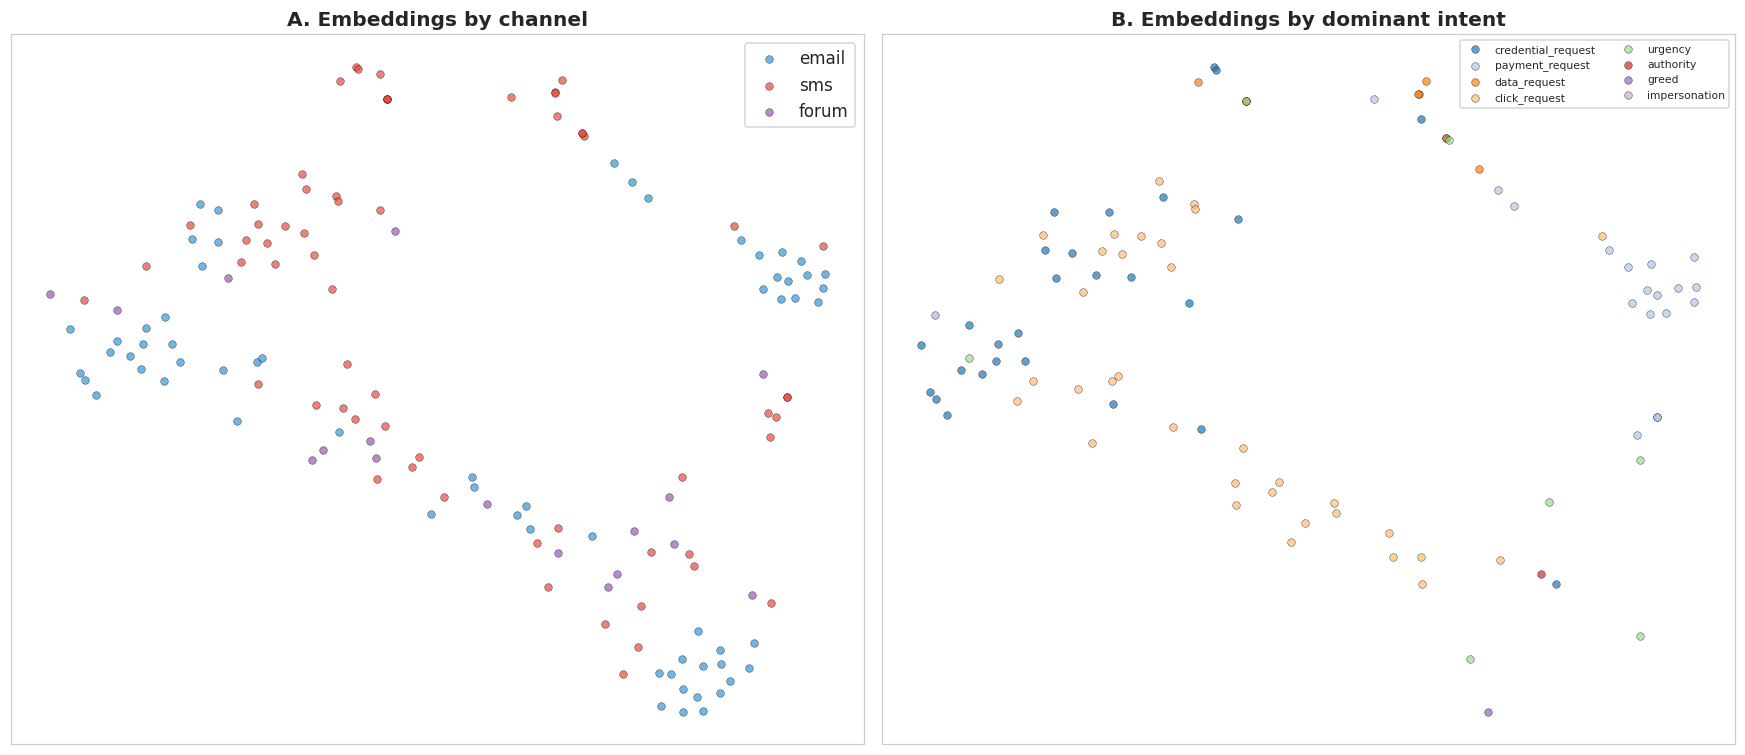

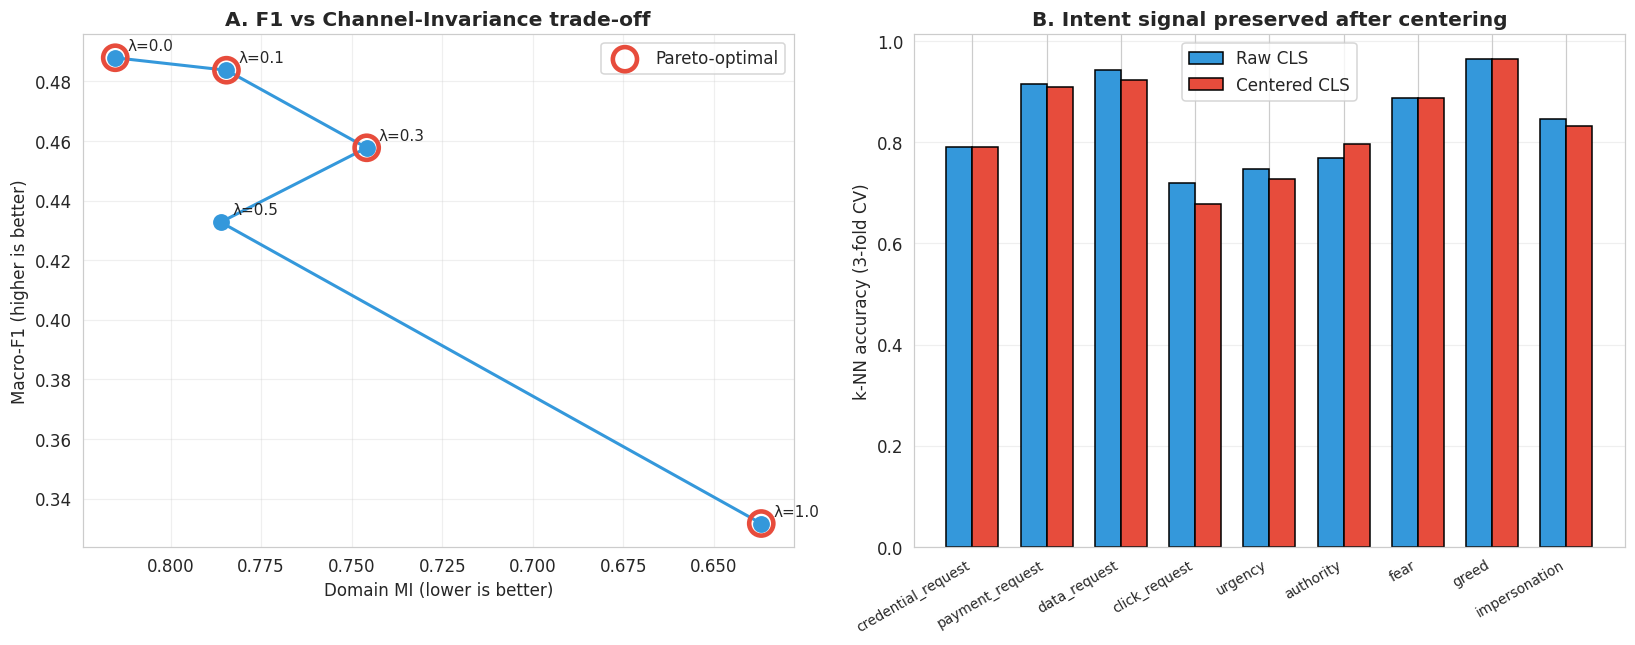

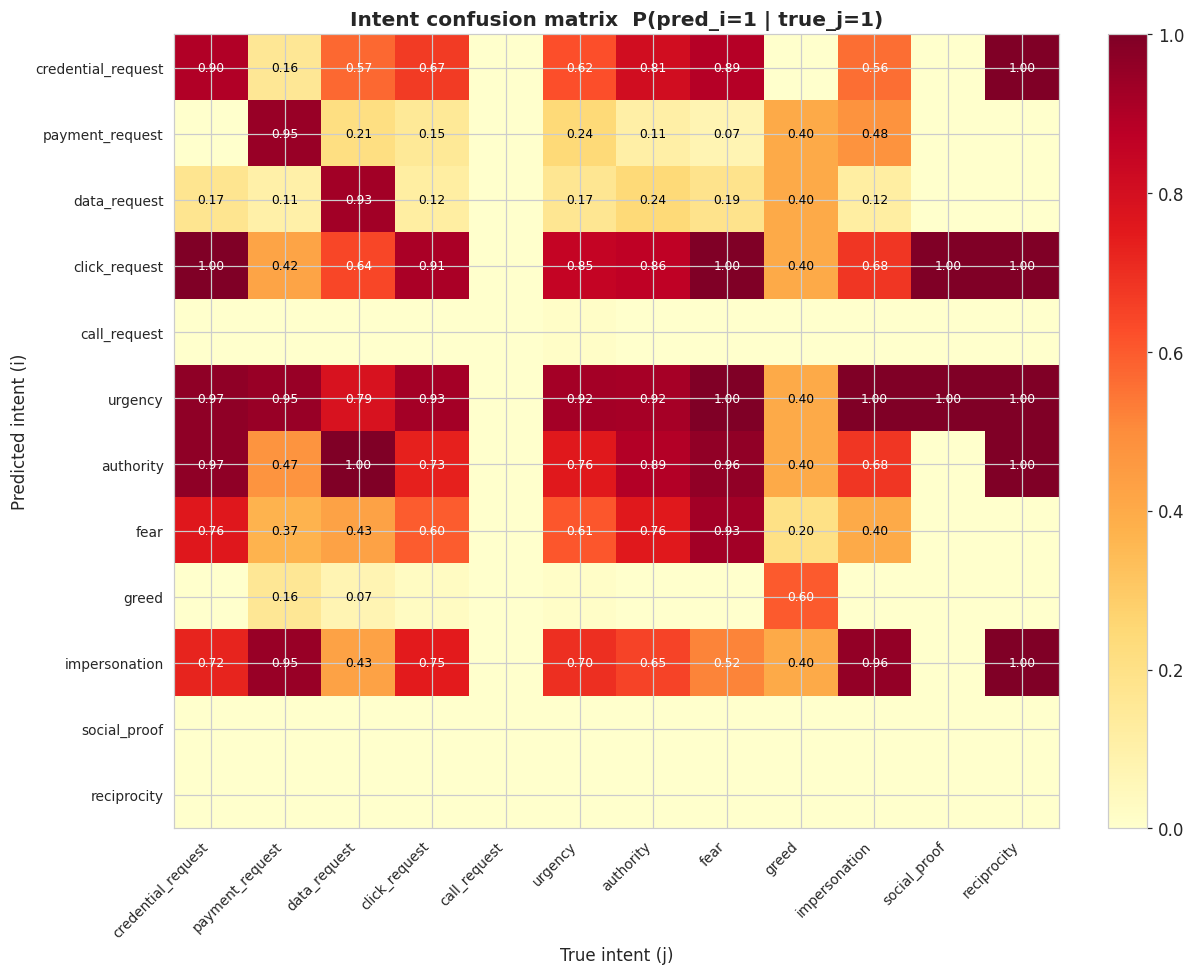

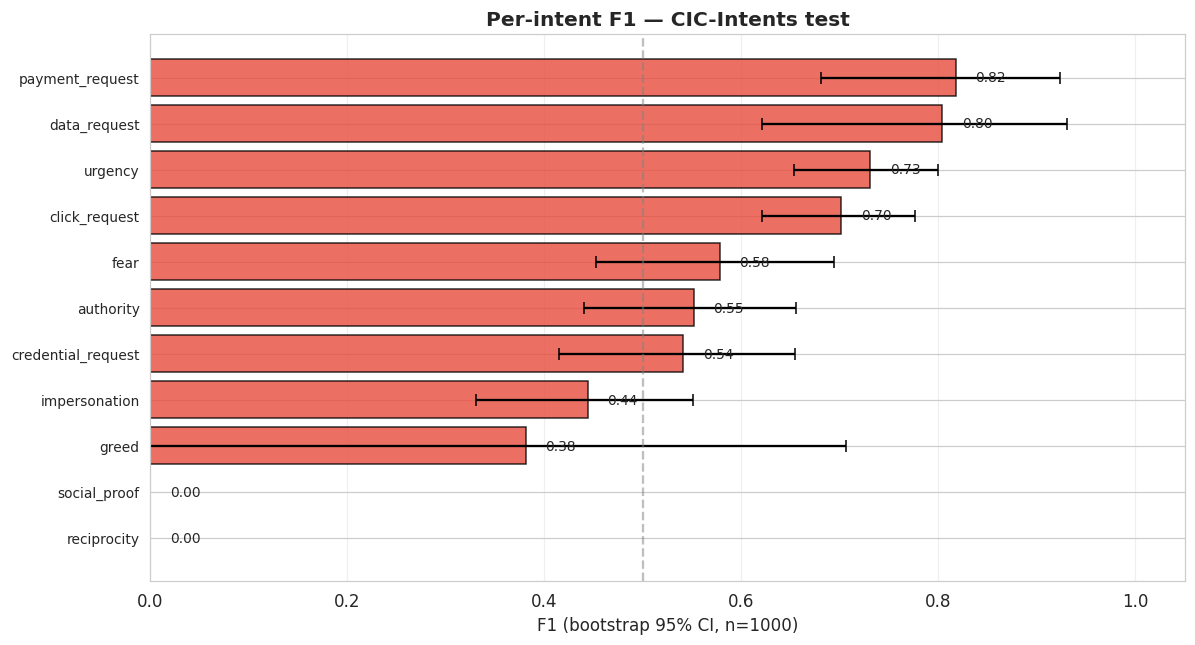

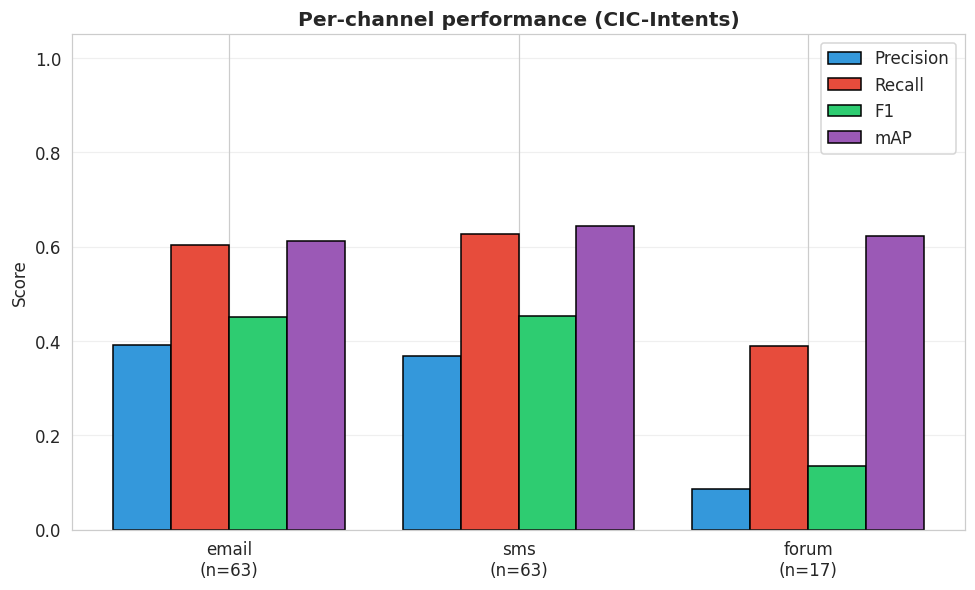

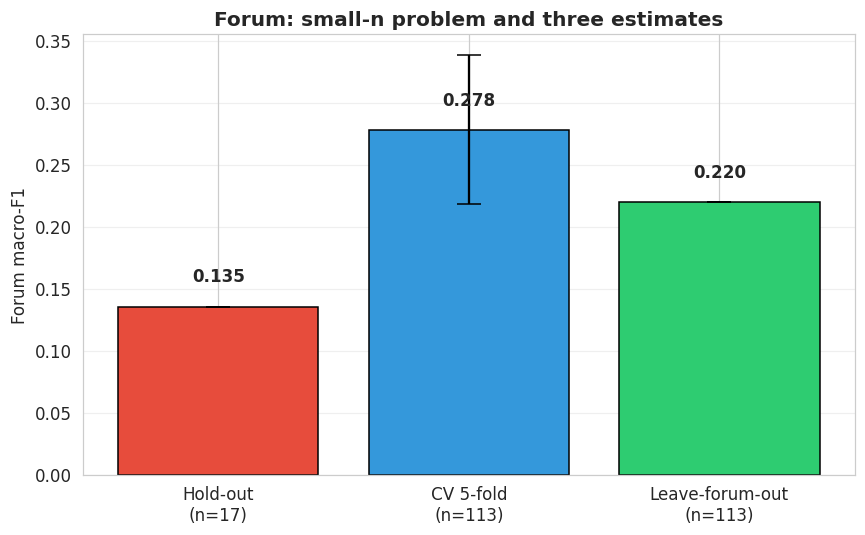

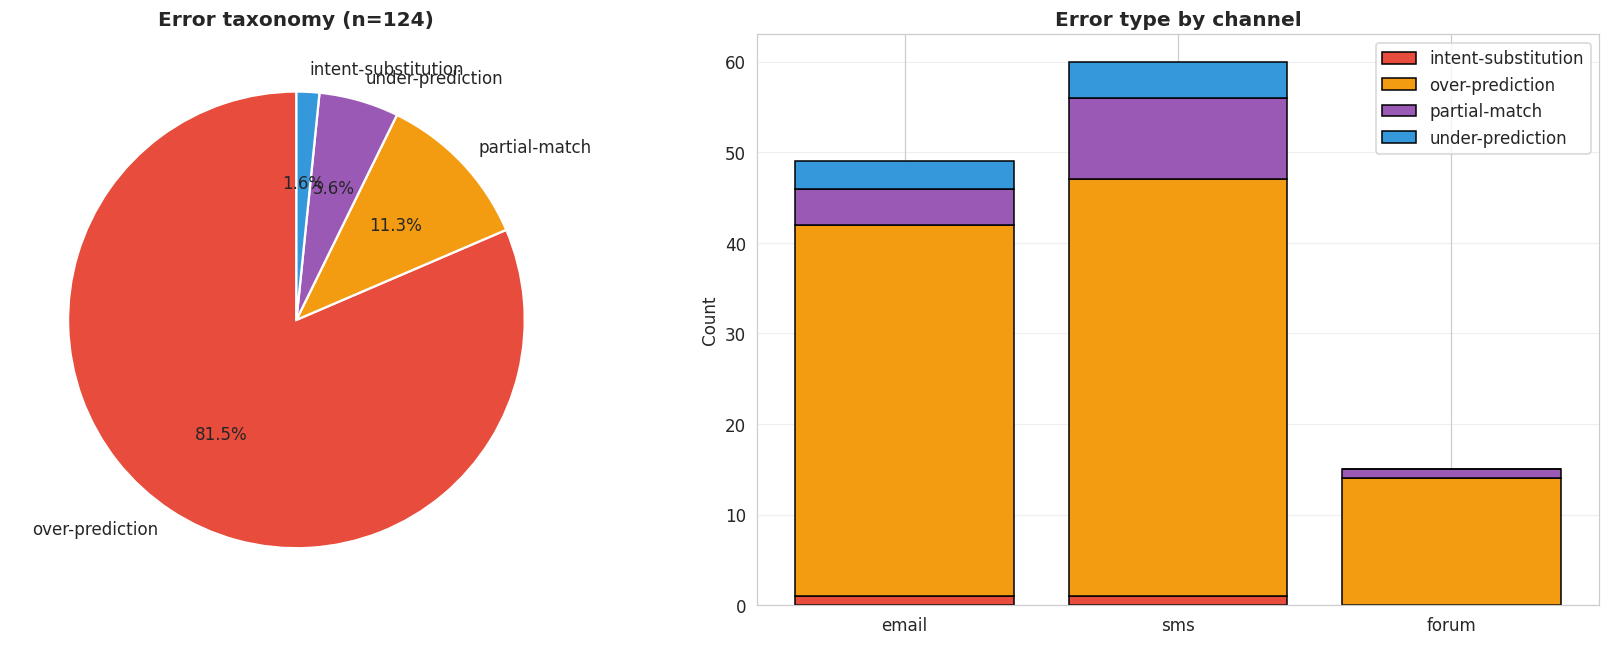

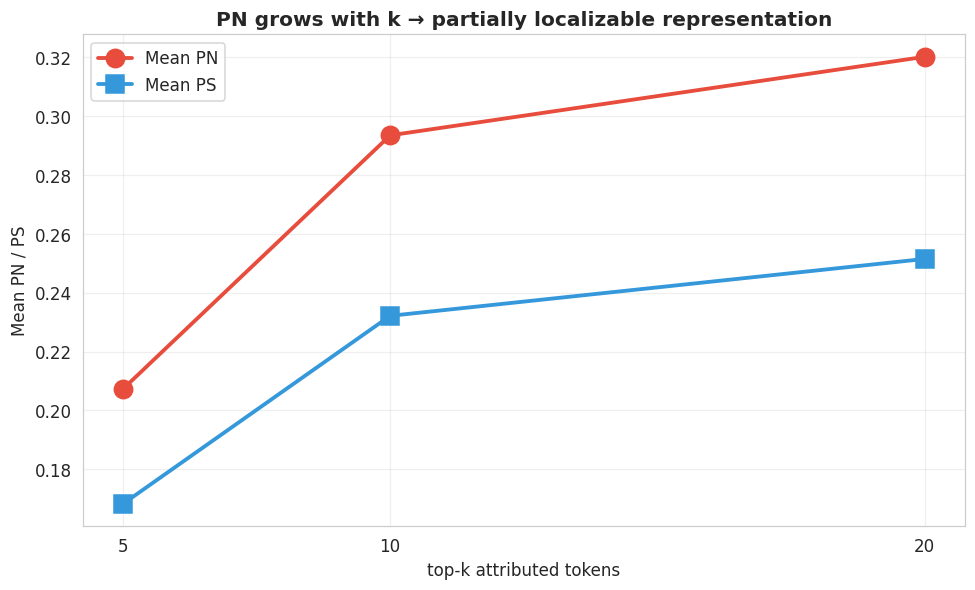

✅ All figures saved to /kaggle/working/figures/


In [20]:
# ============================================================
# CELL 30 — All figures
# ============================================================
# Figure 1 — Training curves
if hist_main is not None and len(hist_main.get('bce', [])) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    ep = np.arange(1, len(hist_main['bce']) + 1)
    axes[0,0].plot(ep, hist_main['bce'], 'o-', color='#3498DB', lw=2)
    axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('BCE')
    axes[0,0].set_title('A. Intent loss (BCE)', fontweight='bold'); axes[0,0].grid(alpha=0.3)
    axes[0,1].plot(ep, hist_main['supcon'], 's-', color='#9B59B6', lw=2)
    axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('SupCon')
    axes[0,1].set_title('B. Multi-label SupCon', fontweight='bold'); axes[0,1].grid(alpha=0.3)
    axes[1,0].plot(ep, hist_main['mmd'], '^-', color='#16A085', lw=2)
    axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('MMD')
    axes[1,0].set_title('C. Channel-invariance loss (MMD)', fontweight='bold'); axes[1,0].grid(alpha=0.3)
    axes[1,1].plot(ep, hist_main['val_f1'], 'd-', color='#27AE60', lw=2)
    axes[1,1].axhline(0.5, color='gray', ls='--', alpha=0.5)
    axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Val macro-F1')
    axes[1,1].set_title('D. Validation macro-F1', fontweight='bold'); axes[1,1].grid(alpha=0.3)
    plt.suptitle('CIC-Intents — training dynamics', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR + 'fig1_learning_curves.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print("Fig 1 skipped — hist_main unavailable (loaded from checkpoint).")

# Figure 2 — t-SNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=25, random_state=42, init='pca',
            learning_rate='auto')
coords = tsne.fit_transform(embs_raw)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
CH_COLORS = {0: '#3498DB', 1: '#E74C3C', 3: '#9B59B6'}
for ch_id, ch_name in CH_NAMES.items():
    mask = test_ch_main == ch_id
    axes[0].scatter(coords[mask, 0], coords[mask, 1], c=CH_COLORS[ch_id],
                     label=ch_name, alpha=0.7, s=25, edgecolor='black', linewidth=0.3)
axes[0].set_title('A. Embeddings by channel', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_xticks([]); axes[0].set_yticks([])
dominant = np.array([np.argmax(row) if row.sum() > 0 else -1 for row in test_y_main])
palette_int = plt.cm.tab20(np.linspace(0, 1, 20))
for idx, code in enumerate(INTENT_CODES):
    mask = dominant == idx
    if mask.sum() == 0: continue
    axes[1].scatter(coords[mask, 0], coords[mask, 1], c=[palette_int[idx]],
                     label=code, alpha=0.7, s=25, edgecolor='black', linewidth=0.3)
axes[1].set_title('B. Embeddings by dominant intent', fontweight='bold')
axes[1].legend(fontsize=7, ncol=2); axes[1].grid(alpha=0.3)
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig2_tsne.png', dpi=200, bbox_inches='tight')
plt.show()

# Figure 3 — Pareto + k-NN preservation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(df_sweep['domain_MI'], df_sweep['macro_f1'], 'o-', color='#3498DB',
             lw=2, markersize=10)
for _, row in df_sweep.iterrows():
    axes[0].annotate(f"λ={row['lambda_mmd']}", (row['domain_MI'], row['macro_f1']),
                     xytext=(8, 5), textcoords='offset points', fontsize=10)
popts = df_sweep[df_sweep['pareto_optimal']]
axes[0].scatter(popts['domain_MI'], popts['macro_f1'], s=250, facecolors='none',
                 edgecolors='#E74C3C', linewidth=3, zorder=5, label='Pareto-optimal')
axes[0].set_xlabel('Domain MI (lower is better)')
axes[0].set_ylabel('Macro-F1 (higher is better)')
axes[0].set_title('A. F1 vs Channel-Invariance trade-off', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].invert_xaxis()

codes_knn = list(knn_results.keys())
raw_vals  = [knn_results[c]['raw'] for c in codes_knn]
cent_vals = [knn_results[c]['centered'] for c in codes_knn]
x = np.arange(len(codes_knn)); w = 0.35
axes[1].bar(x - w/2, raw_vals, w, label='Raw CLS', color='#3498DB', edgecolor='black')
axes[1].bar(x + w/2, cent_vals, w, label='Centered CLS', color='#E74C3C', edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(codes_knn, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('k-NN accuracy (3-fold CV)')
axes[1].set_title('B. Intent signal preserved after centering', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig3_pareto_and_signal.png', dpi=200, bbox_inches='tight')
plt.show()

# Figure 4 — Confusion matrix
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(conf_fixed, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(N_INTENTS)); ax.set_yticks(range(N_INTENTS))
ax.set_xticklabels(INTENT_CODES, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(INTENT_CODES, fontsize=9)
for i in range(N_INTENTS):
    for j in range(N_INTENTS):
        if conf_fixed[i, j] > 0.05:
            ax.text(j, i, f'{conf_fixed[i,j]:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if conf_fixed[i,j] > 0.5 else 'black')
ax.set_xlabel('True intent (j)'); ax.set_ylabel('Predicted intent (i)')
ax.set_title('Intent confusion matrix  P(pred_i=1 | true_j=1)', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig4_confusion.png', dpi=200, bbox_inches='tight')
plt.show()

# Figure 5 — Per-intent F1 CI
def per_intent_f1_ci(y_true, y_proba, n_boot=1000):
    n = len(y_true); rng = np.random.RandomState(42)
    f1s = {c: [] for c in INTENT_CODES}
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        for i, c in enumerate(INTENT_CODES):
            if y_true[idx, i].sum() == 0: continue
            pred = (y_proba[idx, i] > 0.5).astype(int)
            f1s[c].append(f1_score(y_true[idx, i], pred, zero_division=0))
    out = {}
    for c in INTENT_CODES:
        if f1s[c]:
            out[c] = (float(np.mean(f1s[c])),
                      float(np.percentile(f1s[c], 2.5)),
                      float(np.percentile(f1s[c], 97.5)))
    return out

ci = per_intent_f1_ci(test_y_main, test_probs_main)
codes_sorted = sorted(ci.keys(), key=lambda c: ci[c][0], reverse=True)
means = [ci[c][0] for c in codes_sorted]
lows  = [ci[c][1] for c in codes_sorted]
highs = [ci[c][2] for c in codes_sorted]
fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(codes_sorted))
err_low  = [m - l for m, l in zip(means, lows)]
err_high = [h - m for m, h in zip(means, highs)]
ax.barh(y_pos, means, xerr=[err_low, err_high], color='#E74C3C',
        edgecolor='black', alpha=0.8, capsize=4)
for i, m in enumerate(means):
    ax.text(m + 0.02, i, f'{m:.2f}', va='center', fontsize=9)
ax.set_yticks(y_pos); ax.set_yticklabels(codes_sorted, fontsize=9)
ax.invert_yaxis(); ax.set_xlim(0, 1.05)
ax.set_xlabel('F1 (bootstrap 95% CI, n=1000)')
ax.set_title('Per-intent F1 — CIC-Intents test', fontweight='bold')
ax.axvline(0.5, color='gray', ls='--', alpha=0.5); ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig5_per_intent_ci.png', dpi=200, bbox_inches='tight')
plt.show()

# Figure 7 — Per-channel performance
fig, ax = plt.subplots(figsize=(9, 5.5))
chs_list, prec_ch, rec_ch, f1_ch, map_ch = [], [], [], [], []
for ch_id, ch_name in CH_NAMES.items():
    m = test_ch_main == ch_id
    if m.sum() == 0: continue
    p_, r_, f1_, _ = precision_recall_fscore_support(
        test_y_main[m], pred_main[m], average='macro', zero_division=0)
    aps_ = [average_precision_score(test_y_main[m][:, i], test_probs_main[m][:, i])
            for i in range(N_INTENTS) if test_y_main[m][:, i].sum() > 0]
    chs_list.append(f"{ch_name}\n(n={m.sum()})")
    prec_ch.append(p_); rec_ch.append(r_); f1_ch.append(f1_); map_ch.append(np.mean(aps_))
x = np.arange(len(chs_list)); w = 0.2
ax.bar(x - 1.5*w, prec_ch, w, label='Precision', color='#3498DB', edgecolor='black')
ax.bar(x - 0.5*w, rec_ch,  w, label='Recall',    color='#E74C3C', edgecolor='black')
ax.bar(x + 0.5*w, f1_ch,   w, label='F1',        color='#2ECC71', edgecolor='black')
ax.bar(x + 1.5*w, map_ch,  w, label='mAP',       color='#9B59B6', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(chs_list)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Per-channel performance (CIC-Intents)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig7_per_channel.png', dpi=200, bbox_inches='tight')
plt.show()

# Figure 7b — Forum three estimates
_cv  = METRICS.get('forum_cv')  or {
    'macro_f1_mean': 0.278, 'macro_f1_std': 0.060,
}
_loo = METRICS.get('loo_forum') or {
    'macro_f1': 0.220,
}
_holdout = per_channel_f1.get('forum', float('nan'))

fig, ax = plt.subplots(figsize=(8, 5))
scenarios = ['Hold-out\n(n=17)', f"CV 5-fold\n(n={len(df_forum)})",
             f"Leave-forum-out\n(n={len(df_forum)})"]
f1_vals = [_holdout, _cv['macro_f1_mean'], _loo['macro_f1']]
errs    = [0.0, _cv.get('macro_f1_std', 0.0), 0.0]
bars = ax.bar(scenarios, f1_vals, yerr=errs, capsize=8,
               color=['#E74C3C', '#3498DB', '#2ECC71'], edgecolor='black')
for b, v in zip(bars, f1_vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.3f}',
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Forum macro-F1')
ax.set_title('Forum: small-n problem and three estimates', fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig7b_forum_smalln.png', dpi=200, bbox_inches='tight')
plt.show()

# Figure 8 — Error taxonomy
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
counts = df_errors['category'].value_counts()
colors_pie = ['#E74C3C', '#F39C12', '#9B59B6', '#3498DB', '#2ECC71']
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors_pie[:len(counts)], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title(f'Error taxonomy (n={len(df_errors)})', fontweight='bold')
per_ch_err = df_errors.groupby(['channel', 'category']).size().unstack(fill_value=0)
cats = list(per_ch_err.columns); bottoms = np.zeros(len(per_ch_err))
for i, cat in enumerate(cats):
    vals = per_ch_err[cat].values
    axes[1].bar([CH_NAMES.get(c, str(c)) for c in per_ch_err.index], vals,
                bottom=bottoms, label=cat, color=colors_pie[i % len(colors_pie)],
                edgecolor='black')
    bottoms += vals
axes[1].set_ylabel('Count'); axes[1].set_title('Error type by channel', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig8_error_taxonomy.png', dpi=200, bbox_inches='tight')
plt.show()

# Figure 10 — PN vs k
if 'df_pnps' in dir() and len(df_pnps) > 0:
    k_means = df_pnps.groupby('k')['PN'].mean()
    ps_means = df_pnps.groupby('k')['PS'].mean()
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.plot(k_means.index, k_means.values, 'o-', color='#E74C3C',
            lw=2.5, markersize=12, label='Mean PN')
    ax.plot(ps_means.index, ps_means.values, 's-', color='#3498DB',
            lw=2.5, markersize=12, label='Mean PS')
    ax.set_xlabel('top-k attributed tokens'); ax.set_ylabel('Mean PN / PS')
    ax.set_xticks([5, 10, 20])
    ax.set_title('PN grows with k → partially localizable representation',
                 fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR + 'fig10_pn_vs_k.png', dpi=200, bbox_inches='tight')
    plt.show()

print(f"✅ All figures saved to {FIG_DIR}")

In [21]:
# ============================================================
# CELL 31 — Export everything for the paper
# ============================================================
summary = {
    'test_n': int(len(test_y_main)),
    'mAP_macro': float(mAP_m),
    'mAP_naive': float(mAP_m_naive),
    'mean_AUC': float(np.nanmean(aucs_m)),
    'top_k_recall': top_k_recall,
    'threshold_0.5': {
        'precision': float(p_m), 'recall': float(r_m),
        'macro_f1': float(f1_m), 'exact_match': float(exact_m),
    },
    'per_channel_f1': per_channel_f1,
    'per_intent_ap': per_intent_ap,
    'pareto_sweep': df_sweep.to_dict('records'),
    'centering': {
        'mi_raw': float(mi_raw) if mi_raw else None,
        'mi_centered': float(mi_cent) if mi_cent else None,
    },
    'forum_small_n_fix': {
        'holdout_main_n17': float(per_channel_f1.get('forum', float('nan'))),
        'loo_forum_n113': loo_forum_metrics,
        'forum_cv_5fold': cv_forum_metrics,
    },
    'config': {
        'lr': 5e-5, 'lambda_supcon': 0.3, 'lambda_mmd': 0.3,
        'pos_weight_clip': 5.0, 'temperature': 0.07, 'channel_weight': 0.5,
        'epochs': 10, 'batch_size': 32, 'max_len': 160, 'seed': RANDOM_STATE,
    },
}
with open(os.path.join(OUT_DIR, 'paper_metrics.json'), 'w') as f:
    json.dump(summary, f, indent=2)

np.savez(os.path.join(OUT_DIR, 'final_predictions.npz'),
         test_probs=test_probs_main, test_labels=test_y_main,
         test_channels=test_ch_main,
         val_probs=val_probs_main, val_labels=val_y_main,
         cls_embeddings=embs_raw)

with zipfile.ZipFile(os.path.join(OUT_DIR, 'final_export_light.zip'), 'w',
                      zipfile.ZIP_DEFLATED) as z:
    for fname in ['paper_metrics.json', 'final_predictions.npz',
                  'errors_fixed.csv', 'causal_attribution.csv',
                  'lambda_sweep.csv', 'forum_cv_results.csv',
                  'ablation_study.csv', 'baseline_encoders.csv']:
        p = os.path.join(OUT_DIR, fname)
        if os.path.exists(p):
            z.write(p, fname)
            print(f"   + {fname}")
    for fname in sorted(os.listdir(FIG_DIR)):
        z.write(os.path.join(FIG_DIR, fname), 'figures/' + fname)

print(f"\n✅ final_export_light.zip "
      f"({os.path.getsize(os.path.join(OUT_DIR, 'final_export_light.zip'))/1e6:.1f} MB)")
print("📥 Download from Kaggle Output panel.")

NameError: name 'cv_forum_metrics' is not defined